# Projet ML 4MA — Notebook R (modélisation)

Ce notebook traite la partie modélisation du projet de Machine Learning 4MA. L'analyse exploratoire est traitée séparément. L'étude est structurée en deux problèmes :

- Classification : prédire la variable `Heart_Disease_Risk` (risque d'accident cardiaque : 0 = faible, 1 = élevé) à partir de toutes les autres variables.
- Régression : prédire la variable `Cholesterol_LDL` ("mauvais" cholestérol) à partir de toutes les autres variables (sauf `Heart_Disease_Risk`).

## 0. Mise en place de l'environnement

On charge les paquets utilisés tout au long du notebook et on fixe la graine aléatoire principale. La valeur `set.seed(11)` est utilisée pour la séparation train/test et garantit la reproductibilité du tirage. Une graine `42` sera re-fixée localement avant les modèles à composante stochastique (Random Forest, Bagging, GBM, réseaux de neurones) pour fixer leur initialisation.

In [1]:
suppressPackageStartupMessages({
  library(MASS)
  library(glmnet)
  library(rpart)
  library(rpart.plot)
  library(randomForest)
  library(ipred)
  library(gbm)
  library(adabag)
  library(e1071)
  library(class)
  library(nnet)
  library(caret)
  library(pROC)
  library(ggplot2)
  library(gridExtra)
  library(dplyr)
})

set.seed(11)

cat("R version :", R.version.string, "\n")


Warning message:
"le package 'glmnet' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'rpart.plot' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'randomForest' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'ipred' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'gbm' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'adabag' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'caret' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'foreach' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'doParallel' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'iterators' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'e1071' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'pROC' a été compilé avec la versi

R version : R version 4.4.2 (2024-10-31 ucrt) 


## 1. Chargement et préparation préalable

On lit le CSV brut, on retire l'identifiant patient et on convertit les variables qualitatives en `factor`. L'analyse exploratoire (univarié, bivarié, ACP) est traitée séparément et n'est pas reprise ici.

In [2]:
data <- read.csv("../divers/healthcare_synthetic_data.csv", stringsAsFactors = FALSE)
cat(sprintf("Dimensions : %d lignes x %d colonnes\n", nrow(data), ncol(data)))
str(data, give.attr = FALSE)


Dimensions : 15000 lignes x 19 colonnes
'data.frame':	15000 obs. of  19 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : int  0 0 1 1 1 0 0 0 0 1 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : int  0 0 0 0 0 0 0 0 1 0 ...
 $ Alcohol_

### Suppression de Patient_ID

La colonne `Patient_ID` est un identifiant unique par patient. Elle n'a aucune valeur prédictive et doit être retirée avant l'analyse.

In [3]:
data <- data %>% dplyr::select(-Patient_ID)


### Conversion des variables qualitatives

Dans le CSV, toutes les variables sont encodées numériquement (0, 1, 2...). Il faut explicitement convertir les variables qualitatives en `factor` pour que R les traite correctement (par exemple, `summary()` ne calculera pas de moyenne sur `Gender`).

- Non ordonnées : `Gender`, `Smoking_Status`, `Family_History`, `Heart_Disease_Risk`
- Ordonnées : `Alcohol_Consumption` (0 < 1 < 2, niveaux croissants de consommation) et `Physical_Activity_Level` (0 < 1 < 2 < 3, niveaux croissants d'activité)

In [4]:
data$Gender                  <- factor(data$Gender, ordered = FALSE)
data$Smoking_Status          <- factor(data$Smoking_Status, ordered = FALSE)
data$Family_History          <- factor(data$Family_History, ordered = FALSE)
data$Heart_Disease_Risk      <- factor(data$Heart_Disease_Risk, ordered = FALSE)
data$Alcohol_Consumption     <- factor(data$Alcohol_Consumption, ordered = TRUE)
data$Physical_Activity_Level <- factor(data$Physical_Activity_Level, ordered = TRUE)

# Liste des variables quantitatives (réutilisée pour la suite)
var_quant <- c("Age", "Height_cm", "Weight_kg", "BMI", "Systolic_BP", "Diastolic_BP",
               "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
               "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours")

cat("Types après conversion :\n")
print(sapply(data, function(x) paste(class(x), collapse = " ")))


Types après conversion :
                    Age                  Gender               Height_cm 
              "integer"                "factor"               "numeric" 
              Weight_kg                     BMI             Systolic_BP 
              "numeric"               "numeric"               "integer" 
           Diastolic_BP       Cholesterol_Total         Cholesterol_LDL 
              "integer"               "integer"               "integer" 
        Cholesterol_HDL     Fasting_Blood_Sugar          Smoking_Status 
              "integer"               "integer"                "factor" 
    Alcohol_Consumption Physical_Activity_Level          Family_History 
       "ordered factor"        "ordered factor"                "factor" 
           Stress_Level             Sleep_Hours      Heart_Disease_Risk 
              "integer"               "integer"                "factor" 


## 2. Préparation des données pour la modélisation

On prépare maintenant les données pour les algorithmes de ML : encodage one-hot des variables qualitatives, séparation train/test, et standardisation.

### One-hot encoding des variables qualitatives explicatives

On transforme les variables catégorielles en indicatrices binaires (dummy variables). Pour les variables binaires, on supprime une modalité de référence afin d'éviter la multicolinéarité parfaite. 

In [5]:
data_for_dummy <- data
data_for_dummy$Alcohol_Consumption     <- factor(data_for_dummy$Alcohol_Consumption,     ordered = FALSE)
data_for_dummy$Physical_Activity_Level <- factor(data_for_dummy$Physical_Activity_Level, ordered = FALSE)

dataDum <- model.matrix(
  ~ Gender + Smoking_Status + Alcohol_Consumption + Physical_Activity_Level + Family_History,
  data = data_for_dummy
)[, -1, drop = FALSE]

# Renommage pour matcher la convention pandas : Gender_1 au lieu de Gender1, etc.
colnames(dataDum) <- gsub(
  "(Gender|Smoking_Status|Alcohol_Consumption|Physical_Activity_Level|Family_History)([0-9])",
  "\\1_\\2",
  colnames(dataDum)
)
dataDum <- as.data.frame(dataDum)
head(dataDum)


,Gender_1,Smoking_Status_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,0,1,0,0,0,1,0
2,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,0,0
4,1,0,0,0,1,0,0,0
5,1,0,1,0,0,1,0,0
6,0,0,0,0,1,0,0,1


**Note :** On retire la première modalité de chaque variable qualitative. Cela évite la multicolinéarité : si on a N modalités, N-1 indicatrices suffisent car la dernière est déductible des autres.

In [6]:
dataQuant <- data[, var_quant]
dataC <- cbind(dataDum, dataQuant)
cat(sprintf("Dimensions de dataC : (%d, %d)\n", nrow(dataC), ncol(dataC)))
head(dataC)


Dimensions de dataC : (15000, 20)


,Gender_1,Smoking_Status_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,1,0,0,0,1,0,60,146.9,51.3,23.8,140,89,217,151,52,83,1,8
2,0,0,0,0,1,0,0,0,53,161.8,76.6,29.3,128,81,203,119,38,116,7,9
3,1,0,0,0,0,0,0,0,62,174.7,92.4,30.3,141,100,173,124,45,90,1,7
4,1,0,0,0,1,0,0,0,73,173.3,68.9,22.9,136,96,193,117,45,81,2,7
5,1,0,1,0,0,1,0,0,52,178.6,79.8,25.0,122,80,236,153,41,79,2,6
6,0,0,0,0,1,0,0,1,52,159.6,60.3,23.7,134,92,225,155,48,103,4,8


In [7]:

Yb <- data$Heart_Disease_Risk


Yr <- data$Cholesterol_LDL


### Pourquoi séparer apprentissage et test ?

Évaluer un modèle sur les mêmes données qui ont servi à l'entraîner donne une vision biaisée de sa performance : un modèle peut très bien mémoriser ses observations d'apprentissage (surapprentissage) sans pour autant savoir prédire correctement sur de nouveaux patients.

On réserve donc 20 % du jeu de données, jamais vues pendant l'apprentissage, pour mesurer la capacité réelle de généralisation. C'est cet échantillon test qui sert ensuite de juge neutre pour comparer les différents modèles entre eux sur un terrain commun.

### Séparation train / test

On sépare les données en 80 % d'apprentissage et 20 % de test. `set.seed(11)` fixe la graine aléatoire pour garantir la reproductibilité du tirage.

**Important :** pour la régression sur `Cholesterol_LDL`, on retire cette variable des features (on ne peut pas utiliser la variable cible comme variable explicative).

In [8]:
set.seed(11)
n <- nrow(dataC)
test_idx <- sample(seq_len(n), size = 3000)

# Classification : toutes les features
X_train     <- dataC[-test_idx, , drop = FALSE]
X_test      <- dataC[ test_idx, , drop = FALSE]
Y_train_AVC <- Yb[-test_idx]
Y_test_AVC  <- Yb[ test_idx]

# Régression : on retire Cholesterol_LDL des features
dataC_r <- dataC[, !colnames(dataC) %in% "Cholesterol_LDL", drop = FALSE]
X_train_r       <- dataC_r[-test_idx, , drop = FALSE]
X_test_r        <- dataC_r[ test_idx, , drop = FALSE]
Y_train_cholest <- Yr[-test_idx]
Y_test_cholest  <- Yr[ test_idx]

cat(sprintf("Classification - Train: (%d, %d), Test: (%d, %d)\n",
            nrow(X_train), ncol(X_train), nrow(X_test), ncol(X_test)))
cat(sprintf("Régression     - Train: (%d, %d), Test: (%d, %d)\n",
            nrow(X_train_r), ncol(X_train_r), nrow(X_test_r), ncol(X_test_r)))


Classification - Train: (12000, 20), Test: (3000, 20)
Régression     - Train: (12000, 19), Test: (3000, 19)


### Standardisation

Certains algorithmes (réseaux de neurones, SVM, KNN) sont sensibles à l'échelle des variables. On standardise les features (moyenne = 0, écart-type = 1).

**Important :** on calcule les paramètres (moyenne, écart-type) uniquement sur le train, puis on applique la même transformation au test. Cela évite toute fuite d'information du test vers le train.

In [9]:
# Standardisation pour la classification
mu       <- apply(X_train, 2, mean)
sd_train <- apply(X_train, 2, sd)
Xr_train <- as.data.frame(scale(X_train, center = mu, scale = sd_train))
Xr_test  <- as.data.frame(scale(X_test,  center = mu, scale = sd_train))

# Standardisation pour la régression
mu_r       <- apply(X_train_r, 2, mean)
sd_train_r <- apply(X_train_r, 2, sd)
Xr_train_r <- as.data.frame(scale(X_train_r, center = mu_r, scale = sd_train_r))
Xr_test_r  <- as.data.frame(scale(X_test_r,  center = mu_r, scale = sd_train_r))

cat("Standardisation effectuée.\n")
cat(sprintf("Moyenne des features (train classif) : %s ...\n",
            paste(round(colMeans(Xr_train)[1:3], 6), collapse = " ")))
cat(sprintf("Ecart-type des features (train classif) : %s ...\n",
            paste(round(apply(Xr_train, 2, sd)[1:3], 6), collapse = " ")))


Standardisation effectuée.
Moyenne des features (train classif) : 0 0 0 ...
Ecart-type des features (train classif) : 1 1 1 ...


Les données sont maintenant prêtes pour la modélisation. On dispose de :
- `X_train`, `X_test` / `Xr_train`, `Xr_test` : features pour la classification (brutes / standardisées)
- `X_train_r`, `X_test_r` / `Xr_train_r`, `Xr_test_r` : features pour la régression (brutes / standardisées)
- `Y_train_AVC`, `Y_test_AVC` : cible classification
- `Y_train_cholest`, `Y_test_cholest` : cible régression

# I : Problème de classification - Prédiction du risque d'accident cardiaque

Dans cette première partie on considère le problème de la prédiction de la variable `Heart_Disease_Risk` à partir des autres variables, en se concentrant sur les performances du modèle. L'objectif est de déterminer les meilleures performances que l'on peut attendre et les modèles qui les atteignent. C'est un problème de classification binaire, la variable cible prenant deux modalités : 0 = risque faible, 1 = risque élevé.

## 1. Premier modèle : régression logistique

On commence par une régression logistique simple, utilisée comme modèle de référence pour la classification. Elle fournit une première mesure de performance sur l'échantillon test et servira ensuite de point de comparaison avec les versions pénalisées, les méthodes de sélection de variables et les modèles plus complexes.

Pour évaluer les modèles de classification, on utilise principalement trois indicateurs :
- la log-loss : erreur probabiliste adaptée à la régression logistique
- l'accuracy (taux de bonne classification) et la matrice de confusion
- l'AUC (aire sous la courbe ROC), qui mesure la capacité de discrimination indépendamment du seuil

### 1.1 Modèle sans sélection de variable ni pénalisation

In [10]:
# Régression logistique sans pénalisation
df_train_logit <- data.frame(Y = Y_train_AVC, Xr_train)
logit_simple   <- glm(Y ~ ., data = df_train_logit, family = binomial)

# Probabilités prédites sur le test
p_simple <- predict(logit_simple, newdata = data.frame(Xr_test), type = "response")
y_pred_simple <- factor(as.integer(p_simple > 0.5), levels = c("0", "1"))

# Log-loss (fonction maison)
log_loss <- function(y_true, p_pred) {
  y_num <- as.numeric(as.character(y_true))
  p_pred <- pmin(pmax(p_pred, 1e-15), 1 - 1e-15)
  -mean(y_num * log(p_pred) + (1 - y_num) * log(1 - p_pred))
}
cat("Log-loss =", log_loss(Y_test_AVC, p_simple), "\n")


Log-loss = 0.5407092 


In [11]:
acc_simple <- mean(y_pred_simple == Y_test_AVC)
cat(sprintf("Accuracy : %.3f\n", acc_simple))
cat("Matrice de confusion (prédit en ligne, réel en colonne) :\n")
print(table(predit = y_pred_simple, reel = Y_test_AVC))


Accuracy : 0.732
Matrice de confusion (prédit en ligne, réel en colonne) :
      reel
predit    0    1
     0 1366  478
     1  327  829


Le modèle a une accuracy de 73.2 %. Comme le montre la matrice de confusion, il a particulièrement du mal à détecter les patients à risque élevé (478 faux négatifs contre 327 faux positifs). On peut chercher à augmenter la sensibilité en abaissant le seuil de décision (fixé ici à 0.5), au prix d'une hausse des faux positifs : la courbe ROC ci-dessous illustre ce compromis. L'aire sous la courbe vaut 0.795, ce qui fournit une première référence pour comparer les modèles suivants.

AUC = 0.795


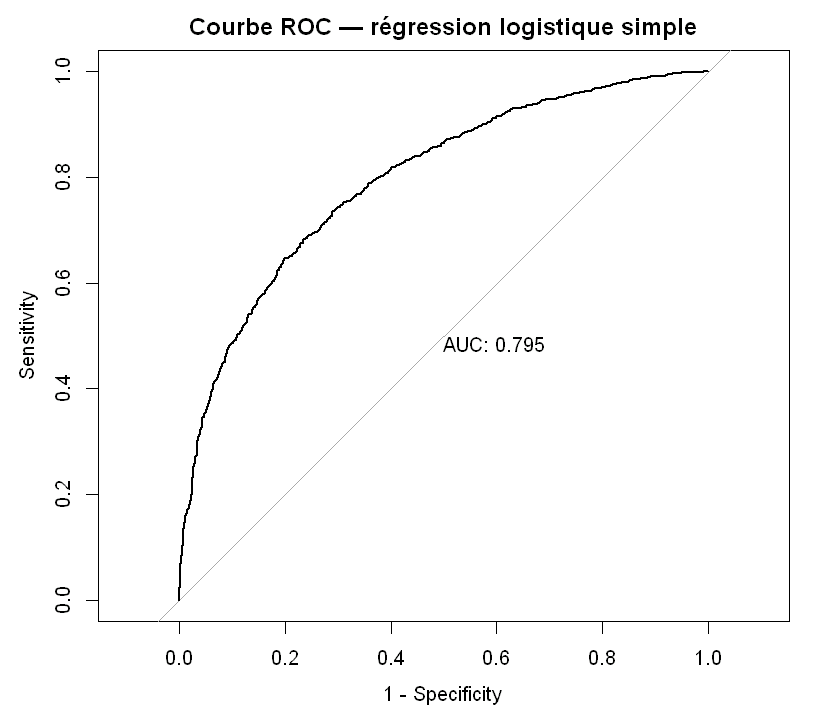

In [12]:
# Courbe ROC du modèle simple
library(pROC)
roc_simple <- roc(response = Y_test_AVC, predictor = p_simple,
                  levels = c("0", "1"), direction = "<", quiet = TRUE)
auc_simple <- as.numeric(auc(roc_simple))
cat(sprintf("AUC = %.3f\n", auc_simple))

options(repr.plot.width = 7, repr.plot.height = 6)
plot(roc_simple, main = "Courbe ROC — régression logistique simple",
     legacy.axes = TRUE, print.auc = TRUE)


### 1.2 Modèle avec pénalisation LASSO

Comme observé en analyse exploratoire, certaines variables semblent avoir peu d'influence sur le risque d'arrêt cardiaque, notamment `Height_cm`, `Cholesterol_HDL`, `Stress_Level` et `Sleep_Hours`. Une première méthode de sélection de variables est la pénalisation LASSO (norme L1), qui peut mettre certains coefficients exactement à zéro. On choisit la valeur du paramètre de pénalisation $\lambda$ par validation croisée à 5 plis, en maximisant l'AUC.

In [13]:
# Préparation des matrices au format attendu par glmnet
x_train_mat <- as.matrix(Xr_train)
x_test_mat  <- as.matrix(Xr_test)
y_train_num <- as.numeric(as.character(Y_train_AVC))
y_test_num  <- as.numeric(as.character(Y_test_AVC))

set.seed(11)
cv_lasso <- cv.glmnet(x_train_mat, y_train_num, family = "binomial",
                      alpha = 1, type.measure = "auc", nfolds = 5)
cat(sprintf("Lambda optimal (LASSO, lambda.min) : %.5f\n", cv_lasso$lambda.min))
cat(sprintf("AUC moyenne en validation croisée  : %.4f\n", max(cv_lasso$cvm)))


Lambda optimal (LASSO, lambda.min) : 0.00055
AUC moyenne en validation croisée  : 0.8096


In [14]:
# Coefficients du modèle LASSO retenu
coef_lasso <- coef(cv_lasso, s = "lambda.min")
coef_df    <- data.frame(var = rownames(coef_lasso)[-1],
                         coef = as.numeric(coef_lasso[-1, 1]))
for (i in seq_len(nrow(coef_df))) {
  cat(sprintf("%s: %.4f\n", coef_df$var[i], coef_df$coef[i]))
}
cat(sprintf("\nNombre de coefficients exactement nuls : %d\n", sum(coef_df$coef == 0)))


Gender_1: -0.0458
Smoking_Status_1: 0.9091
Alcohol_Consumption_1: -0.0255
Alcohol_Consumption_2: -0.0143
Physical_Activity_Level_1: -0.2665
Physical_Activity_Level_2: -0.4571
Physical_Activity_Level_3: -0.4685
Family_History_1: 0.5433
Age: 0.2338
Height_cm: 0.0000
Weight_kg: 0.0617
BMI: 0.1326
Systolic_BP: 0.3560
Diastolic_BP: -0.0027
Cholesterol_Total: -0.0383
Cholesterol_LDL: 0.2079
Cholesterol_HDL: -0.0386
Fasting_Blood_Sugar: 0.3305
Stress_Level: 0.2935
Sleep_Hours: -0.1061

Nombre de coefficients exactement nuls : 1


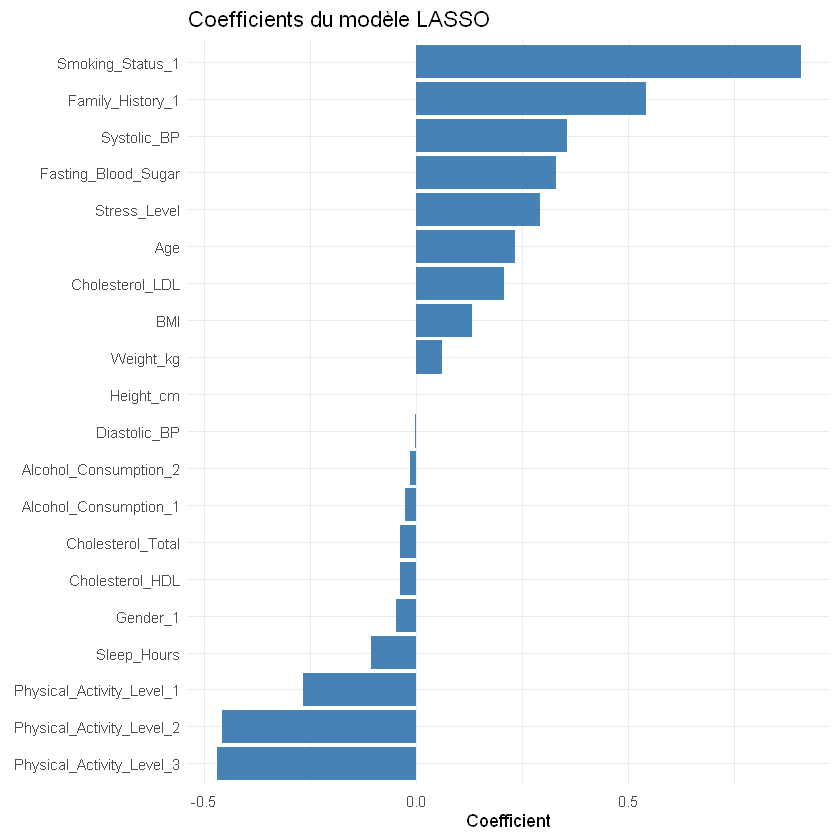

In [15]:
# Visualisation des coefficients (barplot horizontal trié)
coef_df_sorted <- coef_df[order(coef_df$coef), ]
coef_df_sorted$var <- factor(coef_df_sorted$var, levels = coef_df_sorted$var)

options(repr.plot.width = 7, repr.plot.height = 7)
ggplot(coef_df_sorted, aes(x = var, y = coef)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(x = NULL, y = "Coefficient", title = "Coefficients du modèle LASSO") +
  theme_minimal()


Le paramètre de pénalisation retenu est $\lambda \approx 5.5 \times 10^{-4}$. Avec ce choix, le coefficient de la variable `Height_cm` est mis à 0 : son influence sur le risque d'arrêt cardiaque est négligeable pour ce modèle. Les principaux facteurs de risque (coefficients positifs élevés) sont le statut de fumeur (`Smoking_Status_1` ≈ +0.91), les antécédents familiaux (`Family_History_1` ≈ +0.54), la pression artérielle systolique (≈ +0.36), la glycémie à jeun (≈ +0.33) et le niveau de stress (≈ +0.29). À l'inverse, les niveaux élevés d'activité physique (`Physical_Activity_Level_2` et `_3` ≈ -0.46 et -0.47) et un nombre suffisant d'heures de sommeil (≈ -0.11) sont associés à une diminution du risque.

In [16]:
# Évaluation du LASSO sur l'échantillon test
p_lasso <- predict(cv_lasso, newx = x_test_mat, s = "lambda.min", type = "response")[, 1]
y_pred_lasso <- factor(as.integer(p_lasso > 0.5), levels = c("0", "1"))
acc_lasso <- mean(y_pred_lasso == Y_test_AVC)

roc_lasso <- roc(Y_test_AVC, p_lasso, levels = c("0", "1"), direction = "<", quiet = TRUE)
auc_lasso <- as.numeric(auc(roc_lasso))

cat(sprintf("Accuracy test : %.4f\n", acc_lasso))
cat(sprintf("AUC test      : %.4f\n", auc_lasso))
cat("Matrice de confusion :\n")
print(table(predit = y_pred_lasso, reel = Y_test_AVC))


Accuracy test : 0.7327
AUC test      : 0.7956
Matrice de confusion :
      reel
predit    0    1
     0 1369  478
     1  324  829


La performance du modèle LASSO est très proche de la régression logistique sans pénalisation (accuracy 0.7327 vs 0.732, AUC 0.7956 vs 0.795). On observe sur la courbe ROC ci-dessous que les deux modèles ont une discrimination quasi identique. Le LASSO offre donc essentiellement un gain d'interprétabilité (une variable explicative en moins) sans coût en performance prédictive.

In [17]:
# Fonction utilitaire pour comparer plusieurs courbes ROC sur l'échantillon test classif
comparer_ROC <- function(predictions) {
  # predictions : liste nommée de vecteurs de probabilités sur l'échantillon test
  roc_list <- list()
  labels   <- character(0)
  for (nom in names(predictions)) {
    r <- roc(response = Y_test_AVC, predictor = predictions[[nom]],
             levels = c("0", "1"), direction = "<", quiet = TRUE)
    a <- as.numeric(auc(r))
    labels <- c(labels, sprintf("%s (AUC = %.3f)", nom, a))
    roc_list[[nom]] <- r
  }
  names(roc_list) <- labels

  options(repr.plot.width = 8, repr.plot.height = 6)
  ggroc(roc_list, legacy.axes = TRUE) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "black") +
    labs(x = "Taux de faux positifs", y = "Taux de vrais positifs",
         title = "Courbes ROC", color = "Modèle") +
    theme_minimal()
}


### 1.3 Modèle avec pénalisation Ridge

On teste maintenant la pénalisation Ridge, avec la norme L2. À la différence de la pénalisation L1, elle ne met aucun coefficient exactement à zéro mais réduit globalement leur amplitude. On choisit le paramètre $\lambda$ par validation croisée à 5 plis en maximisant l'AUC.

In [18]:
set.seed(11)
cv_ridge <- cv.glmnet(x_train_mat, y_train_num, family = "binomial",
                      alpha = 0, type.measure = "auc", nfolds = 5)
cat(sprintf("Lambda optimal (Ridge, lambda.min) : %.5f\n", cv_ridge$lambda.min))
cat(sprintf("AUC moyenne en validation croisée  : %.4f\n", max(cv_ridge$cvm)))

p_ridge      <- predict(cv_ridge, newx = x_test_mat, s = "lambda.min", type = "response")[, 1]
y_pred_ridge <- factor(as.integer(p_ridge > 0.5), levels = c("0", "1"))
acc_ridge    <- mean(y_pred_ridge == Y_test_AVC)

roc_ridge <- roc(Y_test_AVC, p_ridge, levels = c("0", "1"), direction = "<", quiet = TRUE)
auc_ridge <- as.numeric(auc(roc_ridge))

cat(sprintf("Accuracy test : %.4f\n", acc_ridge))
cat(sprintf("AUC test      : %.4f\n", auc_ridge))
cat("Matrice de confusion :\n")
print(table(predit = y_pred_ridge, reel = Y_test_AVC))


Lambda optimal (Ridge, lambda.min) : 0.01760
AUC moyenne en validation croisée  : 0.8091
Accuracy test : 0.7260
AUC test      : 0.7954
Matrice de confusion :
      reel
predit    0    1
     0 1375  504
     1  318  803


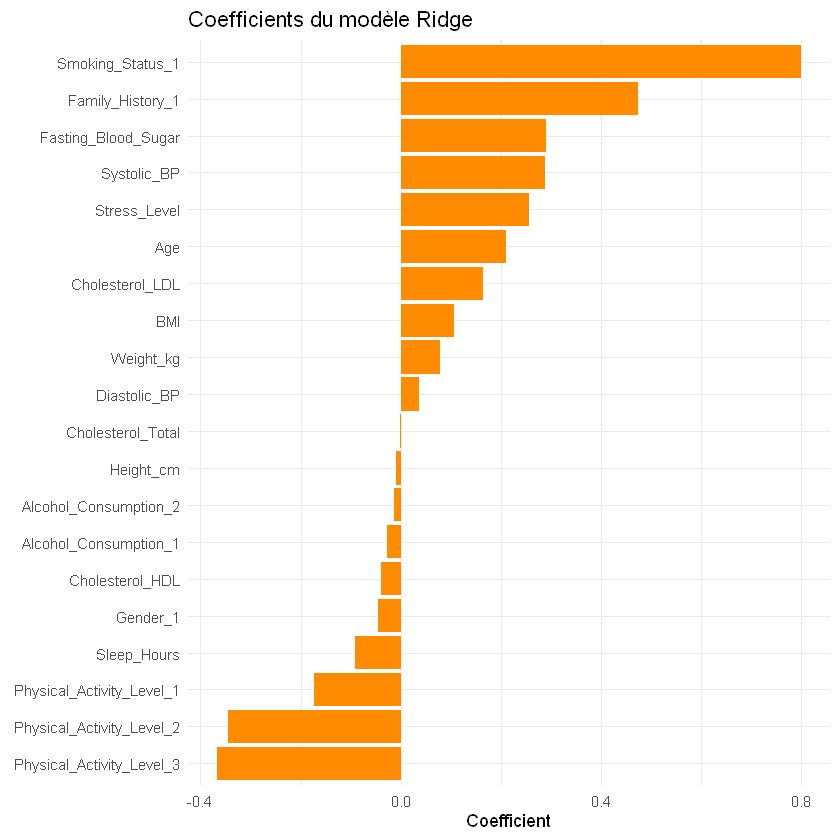

In [19]:
# Coefficients du modèle Ridge
coef_ridge <- coef(cv_ridge, s = "lambda.min")
coef_df_r  <- data.frame(var = rownames(coef_ridge)[-1],
                         coef = as.numeric(coef_ridge[-1, 1]))
coef_df_r_sorted <- coef_df_r[order(coef_df_r$coef), ]
coef_df_r_sorted$var <- factor(coef_df_r_sorted$var, levels = coef_df_r_sorted$var)

options(repr.plot.width = 7, repr.plot.height = 7)
ggplot(coef_df_r_sorted, aes(x = var, y = coef)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(x = NULL, y = "Coefficient", title = "Coefficients du modèle Ridge") +
  theme_minimal()


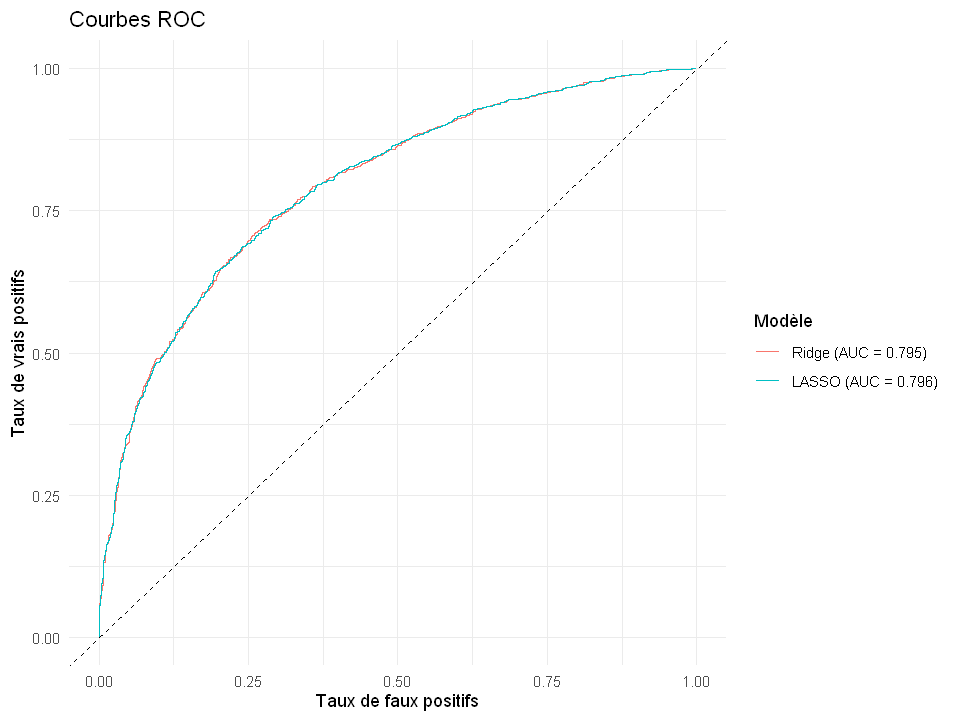

In [20]:
# Comparaison des courbes ROC : Ridge vs LASSO
comparer_ROC(list(Ridge = p_ridge, LASSO = p_lasso))


La pénalité Ridge réduit l'amplitude de tous les coefficients sans en mettre aucun à zéro. On le voit notamment sur les variables les plus discriminantes : `Smoking_Status_1` passe de +0.91 (LASSO) à +0.80 (Ridge), et les coefficients d'activité physique sont également plus modérés. Les variables les plus importantes restent les mêmes. En performance test, l'AUC est quasiment identique au LASSO (0.7954 vs 0.7956), mais l'accuracy est légèrement plus faible (0.7260 vs 0.7327). Visuellement, les deux courbes ROC se superposent presque totalement : la pénalité L2 produit un modèle aussi discriminant que la L1 mais légèrement moins précis au seuil 0.5.

### 1.4 Modèle avec pénalisation Elastic net

L'Elastic net est une combinaison des pénalisations L1 et L2. Il y a deux hyper-paramètres à optimiser : la force globale de la pénalisation $\lambda$, et le mélange $\alpha \in [0, 1]$ qui contrôle la proportion entre Ridge ($\alpha = 0$) et LASSO ($\alpha = 1$). On parcourt une grille de valeurs de $\alpha$ et, pour chaque valeur, on choisit $\lambda$ par validation croisée.

In [21]:
# Grille sur alpha, validation croisée interne pour lambda
alphas    <- c(0.1, 0.3, 0.5, 0.7, 0.9)
best_auc  <- -Inf
best_alpha <- NA
best_lambda <- NA
cv_en <- NULL
for (a in alphas) {
  set.seed(11)
  cv_tmp <- cv.glmnet(x_train_mat, y_train_num, family = "binomial",
                      alpha = a, type.measure = "auc", nfolds = 5)
  auc_a <- max(cv_tmp$cvm)
  cat(sprintf("  alpha = %.2f  ->  AUC CV = %.4f, lambda.min = %.5f\n",
              a, auc_a, cv_tmp$lambda.min))
  if (auc_a > best_auc) {
    best_auc <- auc_a; best_alpha <- a; best_lambda <- cv_tmp$lambda.min; cv_en <- cv_tmp
  }
}
cat(sprintf("\nMeilleurs paramètres : alpha = %.2f, lambda = %.5f, AUC CV = %.4f\n",
            best_alpha, best_lambda, best_auc))


  alpha = 0.10  ->  AUC CV = 0.8096, lambda.min = 0.00164
  alpha = 0.30  ->  AUC CV = 0.8096, lambda.min = 0.00115
  alpha = 0.50  ->  AUC CV = 0.8096, lambda.min = 0.00100
  alpha = 0.70  ->  AUC CV = 0.8096, lambda.min = 0.00072
  alpha = 0.90  ->  AUC CV = 0.8096, lambda.min = 0.00061

Meilleurs paramètres : alpha = 0.30, lambda = 0.00115, AUC CV = 0.8096


In [22]:
# Évaluation de l'Elastic net sur l'échantillon test
p_en      <- predict(cv_en, newx = x_test_mat, s = "lambda.min", type = "response")[, 1]
y_pred_en <- factor(as.integer(p_en > 0.5), levels = c("0", "1"))
acc_en    <- mean(y_pred_en == Y_test_AVC)

roc_en <- roc(Y_test_AVC, p_en, levels = c("0", "1"), direction = "<", quiet = TRUE)
auc_en <- as.numeric(auc(roc_en))

cat(sprintf("Accuracy test : %.4f\n", acc_en))
cat(sprintf("AUC test      : %.4f\n", auc_en))
cat("Matrice de confusion :\n")
print(table(predit = y_pred_en, reel = Y_test_AVC))


Accuracy test : 0.7317
AUC test      : 0.7956
Matrice de confusion :
      reel
predit    0    1
     0 1369  481
     1  324  826


Gender_1: -0.0494
Smoking_Status_1: 0.9052
Alcohol_Consumption_1: -0.0270
Alcohol_Consumption_2: -0.0157
Physical_Activity_Level_1: -0.2643
Physical_Activity_Level_2: -0.4541
Physical_Activity_Level_3: -0.4656
Family_History_1: 0.5412
Age: 0.2345
Height_cm: 0.0000
Weight_kg: 0.0664
BMI: 0.1290
Systolic_BP: 0.3565
Diastolic_BP: -0.0048
Cholesterol_Total: -0.0424
Cholesterol_LDL: 0.2109
Cholesterol_HDL: -0.0402
Fasting_Blood_Sugar: 0.3295
Stress_Level: 0.2928
Sleep_Hours: -0.1065

Nombre de coefficients exactement nuls : 1


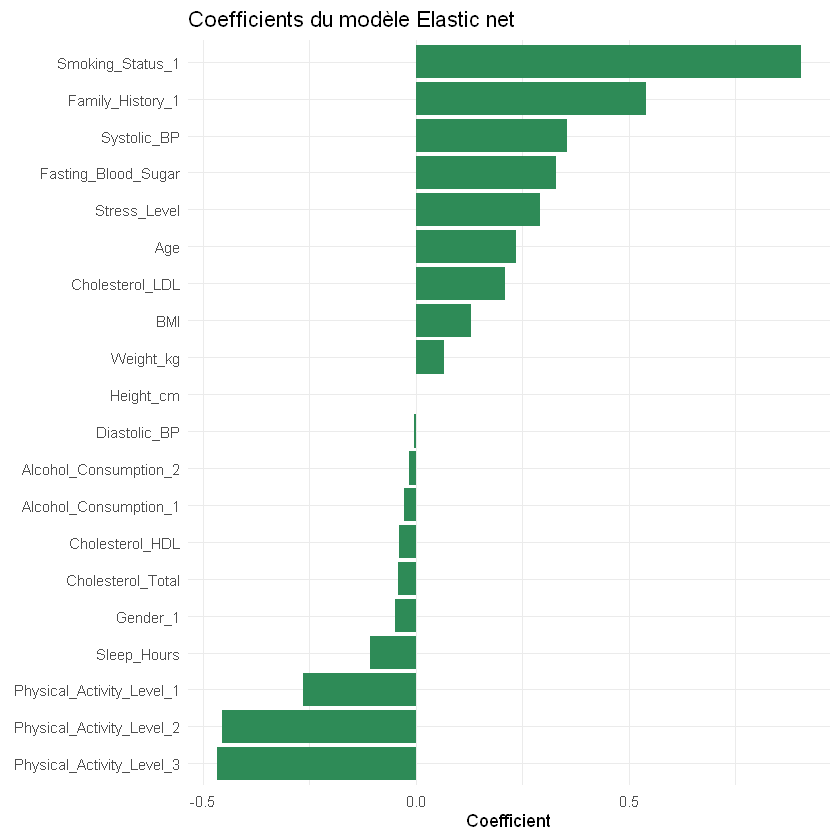

In [23]:
# Coefficients du modèle Elastic net
coef_en <- coef(cv_en, s = "lambda.min")
coef_df_en <- data.frame(var = rownames(coef_en)[-1],
                         coef = as.numeric(coef_en[-1, 1]))
coef_df_en_sorted <- coef_df_en[order(coef_df_en$coef), ]
coef_df_en_sorted$var <- factor(coef_df_en_sorted$var, levels = coef_df_en_sorted$var)

options(repr.plot.width = 7, repr.plot.height = 7)
ggplot(coef_df_en_sorted, aes(x = var, y = coef)) +
  geom_col(fill = "seagreen") +
  coord_flip() +
  labs(x = NULL, y = "Coefficient", title = "Coefficients du modèle Elastic net") +
  theme_minimal()

for (i in seq_len(nrow(coef_df_en))) {
  cat(sprintf("%s: %.4f\n", coef_df_en$var[i], coef_df_en$coef[i]))
}
cat(sprintf("\nNombre de coefficients exactement nuls : %d\n", sum(coef_df_en$coef == 0)))


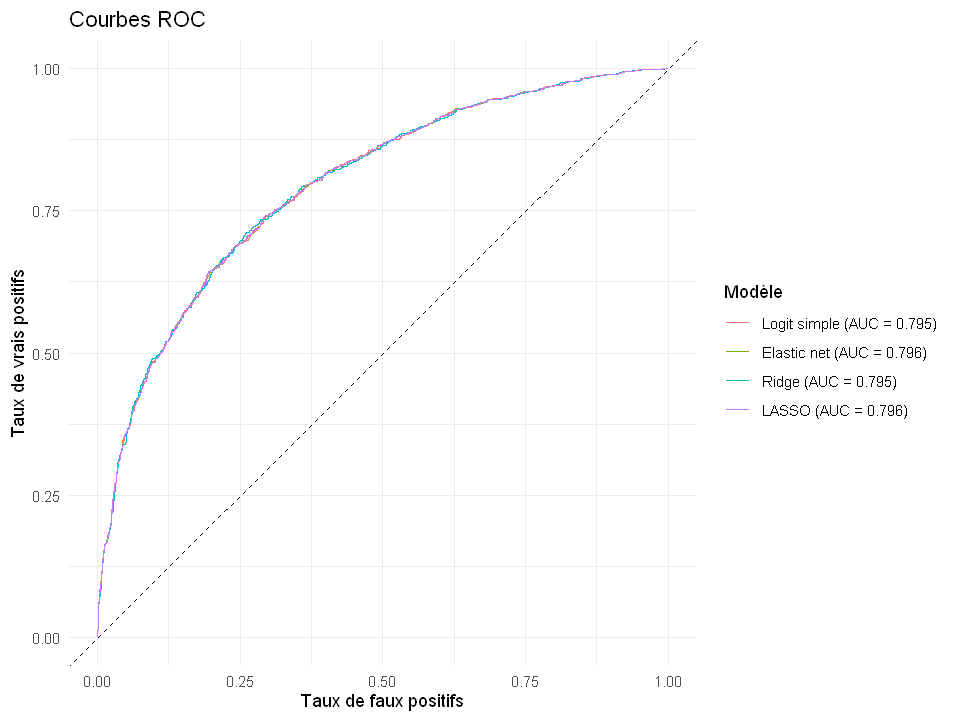

In [24]:
# Comparaison des courbes ROC des 4 modèles linéaires
comparer_ROC(list(`Logit simple` = p_simple,
                  `Elastic net`  = p_en,
                  Ridge         = p_ridge,
                  LASSO         = p_lasso))


Tous les niveaux de $\alpha$ testés produisent une AUC quasi indistinguable en validation croisée (0.8096 pour les cinq valeurs), la valeur retenue ($\alpha = 0.30$) ne s'impose donc que par une variation infime à la 5e décimale. Sur l'échantillon test, l'Elastic net se comporte de manière très proche du LASSO (accuracy 0.7317, AUC 0.7956) et met la même unique variable à zéro (`Height_cm`).

Conclusion partielle sur les modèles linéaires : les quatre modèles (logistique simple, LASSO, Ridge, Elastic net) donnent des performances de discrimination quasiment identiques sur ces données (AUC test autour de 0.795). Les écarts d'accuracy au seuil 0.5 (0.726 à 0.733) tiennent principalement au léger déséquilibre des classes (1693 patients à faible risque vs 1307 à risque élevé dans l'échantillon test). La pénalisation et la sélection n'apportent pas de gain prédictif ici, mais le LASSO et l'Elastic net offrent un léger gain d'interprétabilité en mettant `Height_cm` à zéro.

### 1.5 Modèle avec sélection de variables

On utilise une procédure d'élimination récursive de variables par validation croisée (5 plis). À chaque itération, on ajuste une régression logistique sur les variables courantes, on classe les variables par importance (amplitude des coefficients standardisés) et on retire la moins importante. La taille du modèle final est choisie pour atteindre une AUC moyenne en CV proche de l'optimum, en privilégiant la parcimonie : on retient la plus petite taille dont l'AUC reste à moins de 1.5 % du maximum.

Nombre optimal de variables : 10
Variables retenues (par ordre d'importance) :
 [1] "Smoking_Status_1"          "Family_History_1"         
 [3] "Physical_Activity_Level_3" "Physical_Activity_Level_2"
 [5] "Fasting_Blood_Sugar"       "Stress_Level"             
 [7] "Physical_Activity_Level_1" "Systolic_BP"              
 [9] "Age"                       "Cholesterol_LDL"          

Variables éliminées :
 [1] "Gender_1"              "Alcohol_Consumption_1" "Alcohol_Consumption_2"
 [4] "Height_cm"             "Weight_kg"             "BMI"                  
 [7] "Diastolic_BP"          "Cholesterol_Total"     "Cholesterol_HDL"      
[10] "Sleep_Hours"          


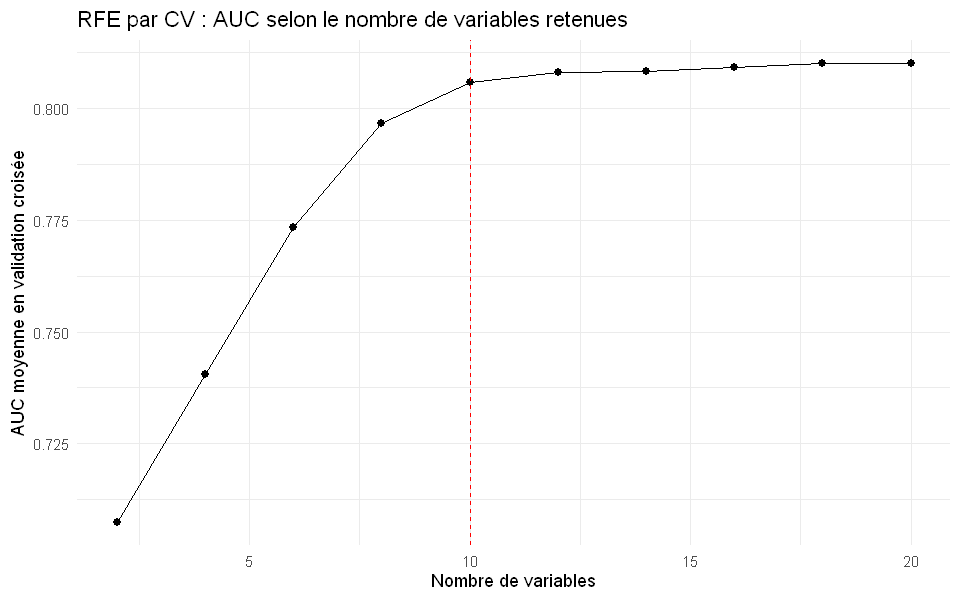

In [25]:
# Étiquettes nommées pour les fonctions caret qui exigent des noms de classes valides
Y_train_AVC_named <- factor(Y_train_AVC, levels = c("0", "1"), labels = c("low", "high"))
Y_test_AVC_named  <- factor(Y_test_AVC,  levels = c("0", "1"), labels = c("low", "high"))

# Configuration de l'élimination récursive
ctrl_rfe <- rfeControl(functions = lrFuncs, method = "cv", number = 5, verbose = FALSE)
ctrl_rfe$functions$summary    <- twoClassSummary   # scoring AUC
ctrl_rfe$functions$selectSize <- pickSizeTolerance # plus petite taille à 1.5 % du max

set.seed(11)
rfe_res <- rfe(x = Xr_train, y = Y_train_AVC_named,
               sizes = c(2, 4, 6, 8, 10, 12, 14, 16, 18, 20),
               rfeControl = ctrl_rfe,
               metric = "ROC")

cat(sprintf("Nombre optimal de variables : %d\n", rfe_res$optsize))
cat("Variables retenues (par ordre d'importance) :\n")
sel_vars <- predictors(rfe_res)
print(sel_vars)
cat("\nVariables éliminées :\n")
print(setdiff(colnames(Xr_train), sel_vars))

# Courbe : AUC CV en fonction du nombre de variables
options(repr.plot.width = 8, repr.plot.height = 5)
ggplot(rfe_res$results, aes(x = Variables, y = ROC)) +
  geom_line() + geom_point(size = 2) +
  geom_vline(xintercept = rfe_res$optsize, linetype = "dashed", color = "red") +
  labs(x = "Nombre de variables", y = "AUC moyenne en validation croisée",
       title = "RFE par CV : AUC selon le nombre de variables retenues") +
  theme_minimal()


La procédure d'élimination récursive retient 10 variables, en éliminant `Gender_1`, `Alcohol_Consumption_1`, `Alcohol_Consumption_2`, `Height_cm`, `Weight_kg`, `BMI`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_HDL` et `Sleep_Hours`. Ce choix est cohérent avec les résultats observés sur les modèles linéaires pénalisés : les variables éliminées ont toutes des coefficients de faible amplitude (ou nul pour `Height_cm` dans le LASSO), ce qui indique une faible contribution prédictive. Sur la courbe d'AUC selon le nombre de variables, on voit que la performance plafonne autour de 10 à 12 variables (AUC CV ≈ 0.806), avec un gain marginal quand on passe à 20 variables (AUC CV ≈ 0.810). En termes d'interprétabilité, ce modèle simplifie l'analyse beaucoup plus que la pénalisation LASSO, qui n'avait éliminé qu'une seule variable.

In [26]:
# Refit d'une régression logistique sans pénalisation sur les variables retenues
df_train_sel <- data.frame(Y = Y_train_AVC, Xr_train[, sel_vars, drop = FALSE])
df_test_sel  <- data.frame(Xr_test[, sel_vars, drop = FALSE])
logit_sel <- glm(Y ~ ., data = df_train_sel, family = binomial)

p_sel      <- predict(logit_sel, newdata = df_test_sel, type = "response")
y_pred_sel <- factor(as.integer(p_sel > 0.5), levels = c("0", "1"))
acc_sel    <- mean(y_pred_sel == Y_test_AVC)

roc_sel <- roc(Y_test_AVC, p_sel, levels = c("0", "1"), direction = "<", quiet = TRUE)
auc_sel <- as.numeric(auc(roc_sel))

cat(sprintf("Accuracy test : %.4f\n", acc_sel))
cat(sprintf("AUC test      : %.4f\n", auc_sel))
cat("Matrice de confusion :\n")
print(table(predit = y_pred_sel, reel = Y_test_AVC))


Accuracy test : 0.7187
AUC test      : 0.7911
Matrice de confusion :
      reel
predit    0    1
     0 1344  495
     1  349  812


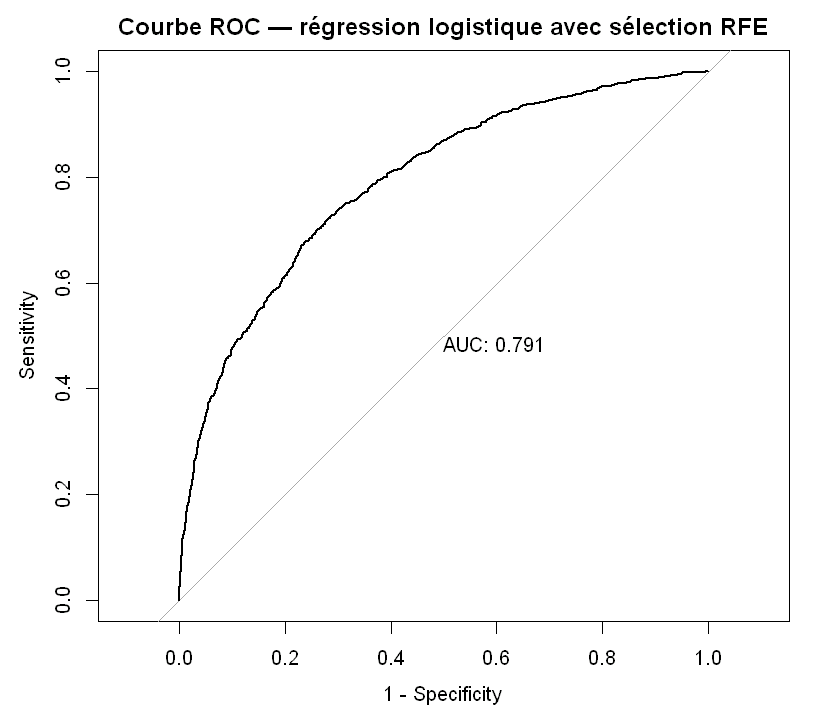

In [27]:
# Courbe ROC du modèle avec sélection
options(repr.plot.width = 7, repr.plot.height = 6)
plot(roc_sel, main = "Courbe ROC — régression logistique avec sélection RFE",
     legacy.axes = TRUE, print.auc = TRUE)


Le modèle réajusté sur les 10 variables retenues atteint une accuracy de 0.7187 et une AUC de 0.7911 sur l'échantillon test. Les performances sont très proches des modèles linéaires précédents (logistique simple : accuracy 0.732, AUC 0.795 ; LASSO : accuracy 0.7327, AUC 0.7956) malgré la réduction de moitié du nombre de variables explicatives. C'est donc à ce stade le meilleur compromis performance / interprétabilité parmi les modèles linéaires testés.

## 2. kNN et SVM

Dans cette partie, on étudie deux méthodes de classification non linéaires :
- le kNN (k plus proches voisins)
- le SVM (machines à vecteurs de support)

Pour chaque méthode, on optimise les hyperparamètres sur l'échantillon d'apprentissage par validation croisée, avant de comparer la performance des modèles sur l'échantillon de test.

### 2.1 kNN

Le kNN classe une observation en regardant ses plus proches voisins. Le paramètre `k` règle le compromis biais / variance :
- petit `k` : frontière très flexible, variance forte
- grand `k` : frontière plus lisse, biais plus élevé.

On parcourt une grille de valeurs de `k` par validation croisée à 5 plis, en maximisant l'AUC. Les variables ayant déjà été standardisées, on utilise la distance euclidienne et un vote uniforme entre voisins.

In [28]:
k_grid <- expand.grid(k = c(3, 20, 40, 60, 80, 100, 105, 110, 120,
                            150, 200, 225, 250, 275, 300))

ctrl_knn <- trainControl(method = "cv", number = 5,
                         classProbs = TRUE, summaryFunction = twoClassSummary,
                         savePredictions = "final")

set.seed(11)
knn_fit <- train(x = Xr_train, y = Y_train_AVC_named,
                 method = "knn", metric = "ROC",
                 trControl = ctrl_knn, tuneGrid = k_grid)

cat(sprintf("k optimal       : %d\n", knn_fit$bestTune$k))
cat(sprintf("AUC moyenne CV  : %.4f\n", max(knn_fit$results$ROC)))


k optimal       : 300
AUC moyenne CV  : 0.8002


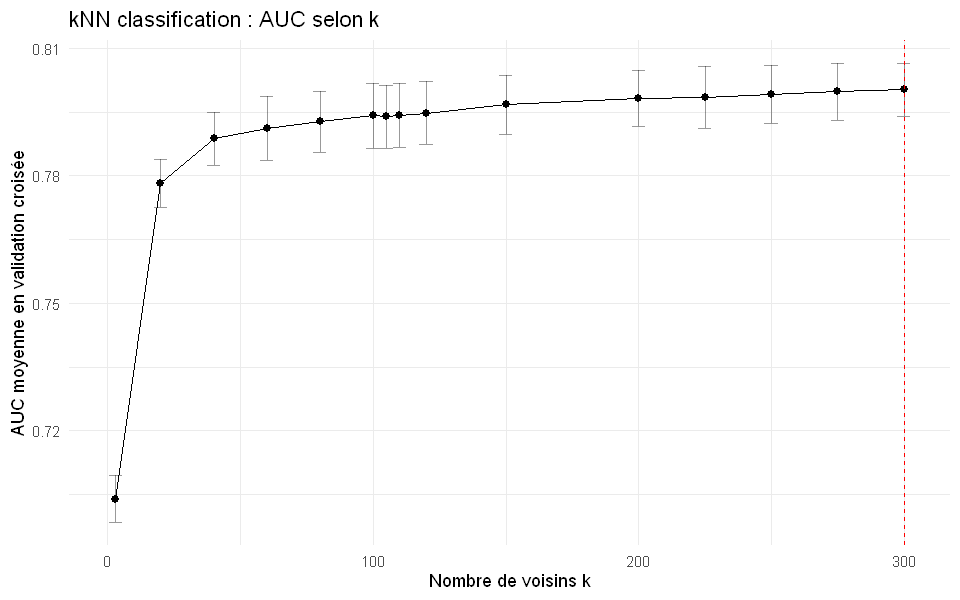

In [29]:
# Courbe AUC validation croisée selon k
options(repr.plot.width = 8, repr.plot.height = 5)
ggplot(knn_fit$results, aes(x = k, y = ROC)) +
  geom_line() + geom_point(size = 2) +
  geom_errorbar(aes(ymin = ROC - ROCSD, ymax = ROC + ROCSD),
                width = 5, alpha = 0.4) +
  geom_vline(xintercept = knn_fit$bestTune$k, linetype = "dashed", color = "red") +
  labs(x = "Nombre de voisins k", y = "AUC moyenne en validation croisée",
       title = "kNN classification : AUC selon k") +
  theme_minimal()


Accuracy test : 0.7183
AUC test      : 0.7875


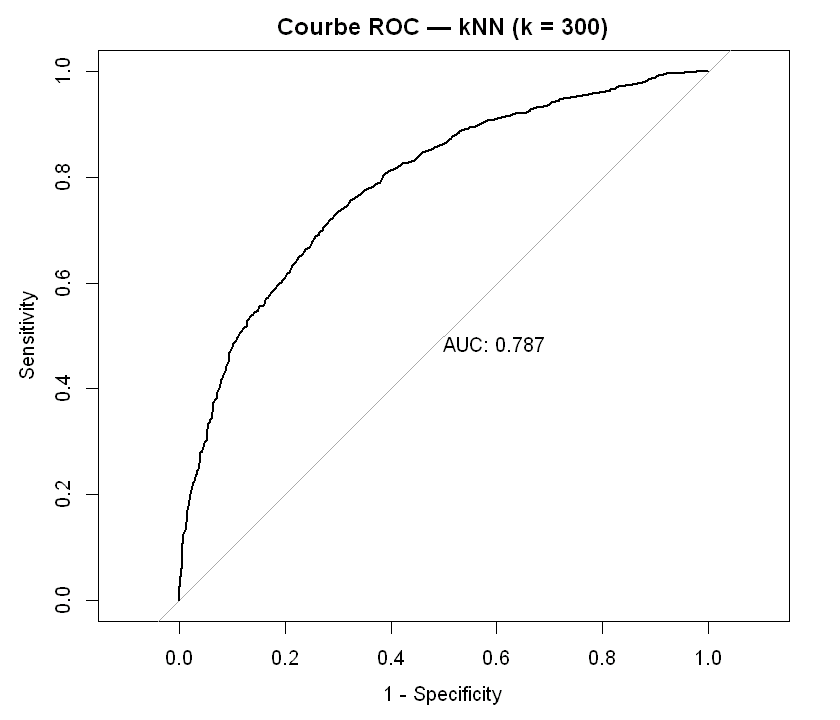

In [30]:
# Évaluation du kNN sur le test
p_knn      <- predict(knn_fit, newdata = Xr_test, type = "prob")[, "high"]
y_pred_knn <- predict(knn_fit, newdata = Xr_test)
acc_knn    <- mean(y_pred_knn == Y_test_AVC_named)

roc_knn <- roc(Y_test_AVC_named, p_knn, levels = c("low", "high"),
               direction = "<", quiet = TRUE)
auc_knn <- as.numeric(auc(roc_knn))

cat(sprintf("Accuracy test : %.4f\n", acc_knn))
cat(sprintf("AUC test      : %.4f\n", auc_knn))

# Courbe ROC du kNN
options(repr.plot.width = 7, repr.plot.height = 6)
plot(roc_knn, main = sprintf("Courbe ROC — kNN (k = %d)", knn_fit$bestTune$k),
     legacy.axes = TRUE, print.auc = TRUE)


La validation croisée retient un kNN avec `k = 300`, qui correspond à la plus grande valeur testée. La courbe d'AUC en validation croisée croît rapidement entre `k = 3` (AUC ≈ 0.70) et `k = 80` (AUC ≈ 0.79), puis atteint un plateau autour de 0.80. L'écart entre `k = 250` et `k = 300` est inférieur à l'écart-type estimé, ce qui signifie que le choix précis dans cette zone est peu informatif. La règle heuristique `k ≈ √n` (avec n = 12 000, soit `k ≈ 110`) est ici sous-optimale : un voisinage plus large améliore la généralisation en réduisant la variance.

Sur l'échantillon test, le kNN atteint une accuracy de 0.7183 et une AUC de 0.7875. La performance reste légèrement inférieure à celle des modèles linéaires, ce qui suggère que la frontière de décision optimale est essentiellement linéaire sur ces données.

### 2.2 SVM

Le SVM cherche un hyperplan séparateur à marge maximale. On compare ici deux types de noyaux :
- un noyau linéaire, où le paramètre `cost` contrôle le compromis entre la largeur de marge et les erreurs tolérées
- un noyau RBF (radial basis function), où s'ajoute `gamma` qui contrôle la flexibilité locale de la frontière. Un noyau trop flexible peut produire du surapprentissage.

Le SVM avec noyau RBF est coûteux en calcul sur l'ensemble du train (12 000 observations). On adopte donc une stratégie raisonnable : sélection des hyperparamètres par validation croisée sur un sous-échantillon stratifié de 4 000 observations, puis prédictions sur l'échantillon test complet sans réentraînement supplémentaire.

In [31]:
# Sous-échantillon stratifié de 4 000 observations
set.seed(42)
idx_svm <- createDataPartition(Y_train_AVC_named,
                               p = 4000 / length(Y_train_AVC_named),
                               list = FALSE)[, 1]
X_svm_train <- Xr_train[idx_svm, , drop = FALSE]
y_svm_train <- Y_train_AVC_named[idx_svm]
df_svm <- data.frame(Y = y_svm_train, X_svm_train)

cat(sprintf("Taille sous-échantillon : %d (high : %d, low : %d)\n",
            length(idx_svm),
            sum(y_svm_train == "high"),
            sum(y_svm_train == "low")))


Taille sous-échantillon : 4001 (high : 1745, low : 2256)


In [32]:
# SVM linéaire : grille sur cost
set.seed(42)
tune_svm_lin <- tune.svm(Y ~ ., data = df_svm,
                          kernel = "linear",
                          cost = c(0.1, 0.5, 1),
                          tunecontrol = tune.control(cross = 3))

cat("SVM linéaire — erreur de classification en CV :\n")
print(tune_svm_lin$performances)


SVM linéaire — erreur de classification en CV :
  cost     error dispersion
1  0.1 0.2849228 0.02197909
2  0.5 0.2821751 0.01532938
3  1.0 0.2821751 0.01532938


In [33]:
# SVM RBF : grille sur cost x gamma
# Pour des données standardisées (variance unité), l'équivalent de gamma 'scale' est 1 / p
gamma_scale <- 1 / ncol(X_svm_train)
cat(sprintf("Equivalent gamma 'scale' (1 / p) : %.5f\n", gamma_scale))

set.seed(42)
tune_svm_rbf <- tune.svm(Y ~ ., data = df_svm,
                          kernel = "radial",
                          cost  = c(0.5, 1),
                          gamma = c(gamma_scale, 0.01),
                          tunecontrol = tune.control(cross = 3))

cat("\nSVM RBF — erreur de classification en CV :\n")
print(tune_svm_rbf$performances)


Equivalent gamma 'scale' (1 / p) : 0.05000

SVM RBF — erreur de classification en CV :
  gamma cost     error  dispersion
1  0.05  0.5 0.2724292 0.009199446
2  0.01  0.5 0.2831748 0.015364057
3  0.05  1.0 0.2761789 0.007241627
4  0.01  1.0 0.2811760 0.012955668


In [34]:
# Sélection du meilleur noyau par erreur CV
best_err_lin <- tune_svm_lin$best.performance
best_err_rbf <- tune_svm_rbf$best.performance
cat(sprintf("Meilleure erreur CV linéaire : %.4f  (accuracy CV ≈ %.4f)\n",
            best_err_lin, 1 - best_err_lin))
cat(sprintf("Meilleure erreur CV RBF     : %.4f  (accuracy CV ≈ %.4f)\n",
            best_err_rbf, 1 - best_err_rbf))

if (best_err_lin <= best_err_rbf) {
  cat("\nNoyau retenu : linéaire\n")
  best_params <- tune_svm_lin$best.parameters
  set.seed(42)
  svm_best <- svm(Y ~ ., data = df_svm,
                  kernel = "linear", cost = best_params$cost, probability = TRUE)
} else {
  cat("\nNoyau retenu : RBF\n")
  best_params <- tune_svm_rbf$best.parameters
  set.seed(42)
  svm_best <- svm(Y ~ ., data = df_svm,
                  kernel = "radial", cost = best_params$cost, gamma = best_params$gamma,
                  probability = TRUE)
}
cat("Paramètres retenus :\n"); print(best_params)


Meilleure erreur CV linéaire : 0.2822  (accuracy CV ≈ 0.7178)
Meilleure erreur CV RBF     : 0.2724  (accuracy CV ≈ 0.7276)



Noyau retenu : RBF
Paramètres retenus :
  gamma cost
1  0.05  0.5


In [35]:
# Évaluation du SVM sur l'échantillon test complet
pred_svm_full <- predict(svm_best, newdata = data.frame(Xr_test), probability = TRUE)
p_svm      <- attr(pred_svm_full, "probabilities")[, "high"]
y_pred_svm <- factor(pred_svm_full, levels = c("low", "high"))

acc_svm <- mean(y_pred_svm == Y_test_AVC_named)
tab_svm <- table(predit = y_pred_svm, reel = Y_test_AVC_named)
sens_svm <- tab_svm["high", "high"] / sum(tab_svm[, "high"])
spec_svm <- tab_svm["low",  "low"]  / sum(tab_svm[, "low"])
bal_acc_svm <- (sens_svm + spec_svm) / 2

roc_svm <- roc(Y_test_AVC_named, p_svm, levels = c("low", "high"),
               direction = "<", quiet = TRUE)
auc_svm <- as.numeric(auc(roc_svm))

cat(sprintf("Accuracy test     : %.4f\n", acc_svm))
cat(sprintf("Balanced accuracy : %.4f\n", bal_acc_svm))
cat(sprintf("AUC test          : %.4f\n", auc_svm))
cat("Matrice de confusion :\n")
print(tab_svm)


Accuracy test     : 0.7230
Balanced accuracy : 0.7106
AUC test          : 0.7718
Matrice de confusion :
      reel
predit  low high
  low  1366  504
  high  327  803


La validation croisée retient un SVM à noyau RBF avec `cost = 0.5` et `gamma = 0.05` . Son erreur CV est de 0.272 (accuracy CV ≈ 0.728), contre 0.282 (accuracy CV ≈ 0.718) pour le meilleur SVM linéaire. La différence reste faible mais favorise le noyau RBF dans la grille testée.

Sur l'échantillon test complet, le SVM RBF atteint une accuracy de 0.7230, une balanced accuracy de 0.7106 et une AUC de 0.7718. Les performances en accuracy sont comparables aux modèles linéaires, mais l'AUC est sensiblement plus basse.

In [36]:
# Tableau récapitulatif des deux modèles
classification_results <- data.frame(
  Modele             = c("kNN classification", "SVM classification"),
  Accuracy           = c(acc_knn, acc_svm),
  `Balanced accuracy`= c(
    (sum(y_pred_knn == "high" & Y_test_AVC_named == "high") / sum(Y_test_AVC_named == "high") +
     sum(y_pred_knn == "low"  & Y_test_AVC_named == "low")  / sum(Y_test_AVC_named == "low")) / 2,
    bal_acc_svm
  ),
  `ROC-AUC`          = c(auc_knn, auc_svm),
  check.names = FALSE
)
classification_results <- classification_results[order(-classification_results$`Balanced accuracy`), ]
print(classification_results, row.names = FALSE)


             Modele  Accuracy Balanced accuracy   ROC-AUC
 SVM classification 0.7230000         0.7106179 0.7717823
 kNN classification 0.7183333         0.6927022 0.7874844


Le tableau récapitulatif montre que le SVM RBF obtient une accuracy et une balanced accuracy légèrement supérieures au kNN, tandis que le kNN obtient une AUC légèrement plus élevée. Les écarts entre les deux modèles restent modestes (de l'ordre de 0.5 à 2 points selon la métrique). Pendant la sélection des hyperparamètres, le meilleur SVM linéaire atteignait par ailleurs une accuracy CV très proche du SVM RBF (0.718 vs 0.728), ce qui confirme que la frontière de décision optimale est largement linéaire et que les méthodes non linéaires ne tirent pas avantage notable de la complexité supplémentaire qu'elles permettent.

## 3. Arbres de classification et random forest

On reprend les méthodes sur les arbres et les méthodes d'ensemble pour les appliquer à notre jeu de données.

L'objectif est double :
- construire et interpréter un arbre CART pour la classification du risque de maladie cardiaque
- comprendre pourquoi des méthodes d'agrégation comme le bagging, les random forests et le boosting améliorent souvent les performances d'un arbre seul.

Le fil directeur est celui du cours : un arbre est un modèle simple, lisible et non paramétrique, mais aussi instable. Les méthodes d'ensemble ont précisément été introduites pour exploiter cette instabilité afin de réduire la variance, et, dans le cas du boosting, aussi une partie du biais.

### 3.1. Introduction et contexte

Les arbres CART construisent une partition récursive binaire de l'espace des variables explicatives : à chaque noeud, on choisit une variable et un seuil de coupure afin de créer deux sous-groupes aussi homogènes que possible. Dans le cadre de la classification, l'homogénéité d'un noeud peut être mesurée par des critères comme l'indice de Gini ou l'entropie.

Les arbres sont intéressants pour plusieurs raisons :
- ils sont faciles à visualiser et donc relativement interprétables
- ils acceptent naturellement des relations non linéaires et des interactions
- ils peuvent traiter des variables de nature différente
- ce sont des méthodes non paramétriques, donc sans hypothèse linéaire forte.

La limite principale est que les arbres sont instables. Une petite variation des données peut modifier les premières coupures, puis toute la structure du modèle. Cette forte variance peut conduire à du surapprentissage, en particulier si l'on laisse croître un arbre très profond.



In [37]:
# Conteneur partagé pour les résultats des modèles à base d'arbres (rempli au fil de la section)
results_arbres <- list()

store_tree_result <- function(name, acc_train, acc_test, fit_time) {
  results_arbres[[name]] <<- data.frame(
    Modele                   = name,
    `Accuracy train`         = round(acc_train, 4),
    `Accuracy test`          = round(acc_test, 4),
    `Erreur test`            = round(1 - acc_test, 4),
    `Temps entrainement (s)` = round(fit_time, 3),
    check.names = FALSE
  )
  invisible(NULL)
}

# Préparation des data.frames train/test au format formule pour rpart
df_train_tree <- data.frame(Y = Y_train_AVC, Xr_train)
df_test_tree  <- data.frame(Y = Y_test_AVC,  Xr_test)


### 3.2. Première méthode : les arbres de classification

On commence par l'arbre de classification seul (généralement appelé CART pour Classification and Regression Trees) afin d'avoir un modèle de référence. Conformément au cours, l'arbre est construit par découpage binaire récursif : à chaque noeud, on cherche la variable et le seuil qui maximisent le gain d'homogénéité, mesuré par défaut par l'indice de Gini.

L'intérêt du CART est qu'il rend visibles les premières divisions du problème. En contrepartie, si l'arbre devient trop profond, il peut mémoriser des détails trop spécifiques à l'échantillon d'apprentissage. On sélectionne donc la profondeur maximale `maxdepth` par validation croisée à 5 plis sur l'échantillon d'apprentissage.

In [38]:
# Grid search manuel sur maxdepth avec cp = 0 (pas de filtre par gain relatif)
depth_grid <- 1:12
set.seed(42)
folds <- caret::createFolds(Y_train_AVC, k = 5, returnTrain = FALSE)

cv_depth_rows <- list()
for (d in depth_grid) {
  fold_accs <- numeric(0)
  for (fold in folds) {
    train_idx <- setdiff(seq_along(Y_train_AVC), fold)
    set.seed(42)
    m_cv <- rpart(Y ~ ., data = df_train_tree[train_idx, , drop = FALSE],
                  method = "class",
                  control = rpart.control(maxdepth = d, cp = 0, minbucket = 1, xval = 0))
    pred_cv <- predict(m_cv, newdata = df_train_tree[fold, , drop = FALSE], type = "class")
    fold_accs <- c(fold_accs, mean(pred_cv == Y_train_AVC[fold]))
  }
  cv_depth_rows[[length(cv_depth_rows) + 1]] <- data.frame(
    maxdepth = d, acc_cv_mean = mean(fold_accs), acc_cv_sd = sd(fold_accs)
  )
}
cv_depth_df <- do.call(rbind, cv_depth_rows)
best_depth  <- cv_depth_df$maxdepth[which.max(cv_depth_df$acc_cv_mean)]

cat(sprintf("Meilleure profondeur (CV) : %d\n", best_depth))
cat(sprintf("Accuracy moyenne en CV    : %.4f\n", max(cv_depth_df$acc_cv_mean)))

# Refit du modèle final avec la profondeur retenue
set.seed(42)
t0 <- Sys.time()
cart_model <- rpart(Y ~ ., data = df_train_tree, method = "class",
                    control = rpart.control(maxdepth = best_depth, cp = 0, minbucket = 1, xval = 0))
cart_time <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

acc_train_cart <- mean(predict(cart_model, type = "class") == Y_train_AVC)
y_pred_cart    <- predict(cart_model, newdata = Xr_test, type = "class")
acc_test_cart  <- mean(y_pred_cart == Y_test_AVC)
n_leaves_cart  <- sum(cart_model$frame$var == "<leaf>")

cat(sprintf("Accuracy train       : %.4f\n", acc_train_cart))
cat(sprintf("Accuracy test        : %.4f\n", acc_test_cart))
cat(sprintf("Erreur test          : %.4f\n", 1 - acc_test_cart))
cat(sprintf("Profondeur retenue   : %d\n", best_depth))
cat(sprintf("Nombre de feuilles   : %d\n", n_leaves_cart))

store_tree_result("CART", acc_train_cart, acc_test_cart, cart_time)
print(results_arbres[["CART"]])


Meilleure profondeur (CV) : 5
Accuracy moyenne en CV    : 0.7092
Accuracy train       : 0.7239
Accuracy test        : 0.7037
Erreur test          : 0.2963
Profondeur retenue   : 5
Nombre de feuilles   : 23
  Modele Accuracy train Accuracy test Erreur test Temps entrainement (s)
1   CART         0.7239        0.7037      0.2963                  0.064


La validation croisée retient un arbre de profondeur 5. Ce choix limite la complexité du modèle tout en conservant une performance correcte, avec une accuracy moyenne en validation croisée d'environ 0.709.

Sur le test, l'accuracy atteint 0.704, proche du score obtenu en validation croisée. L'écart modéré avec l'accuracy train (0.724) indique que l'arbre ne surapprend pas fortement, même s'il reste moins performant que les meilleurs modèles linéaires précédents. La cellule suivante détaille la matrice de confusion et les variables les plus utilisées par l'arbre.

In [39]:
# Matrice de confusion sur le test
tab_cart <- table(predit = y_pred_cart, reel = Y_test_AVC)
cat("Matrice de confusion :\n")
print(tab_cart)

# Importance des variables pour le CART
cart_imp <- sort(cart_model$variable.importance, decreasing = TRUE)
cat("\nImportance des variables (top 10) :\n")
print(round(head(cart_imp, 10), 4))


Matrice de confusion :
      reel
predit    0    1
     0 1382  578
     1  311  729

Importance des variables (top 10) :
         Smoking_Status_1          Family_History_1               Systolic_BP 
                 743.5138                  237.1811                  176.5325 
      Fasting_Blood_Sugar              Diastolic_BP                       Age 
                  96.7821                   89.8136                   42.0003 
          Cholesterol_LDL                 Weight_kg                       BMI 
                  22.7587                   22.2870                   19.5665 
Physical_Activity_Level_3 
                  18.0256 


La matrice de confusion montre que le CART classe correctement une majorité d'individus à risque faible, mais qu'il reste plus en difficulté pour les individus à risque élevé. Il prédit 729 vrais risques élevés mais en manque 578, ce qui indique une sensibilité encore limitée sur la classe positive.

Les importances des variables confirment le rôle central du statut tabagique, qui domine largement l'arbre (importance ≈ 744). Les antécédents familiaux (≈ 237) et la pression artérielle systolique (≈ 177) arrivent ensuite, ce qui est cohérent avec les facteurs de risque cardiovasculaire attendus. Le CART fournit donc une interprétation lisible, mais ses performances restent modérées.

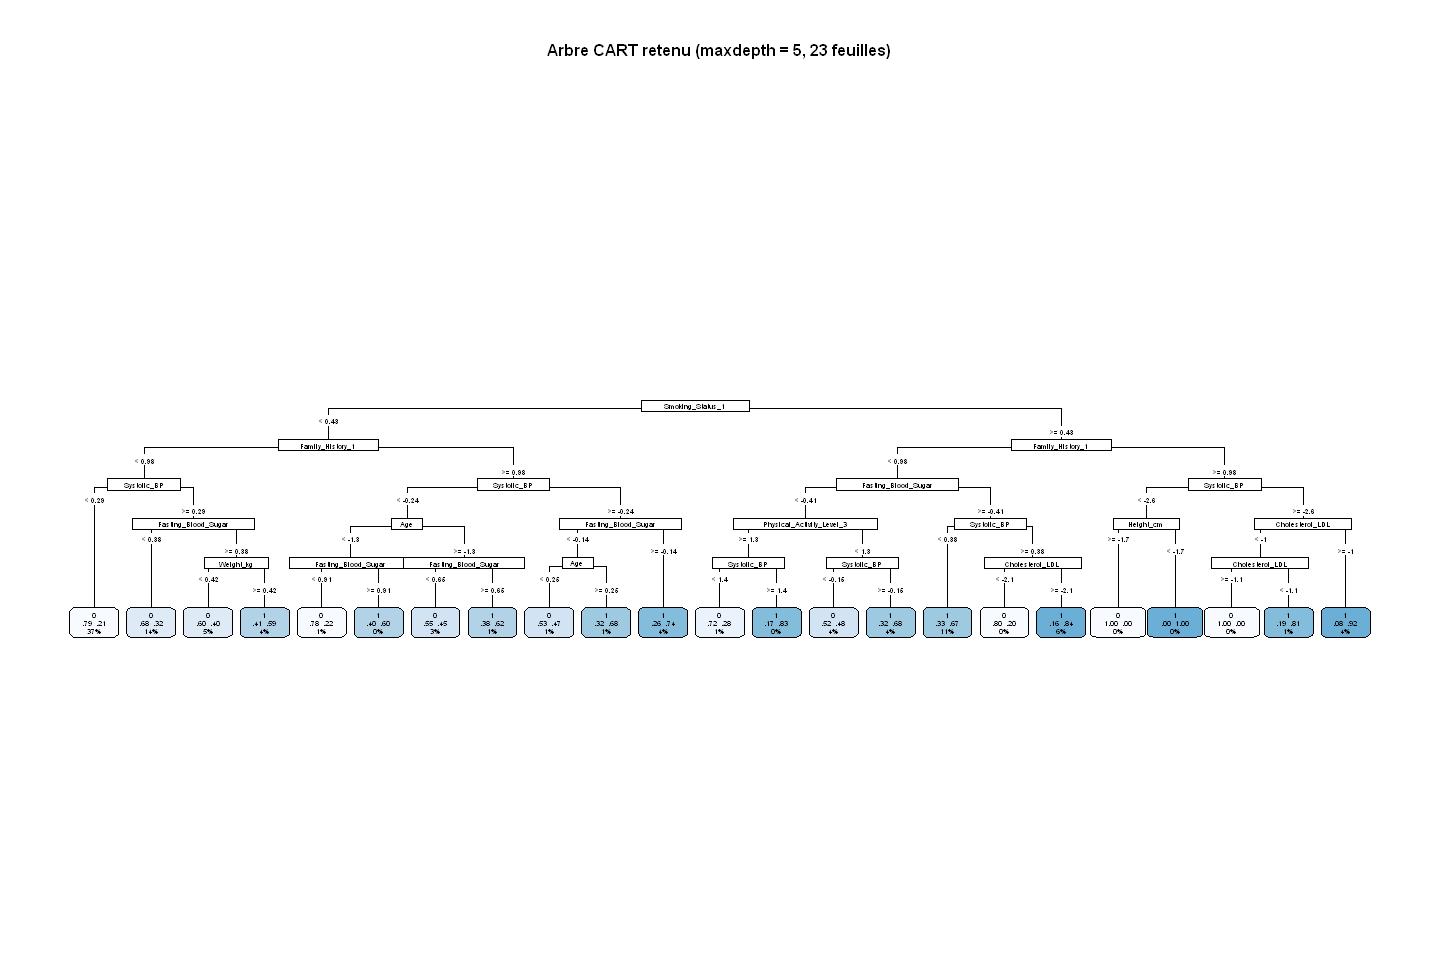

In [40]:
# Visualisation de l'arbre retenu
options(repr.plot.width = 12, repr.plot.height = 8)
rpart.plot(cart_model, type = 5, extra = 104, fallen.leaves = TRUE,
           tweak = 1.2, box.palette = "Blues",
           main = sprintf("Arbre CART retenu (maxdepth = %d, %d feuilles)",
                          best_depth, n_leaves_cart))


Les premières coupures sont particulièrement intéressantes : elles montrent quelles variables interviennent le plus tôt dans la hiérarchie de décision. En général, une variable placée près de la racine a un effet important sur la partition de l'espace. Il faut néanmoins rester prudent : une coupure haute dans l'arbre n'implique pas nécessairement une influence très forte, seulement qu'elle réduit fortement l'hétérogénéité dans cet échantillon. Ici le statut tabagique et les antécédents familiaux apparaissent en haut de l'arbre, suivis par la pression artérielle systolique et la glycémie à jeun, ce qui est cohérent avec les facteurs de risque cardiovasculaire identifiés sur les modèles linéaires.

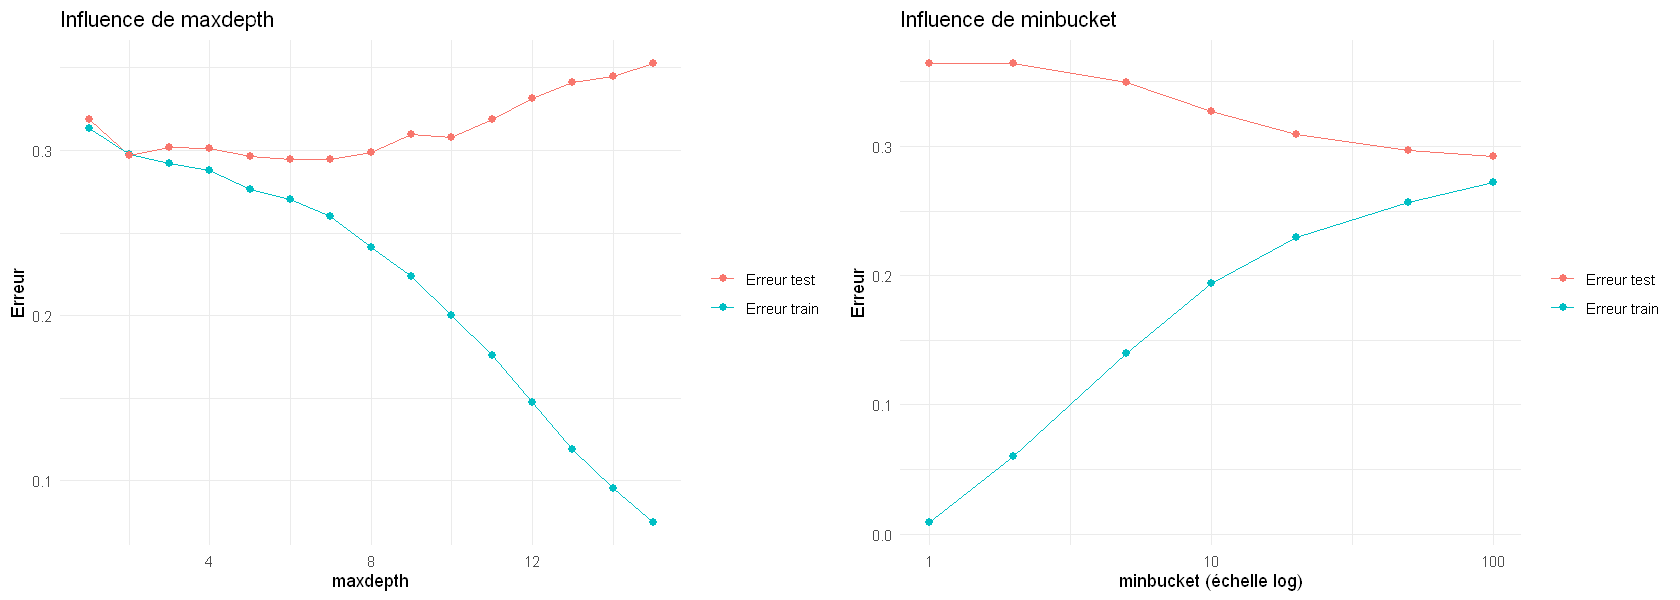

In [41]:
# Courbes d'erreur train/test selon maxdepth (cp = 0, minbucket = 1)
depth_values <- 1:15
depth_rows <- list()
for (d in depth_values) {
  set.seed(42)
  m <- rpart(Y ~ ., data = df_train_tree, method = "class",
             control = rpart.control(maxdepth = d, cp = 0, minbucket = 1, xval = 0))
  depth_rows[[length(depth_rows) + 1]] <- data.frame(
    maxdepth  = d,
    err_train = 1 - mean(predict(m, type = "class") == Y_train_AVC),
    err_test  = 1 - mean(predict(m, newdata = Xr_test, type = "class") == Y_test_AVC),
    n_leaves  = sum(m$frame$var == "<leaf>")
  )
}
depth_df <- do.call(rbind, depth_rows)

# Courbes d'erreur train/test selon minbucket (cp = 0, profondeur libre)
leaf_values <- c(1, 2, 5, 10, 20, 50, 100)
leaf_rows <- list()
for (l in leaf_values) {
  set.seed(42)
  m <- rpart(Y ~ ., data = df_train_tree, method = "class",
             control = rpart.control(minbucket = l, cp = 0, xval = 0))
  leaf_rows[[length(leaf_rows) + 1]] <- data.frame(
    minbucket = l,
    err_train = 1 - mean(predict(m, type = "class") == Y_train_AVC),
    err_test  = 1 - mean(predict(m, newdata = Xr_test, type = "class") == Y_test_AVC),
    n_leaves  = sum(m$frame$var == "<leaf>")
  )
}
leaf_df <- do.call(rbind, leaf_rows)

# Mise en forme pour ggplot (long format)
depth_long <- rbind(
  data.frame(x = depth_df$maxdepth,  err = depth_df$err_train, type = "Erreur train"),
  data.frame(x = depth_df$maxdepth,  err = depth_df$err_test,  type = "Erreur test")
)
leaf_long <- rbind(
  data.frame(x = leaf_df$minbucket,  err = leaf_df$err_train, type = "Erreur train"),
  data.frame(x = leaf_df$minbucket,  err = leaf_df$err_test,  type = "Erreur test")
)

p1 <- ggplot(depth_long, aes(x = x, y = err, color = type)) +
  geom_line() + geom_point(size = 2) +
  labs(x = "maxdepth", y = "Erreur", color = NULL, title = "Influence de maxdepth") +
  theme_minimal()
p2 <- ggplot(leaf_long, aes(x = x, y = err, color = type)) +
  geom_line() + geom_point(size = 2) +
  scale_x_log10() +
  labs(x = "minbucket (échelle log)", y = "Erreur", color = NULL,
       title = "Influence de minbucket") +
  theme_minimal()

options(repr.plot.width = 14, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)


### 3.3. Complexité, biais et variance

Les courbes précédentes illustrent bien le compromis biais / variance vu en cours :
- quand la profondeur est trop faible ou que `minbucket` est trop grand, l'arbre est trop rigide et sous-apprend
- quand la profondeur augmente fortement, l'erreur d'apprentissage continue de diminuer alors que l'erreur de test finit par se stabiliser ou se dégrader : c'est le surapprentissage
- l'écart entre train et test augmente avec la complexité, ce qui traduit la forte variance des arbres.

Cette observation justifie la mise en place d'une procédure d'élagage.

### 3.4. Complexité et pruning

Le pruning est un compromis entre qualité d'ajustement et parcimonie. On part d'un arbre maximal puis on pénalise le nombre de feuilles par un paramètre de complexité noté `cp`. Quand `cp` augmente, certaines branches deviennent trop coûteuses au regard du gain qu'elles apportent, et l'arbre est élagué.

La fonction `rpart` calcule directement la table des `cp` candidats et leur erreur estimée par validation croisée interne (10 plis par défaut). On sélectionne la valeur de `cp` qui minimise l'erreur en validation croisée, puis on élague l'arbre maximal en conséquence.

In [42]:
# Arbre maximal avec validation croisée interne sur cp
set.seed(42)
t0 <- Sys.time()
full_tree <- rpart(Y ~ ., data = df_train_tree, method = "class",
                   control = rpart.control(cp = 0, minbucket = 1, xval = 10))
t_full <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

cat(sprintf("Temps fit arbre maximal : %.2f s\n", t_full))
cat(sprintf("Nombre de feuilles arbre maximal : %d\n",
            sum(full_tree$frame$var == "<leaf>")))

# Sélection du meilleur cp par xerror minimum
cptab <- full_tree$cptable
best_cp_idx <- which.min(cptab[, "xerror"])
best_cp     <- cptab[best_cp_idx, "CP"]

cat(sprintf("cp optimal (xerror min)  : %.6f\n", best_cp))
cat(sprintf("xerror min               : %.4f (xstd = %.4f)\n",
            cptab[best_cp_idx, "xerror"], cptab[best_cp_idx, "xstd"]))

# Élagage
t0 <- Sys.time()
pruned_tree <- prune(full_tree, cp = best_cp)
t_pruned <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

n_leaves_pruned   <- sum(pruned_tree$frame$var == "<leaf>")
acc_train_pruned  <- mean(predict(pruned_tree, type = "class") == Y_train_AVC)
y_pred_pruned     <- predict(pruned_tree, newdata = Xr_test, type = "class")
acc_test_pruned   <- mean(y_pred_pruned == Y_test_AVC)

cat(sprintf("Nombre de feuilles élagué : %d\n", n_leaves_pruned))
cat(sprintf("Accuracy train élagué     : %.4f\n", acc_train_pruned))
cat(sprintf("Accuracy test élagué      : %.4f\n", acc_test_pruned))

store_tree_result("CART élagué", acc_train_pruned, acc_test_pruned, t_full + t_pruned)
print(results_arbres[["CART élagué"]])


Temps fit arbre maximal : 1.33 s
Nombre de feuilles arbre maximal : 2020
cp optimal (xerror min)  : 0.000860
xerror min               : 0.6556 (xstd = 0.0095)
Nombre de feuilles élagué : 68
Accuracy train élagué     : 0.7551
Accuracy test élagué      : 0.7160
       Modele Accuracy train Accuracy test Erreur test Temps entrainement (s)
1 CART élagué         0.7551         0.716       0.284                  1.369


L'élagage sélectionne un `cp` faible (≈ 8.6e-4), ce qui conserve un arbre encore assez détaillé avec 68 feuilles. Par rapport au CART limité par profondeur, l'accuracy test augmente légèrement, passant de 0.7037 à 0.7160.

L'écart entre l'accuracy train (0.7551) et l'accuracy test (0.7160) reste raisonnable, ce qui indique que l'élagage réduit une partie du surapprentissage tout en gardant suffisamment de structure pour prédire correctement. Le CART élagué est donc un peu meilleur que l'arbre initial, mais ses performances restent proches de celles des autres modèles de classification.

Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."


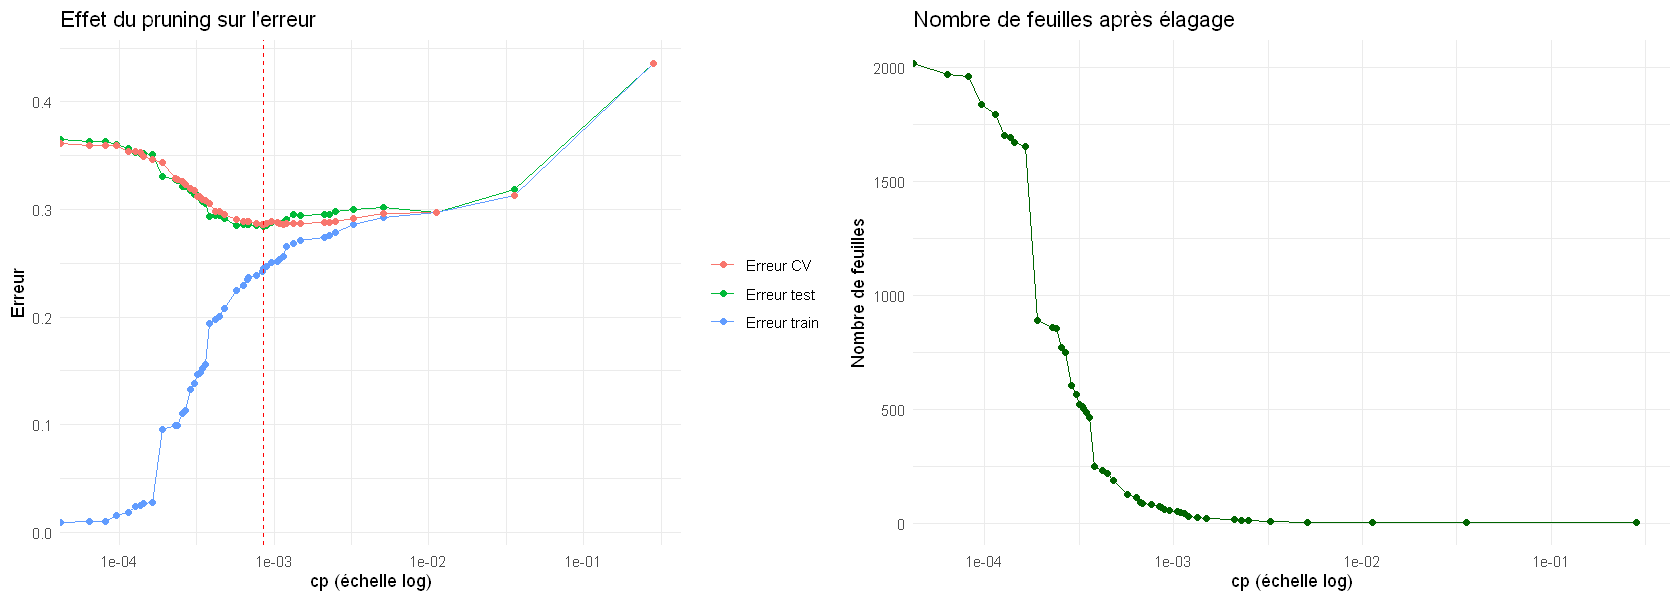

In [43]:
# Tableau des cp testés en CV interne (échantillon)
cptab_df <- as.data.frame(cptab)
cptab_df$err_train <- cptab_df$`rel error` * (1 - mean(Y_train_AVC == "0"))   # erreur relative * baseline
cptab_df$err_cv    <- cptab_df$xerror      * (1 - mean(Y_train_AVC == "0"))

# Recalcul de l'erreur test pour chaque cp candidat de cptab
cptab_df$err_test <- sapply(cptab_df$CP, function(cp_v) {
  t <- prune(full_tree, cp = cp_v)
  1 - mean(predict(t, newdata = Xr_test, type = "class") == Y_test_AVC)
})

cp_long <- rbind(
  data.frame(cp = cptab_df$CP, err = cptab_df$err_train, type = "Erreur train"),
  data.frame(cp = cptab_df$CP, err = cptab_df$err_test,  type = "Erreur test"),
  data.frame(cp = cptab_df$CP, err = cptab_df$err_cv,    type = "Erreur CV")
)

p_err <- ggplot(cp_long, aes(x = cp, y = err, color = type)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = best_cp, linetype = "dashed", color = "red") +
  scale_x_log10() +
  labs(x = "cp (échelle log)", y = "Erreur", color = NULL,
       title = "Effet du pruning sur l'erreur") +
  theme_minimal()

p_leaves <- ggplot(cptab_df, aes(x = CP, y = nsplit + 1)) +
  geom_line(color = "darkgreen") + geom_point(color = "darkgreen") +
  scale_x_log10() +
  labs(x = "cp (échelle log)", y = "Nombre de feuilles",
       title = "Nombre de feuilles après élagage") +
  theme_minimal()

options(repr.plot.width = 14, repr.plot.height = 5)
grid.arrange(p_err, p_leaves, ncol = 2)


L'élagage permet ici de revenir d'un arbre potentiellement trop spécifique vers un arbre plus parcimonieux. On ne cherche pas l'arbre qui ajuste le mieux les données d'apprentissage, mais celui qui offre le meilleur compromis entre ajustement et complexité. En pratique, l'arbre élagué reste interprétable, tout en limitant le surapprentissage.

On obtient l'arbre ci-dessous :

Warning message:
"labs do not fit even at cex 0.15, there may be some overplotting"


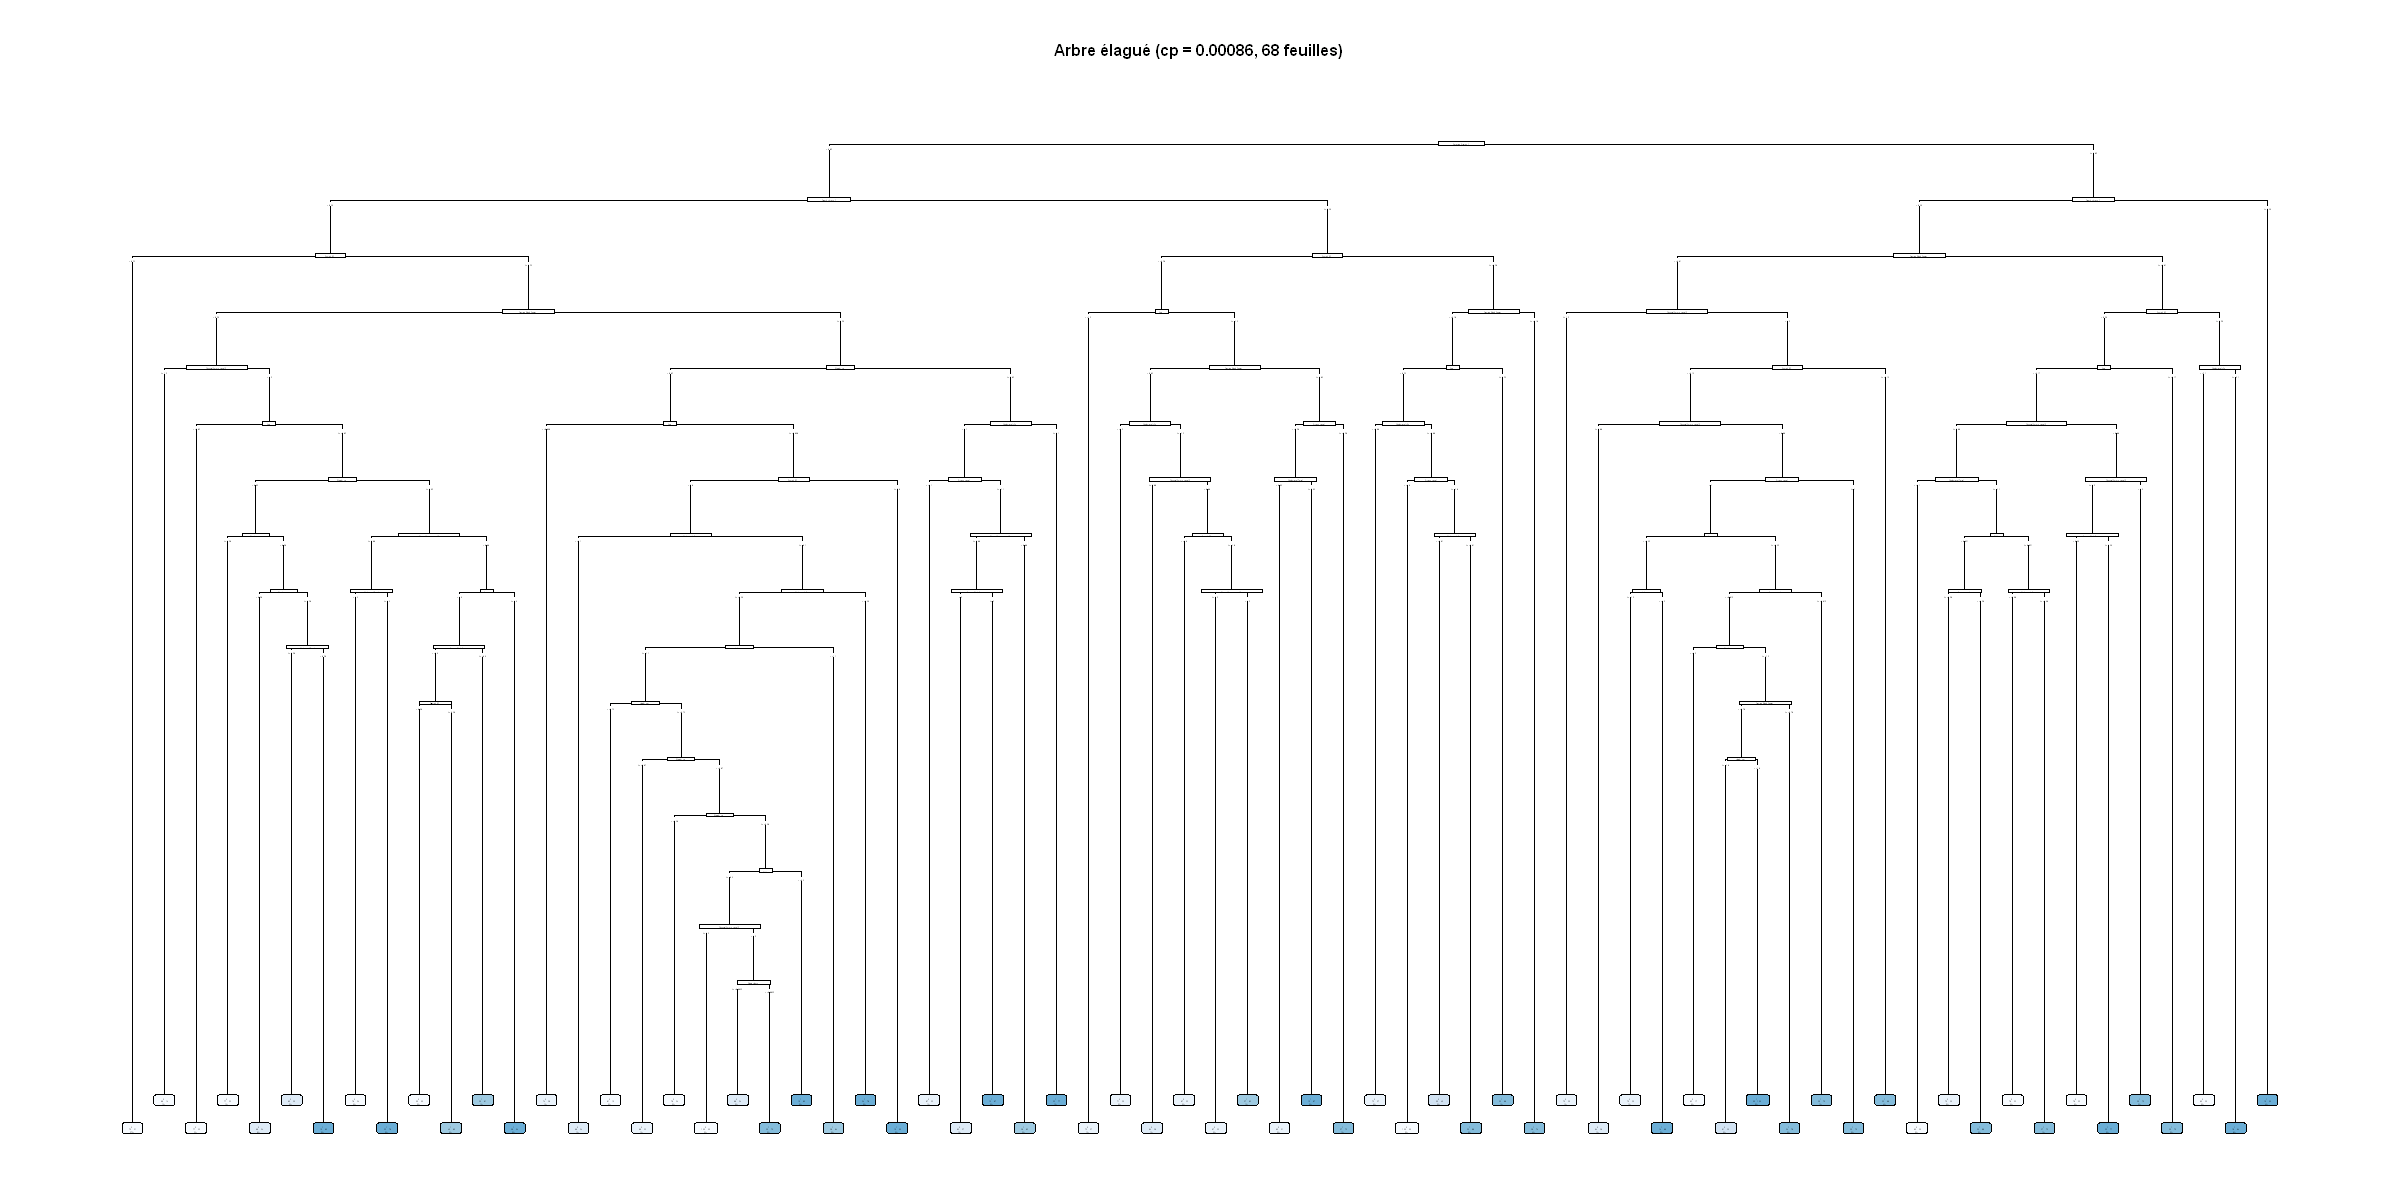

In [44]:
# Visualisation de l'arbre élagué
options(repr.plot.width = 20, repr.plot.height = 10)
rpart.plot(pruned_tree, type = 5, extra = 104, fallen.leaves = TRUE,
           tweak = 0.7, box.palette = "Blues",
           main = sprintf("Arbre élagué (cp = %.5f, %d feuilles)",
                          best_cp, n_leaves_pruned))


L'arbre élagué reste assez complexe visuellement, ce qui est cohérent avec ses 68 feuilles. Les premières séparations reposent surtout sur le statut tabagique, les antécédents familiaux et la pression artérielle systolique, qui étaient déjà les variables les plus importantes du CART de profondeur 5.

L'élagage permet donc de supprimer une partie des branches inutiles, mais l'arbre reste difficile à interpréter dans son ensemble. On gagne légèrement en performance par rapport au CART initial, au prix d'une lisibilité limitée. Cela justifie l'étude de méthodes d'agrégation comme le bagging, qui cherchent surtout à améliorer la stabilité prédictive des arbres.

### 3.5. Bagging

Le bagging (bootstrap aggregating) consiste à construire plusieurs arbres sur des échantillons bootstrap puis à agréger leurs prédictions par vote majoritaire. Le principe est simple : en agrégeant des prédictions peu corrélées, on réduit la variance du prédicteur final.

Cette idée est particulièrement adaptée aux arbres car ils sont instables. Le bagging n'améliore donc pas l'interprétabilité, mais il vise une meilleure stabilité et souvent une meilleure généralisation.



In [45]:
# Grid sur nbagg avec erreur OOB
bagging_results <- list()
for (nbagg_v in c(100, 200)) {
  set.seed(42)
  t0 <- Sys.time()
  bag_m <- ipred::bagging(Y ~ ., data = df_train_tree, nbagg = nbagg_v,
                          coob = TRUE,
                          control = rpart.control(cp = 0, minbucket = 1, xval = 0))
  t_bag <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

  acc_train <- mean(predict(bag_m, newdata = Xr_train, type = "class") == Y_train_AVC)
  acc_test  <- mean(predict(bag_m, newdata = Xr_test,  type = "class") == Y_test_AVC)
  oob_err   <- bag_m$err

  cat(sprintf("nbagg = %d : OOB err = %.4f, acc train = %.4f, acc test = %.4f, temps = %.1f s\n",
              nbagg_v, oob_err, acc_train, acc_test, t_bag))

  bagging_results[[as.character(nbagg_v)]] <- list(
    model = bag_m, oob_err = oob_err,
    acc_train = acc_train, acc_test = acc_test, time = t_bag
  )
}

best_nbagg_key <- names(bagging_results)[which.min(sapply(bagging_results, function(x) x$oob_err))]
bag_best       <- bagging_results[[best_nbagg_key]]$model
cat(sprintf("\nMeilleur nbagg : %s\n", best_nbagg_key))

store_tree_result("Bagging",
                  bagging_results[[best_nbagg_key]]$acc_train,
                  bagging_results[[best_nbagg_key]]$acc_test,
                  bagging_results[[best_nbagg_key]]$time)
print(results_arbres[["Bagging"]])


nbagg = 100 : OOB err = 0.2878, acc train = 0.9998, acc test = 0.7153, temps = 24.8 s
nbagg = 200 : OOB err = 0.2823, acc train = 1.0000, acc test = 0.7160, temps = 43.7 s

Meilleur nbagg : 200
   Modele Accuracy train Accuracy test Erreur test Temps entrainement (s)
1 Bagging              1         0.716       0.284                 43.656


La sélection par erreur OOB retient 200 arbres avec une erreur d'environ 0.282 (équivalente à une accuracy OOB de 0.718). L'accuracy train atteint 1.0, ce qui montre que l'ensemble d'arbres s'ajuste parfaitement aux données d'apprentissage. En revanche, l'accuracy test reste autour de 0.716, proche du CART élagué. Le bagging stabilise donc les arbres, mais n'apporte pas ici de gain net de performance.

Moyennes et écart-types par modèle :
        Modele Accuracy test.mean Accuracy test.sd
1 Arbre unique             0.6286           0.0084
2      Bagging             0.7039           0.0046


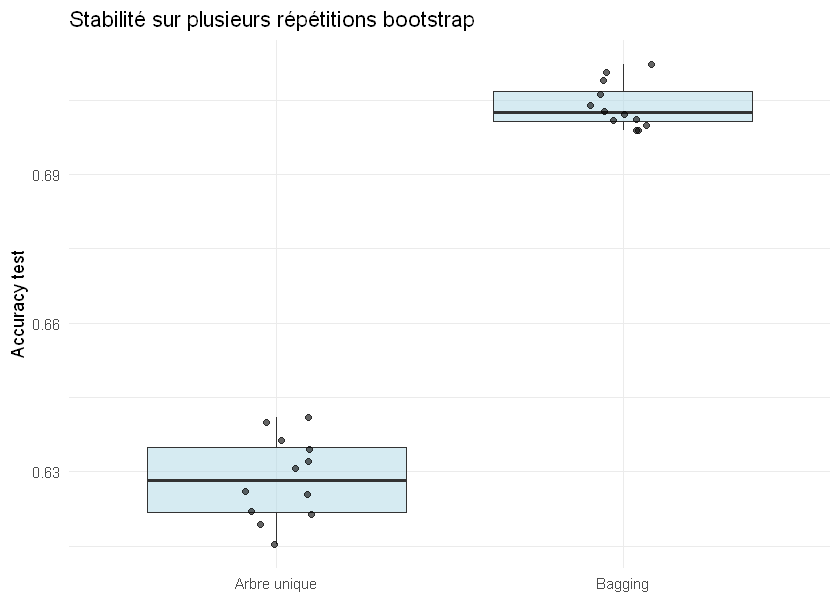

In [46]:
# Étude de stabilité : sur 12 échantillons bootstrap, comparer un arbre unique vs un bagging
stab_rows <- list()
for (seed in 0:11) {
  set.seed(seed)
  boot_idx <- sample(seq_len(nrow(df_train_tree)), replace = TRUE)
  df_boot  <- df_train_tree[boot_idx, , drop = FALSE]

  tree_boot <- rpart(Y ~ ., data = df_boot, method = "class",
                     control = rpart.control(cp = 0, minbucket = 1, xval = 0))
  acc_tree  <- mean(predict(tree_boot, newdata = Xr_test, type = "class") == Y_test_AVC)
  stab_rows[[length(stab_rows) + 1]] <- data.frame(
    Modele = "Arbre unique", `Accuracy test` = acc_tree, check.names = FALSE)

  set.seed(seed)
  bag_boot <- ipred::bagging(Y ~ ., data = df_boot, nbagg = 80, coob = FALSE,
                             control = rpart.control(cp = 0, minbucket = 1, xval = 0))
  acc_bag  <- mean(predict(bag_boot, newdata = Xr_test, type = "class") == Y_test_AVC)
  stab_rows[[length(stab_rows) + 1]] <- data.frame(
    Modele = "Bagging", `Accuracy test` = acc_bag, check.names = FALSE)
}
stab_df <- do.call(rbind, stab_rows)

cat("Moyennes et écart-types par modèle :\n")
print(aggregate(`Accuracy test` ~ Modele, data = stab_df,
                function(x) c(mean = round(mean(x), 4), sd = round(sd(x), 4))))

options(repr.plot.width = 7, repr.plot.height = 5)
ggplot(stab_df, aes(x = Modele, y = `Accuracy test`)) +
  geom_boxplot(fill = "lightblue", alpha = 0.5) +
  geom_jitter(width = 0.1, alpha = 0.6) +
  labs(title = "Stabilité sur plusieurs répétitions bootstrap",
       y = "Accuracy test", x = NULL) +
  theme_minimal()


Sur 12 répétitions bootstrap, un arbre unique obtient une accuracy moyenne de 0.629 avec un écart-type de 0.0084, tandis que le bagging à 80 arbres atteint 0.704 en moyenne avec un écart-type de 0.0046. La dispersion des performances est presque deux fois plus faible avec le bagging, et l'accuracy moyenne progresse d'environ 7 à 8 points. Cette observation confirme la théorie : même si chaque arbre de base est très variable, leur vote moyen est plus stable.

On paie cette amélioration par une perte d'interprétabilité : on ne dispose plus d'un seul arbre lisible, mais d'une moyenne de nombreux arbres. Ci-dessous on affiche un des arbres de la forêt.

Warning message:
"labs do not fit even at cex 0.15, there may be some overplotting"


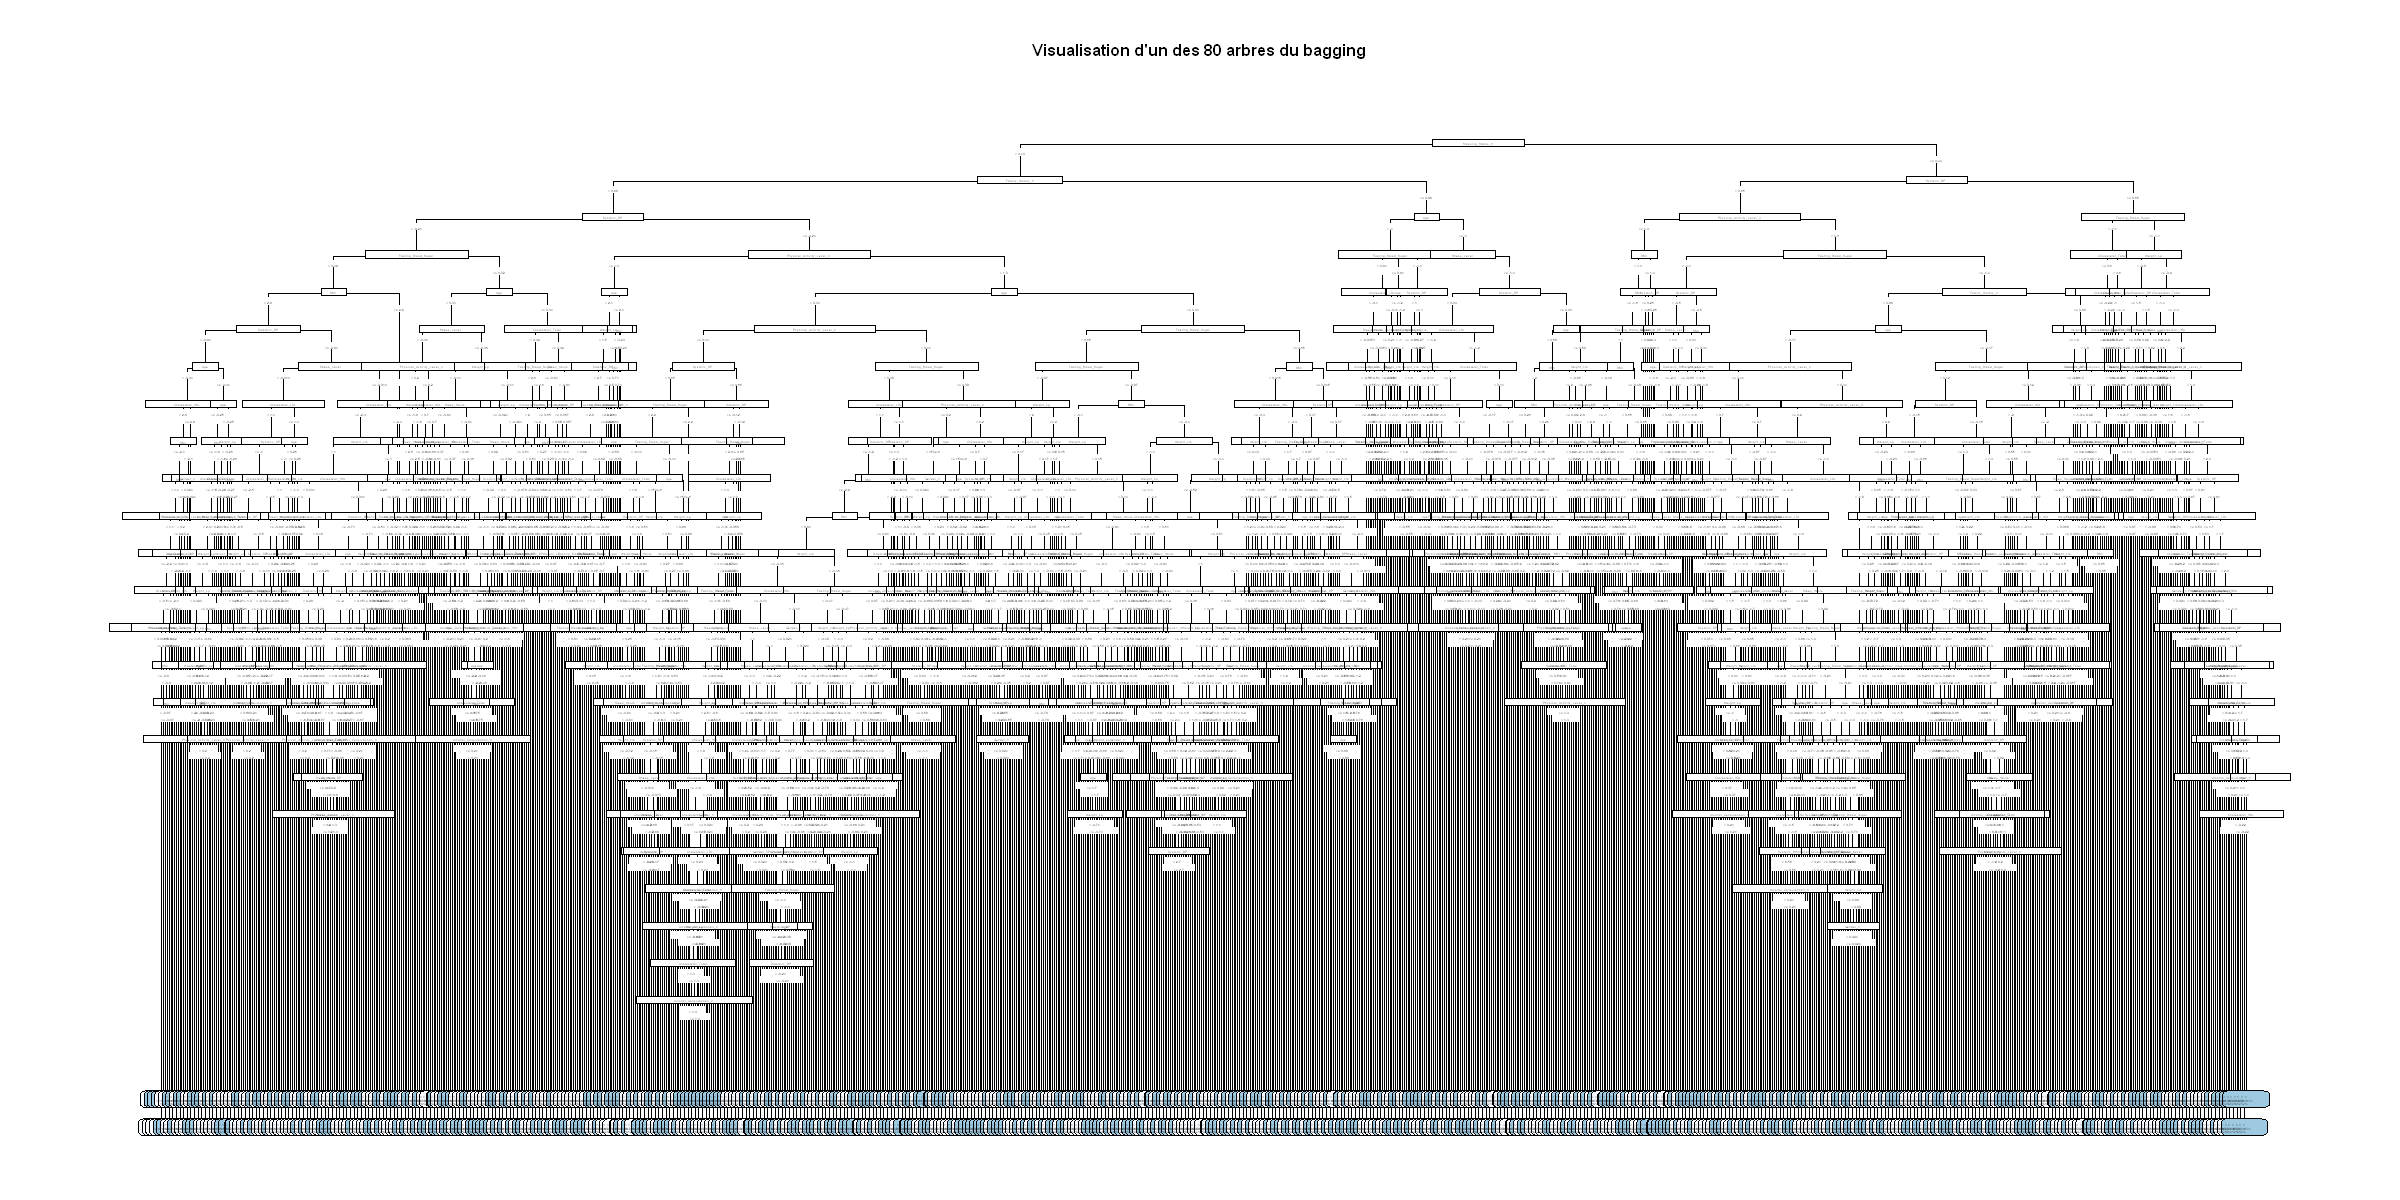

In [47]:
# Visualisation d'un arbre individuel du bagging (limité à 3 niveaux pour la lisibilité)
# On récupère le premier arbre du dernier bagging bootstrap (bag_boot du dernier seed)
un_arbre_du_bagging <- bag_boot$mtrees[[1]]$btree

options(repr.plot.width = 20, repr.plot.height = 10)
rpart.plot(un_arbre_du_bagging, type = 5, extra = 104, fallen.leaves = TRUE,
           tweak = 0.9, box.palette = "Blues",
           main = sprintf("Visualisation d'un des %d arbres du bagging", 80))


Cette visualisation illustre qu'un arbre individuel du bagging reste très variable et dépend fortement de l'échantillon bootstrap utilisé. Ses premières coupures ne sont pas exactement les mêmes que celles du CART précédent, ce qui confirme l'instabilité naturelle des arbres.

Le bagging exploite justement cette diversité en agrégeant plusieurs arbres. Cependant, les arbres peuvent encore rester assez corrélés entre eux, car ils considèrent les mêmes variables candidates à chaque coupure. La random forest prolonge cette idée en ajoutant une sélection aléatoire de variables, afin de réduire davantage la corrélation entre les arbres.

### 3.6. Random Forest

La random forest reprend le bagging mais ajoute une randomisation supplémentaire : à chaque noeud, l'algorithme ne cherche pas la meilleure coupure parmi toutes les variables, mais parmi un sous-ensemble aléatoire de variables.

Cela permet de diminuer la corrélation entre arbres. Chaque arbre est un peu moins optimal pris isolément, mais l'ensemble devient plus efficace grâce à une réduction de variance plus forte.

On étudie ici deux hyperparamètres simples :
- `ntree` : nombre d'arbres
- `mtry` : nombre de variables candidates à chaque noeud (par défaut $\sqrt{p}$ en classification).

L'erreur out-of-bag (OOB), calculée automatiquement par l'algorithme à partir des observations non sélectionnées dans chaque arbre, fournit une estimation de la performance de généralisation sans validation croisée externe.

In [48]:
# Recherche du meilleur mtry par erreur OOB (ntree fixé à 150 pour la rapidité)
mtry_grid <- c(3, 4, 5, 7, 10)
rf_grid_rows <- list()
for (mt in mtry_grid) {
  set.seed(42)
  rf_tmp <- randomForest(x = Xr_train, y = Y_train_AVC,
                          ntree = 150, mtry = mt, importance = FALSE)
  oob_err <- rf_tmp$err.rate[150, "OOB"]
  rf_grid_rows[[length(rf_grid_rows) + 1]] <- data.frame(mtry = mt, oob_err = oob_err)
}
rf_grid_df <- do.call(rbind, rf_grid_rows)
best_mtry  <- rf_grid_df$mtry[which.min(rf_grid_df$oob_err)]

cat("Erreur OOB selon mtry :\n")
print(rf_grid_df)
cat(sprintf("\nMeilleur mtry : %d (OOB err = %.4f)\n", best_mtry, min(rf_grid_df$oob_err)))


Erreur OOB selon mtry :
     mtry   oob_err
OOB     3 0.2802500
OOB1    4 0.2728333
OOB2    5 0.2757500
OOB3    7 0.2780833
OOB4   10 0.2795000

Meilleur mtry : 4 (OOB err = 0.2728)


La validation par OOB retient une random forest avec `mtry = 4`, proche de la valeur par défaut $\sqrt{p} \approx 4.5$ en classification. L'erreur OOB minimale est de 0.2728, soit une accuracy OOB d'environ 0.727. Les valeurs voisines (`mtry = 5` ou `mtry = 3`) donnent des erreurs très proches : le choix précis de `mtry` n'est pas critique sur ces données. La random forest semble mieux exploiter l'agrégation que le bagging, probablement grâce à la réduction de corrélation entre arbres apportée par le tirage aléatoire des variables candidates.

In [49]:
# Courbe d'erreur OOB et test selon ntree (mtry fixé)
rf_curve_rows <- list()
for (nt in c(50, 100, 200, 400)) {
  set.seed(42)
  rf_tmp <- randomForest(x = Xr_train, y = Y_train_AVC,
                          ntree = nt, mtry = best_mtry,
                          xtest = Xr_test, ytest = Y_test_AVC,
                          importance = FALSE, keep.forest = FALSE)
  oob_err  <- rf_tmp$err.rate[nt, "OOB"]
  test_err <- rf_tmp$test$err.rate[nt, "Test"]
  rf_curve_rows[[length(rf_curve_rows) + 1]] <- data.frame(
    ntree = nt, oob_err = oob_err, test_err = test_err)
}
rf_curve_df <- do.call(rbind, rf_curve_rows)
print(rf_curve_df)


     ntree   oob_err  test_err
OOB     50 0.2881667 0.2890000
OOB1   100 0.2799167 0.2826667
OOB2   200 0.2775833 0.2783333
OOB3   400 0.2748333 0.2830000


L'erreur OOB et l'erreur test diminuent lorsque l'on passe de 50 à 100 arbres, puis se stabilisent ensuite. Ajouter davantage d'arbres n'améliore quasiment plus les performances et l'erreur test plafonne autour de 0.278 à 0.283. On observe donc un plateau à partir de 100 à 200 arbres. Le choix d'une forêt de 300 arbres est raisonnable : il stabilise les prédictions sans augmenter excessivement le coût de calcul.

In [50]:
# Refit final avec ntree = 300 et importance des variables
set.seed(42)
t0 <- Sys.time()
rf_model <- randomForest(x = Xr_train, y = Y_train_AVC,
                          ntree = 300, mtry = best_mtry,
                          importance = TRUE, keep.forest = TRUE)
rf_time <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

oob_score <- 1 - rf_model$err.rate[300, "OOB"]
y_pred_rf <- predict(rf_model, newdata = Xr_test)
acc_train_rf <- mean(predict(rf_model, newdata = Xr_train) == Y_train_AVC)
acc_test_rf  <- mean(y_pred_rf == Y_test_AVC)

cat(sprintf("Temps fit       : %.2f s\n", rf_time))
cat(sprintf("Score OOB       : %.4f\n", oob_score))
cat(sprintf("Accuracy train  : %.4f\n", acc_train_rf))
cat(sprintf("Accuracy test   : %.4f\n", acc_test_rf))

store_tree_result("Random Forest", acc_train_rf, acc_test_rf, rf_time)
print(results_arbres[["Random Forest"]])


Temps fit       : 19.10 s
Score OOB       : 0.7256
Accuracy train  : 1.0000
Accuracy test   : 0.7157
         Modele Accuracy train Accuracy test Erreur test Temps entrainement (s)
1 Random Forest              1        0.7157      0.2843                 19.098


La random forest finale (`mtry = 4`, `ntree = 300`) obtient une accuracy test de 0.7157 et un score OOB de 0.7256, qui restent cohérents entre eux. L'accuracy train atteint 1.0, ce qui est attendu : chaque arbre de la forêt est construit sans contrainte de profondeur et s'ajuste donc parfaitement à son échantillon bootstrap. Ce surapprentissage individuel est en revanche neutralisé par le vote majoritaire, qui généralise correctement.

Les performances test sont proches de celles du bagging et du CART élagué. Sur ces données, la random forest n'apporte pas un gain significatif par rapport aux autres méthodes d'arbres : la frontière de décision reste assez simple, peut-être largement linéaire, ce qui limite l'intérêt de combiner plusieurs arbres complexes.


Top 10 importances (MeanDecreaseGini) :
                 var importance
    Smoking_Status_1     695.07
 Fasting_Blood_Sugar     477.35
         Systolic_BP     448.17
                 Age     429.34
                 BMI     428.51
           Weight_kg     423.62
           Height_cm     408.39
     Cholesterol_LDL     404.61
   Cholesterol_Total     401.22
        Diastolic_BP     367.48


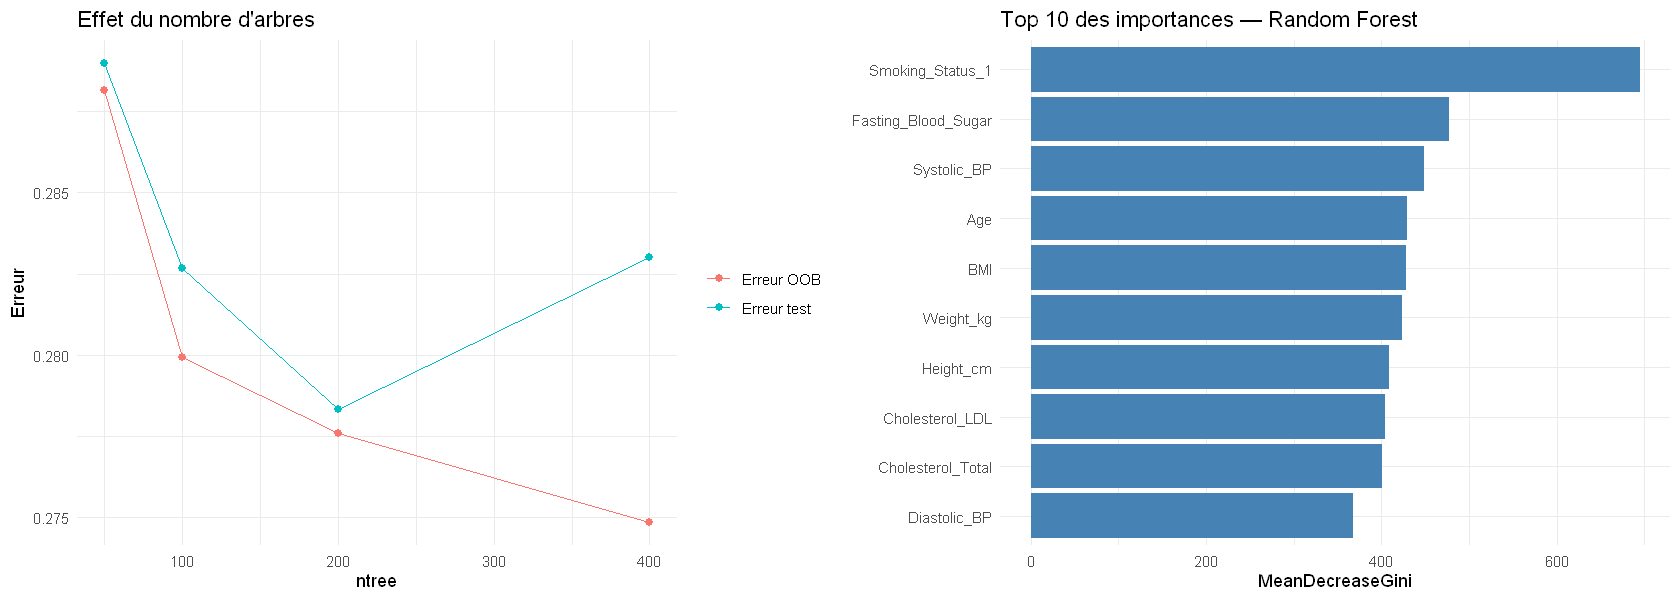

In [51]:
# Effet du nombre d'arbres + importances des variables
p_ntree <- ggplot(
  rbind(data.frame(ntree = rf_curve_df$ntree, err = rf_curve_df$oob_err, type = "Erreur OOB"),
        data.frame(ntree = rf_curve_df$ntree, err = rf_curve_df$test_err, type = "Erreur test")),
  aes(x = ntree, y = err, color = type)) +
  geom_line() + geom_point(size = 2) +
  labs(x = "ntree", y = "Erreur", color = NULL,
       title = "Effet du nombre d'arbres") +
  theme_minimal()

imp <- importance(rf_model, type = 2)  # MeanDecreaseGini
imp_df <- data.frame(var = rownames(imp), importance = imp[, "MeanDecreaseGini"])
imp_df <- imp_df[order(-imp_df$importance), ]
imp_top10 <- head(imp_df, 10)
imp_top10$var <- factor(imp_top10$var, levels = rev(imp_top10$var))

p_imp <- ggplot(imp_top10, aes(x = var, y = importance)) +
  geom_col(fill = "steelblue") + coord_flip() +
  labs(x = NULL, y = "MeanDecreaseGini",
       title = "Top 10 des importances — Random Forest") +
  theme_minimal()

options(repr.plot.width = 14, repr.plot.height = 5)
grid.arrange(p_ntree, p_imp, ncol = 2)

cat("\nTop 10 importances (MeanDecreaseGini) :\n")
imp_print <- data.frame(var = as.character(imp_top10$var),
                        importance = round(imp_top10$importance, 2))
print(imp_print, row.names = FALSE)


Les importances calculées par MeanDecreaseGini placent le statut tabagique en tête (≈ 695), loin devant les autres variables. Suivent ensuite la glycémie à jeun (477), la pression artérielle systolique (448), l'âge (429), le BMI (428) et le poids (424). Ces variables sont cohérentes avec les facteurs de risque cardiovasculaire attendus et confirment les résultats observés sur les modèles linéaires.

Il faut toutefois rester prudent dans l'interprétation : la mesure MeanDecreaseGini a tendance à favoriser les variables continues à fort cardinal, ce qui peut expliquer pourquoi des variables binaires comme `Family_History_1` apparaissent plus bas dans ce classement alors qu'elles avaient un poids important dans la régression logistique et le CART. Une importance élevée signifie qu'une variable aide à prédire la classe, pas qu'elle cause directement le risque cardiaque.

### 3.7. Boosting

Le boosting diffère profondément du bagging. Au lieu de construire des modèles indépendants en parallèle, il construit un modèle additif séquentiel : chaque nouvel arbre cherche à corriger les erreurs du modèle précédent.

- AdaBoost augmente le poids des observations mal classées
- Gradient Boosting ajuste successivement de petits arbres sur les résidus ou, plus généralement, sur des pseudo-résidus issus du gradient de la fonction de perte.

Le boosting peut donc réduire la variance, mais aussi une partie du biais. En revanche, si on multiplie trop les itérations, on risque de surapprendre. On s'appuie donc sur deux idées simples :
- le coefficient de rétrécissement (`shrinkage`, équivalent du *learning rate*)
- l'early stopping, c'est-à-dire l'arrêt avant que l'erreur de validation ne remonte.

La fonction `gbm::gbm` fournit nativement une procédure de validation croisée interne (`cv.folds`) qui calcule l'erreur de déviance moyenne à chaque ajout d'arbre. On peut ainsi sélectionner directement le nombre d'arbres optimal sans réentraîner plusieurs modèles.

In [52]:
# gbm attend une variable cible numérique 0/1 pour les distributions adaboost et bernoulli
y_train_num <- as.numeric(as.character(Y_train_AVC))
y_test_num  <- as.numeric(as.character(Y_test_AVC))
df_gbm_train <- data.frame(Y = y_train_num, Xr_train)
df_gbm_test  <- data.frame(Y = y_test_num,  Xr_test)


In [53]:
# Grid AdaBoost : on parcourt le shrinkage, on fixe n.trees = 200 et on laisse
# la validation croisée interne sélectionner le nombre optimal d'itérations.
# interaction.depth = 1 correspond à des stumps (arbres de profondeur 1).
shrinkage_grid <- c(0.05, 0.1, 0.5, 1.0)
ada_results <- list()
for (lr in shrinkage_grid) {
  set.seed(42)
  t0 <- Sys.time()
  ada_tmp <- gbm(Y ~ ., data = df_gbm_train, distribution = "adaboost",
                 n.trees = 200, shrinkage = lr,
                 interaction.depth = 1, n.minobsinnode = 10,
                 cv.folds = 5, verbose = FALSE)
  t_ada <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
  best_iter <- which.min(ada_tmp$cv.error)
  cat(sprintf("shrinkage = %.2f : n.trees opt = %d, déviance CV min = %.4f, temps = %.1f s\n",
              lr, best_iter, ada_tmp$cv.error[best_iter], t_ada))
  ada_results[[as.character(lr)]] <- list(
    model = ada_tmp, best_iter = best_iter,
    cv_err = ada_tmp$cv.error[best_iter], lr = lr, time = t_ada
  )
}

# Sélection du meilleur shrinkage par déviance CV minimale
best_lr_ada <- names(ada_results)[which.min(sapply(ada_results, function(x) x$cv_err))]
ada_best    <- ada_results[[best_lr_ada]]
cat(sprintf("\nMeilleurs paramètres AdaBoost : shrinkage = %s, n.trees = %d\n",
            best_lr_ada, ada_best$best_iter))

# Évaluation sur train et test
p_train_ada <- predict(ada_best$model, newdata = df_gbm_train,
                       n.trees = ada_best$best_iter, type = "response")
p_ada       <- predict(ada_best$model, newdata = df_gbm_test,
                       n.trees = ada_best$best_iter, type = "response")
y_pred_ada  <- as.integer(p_ada > 0.5)
acc_train_ada <- mean(as.integer(p_train_ada > 0.5) == y_train_num)
acc_test_ada  <- mean(y_pred_ada == y_test_num)

cat(sprintf("Accuracy train : %.4f\n", acc_train_ada))
cat(sprintf("Accuracy test  : %.4f\n", acc_test_ada))

ada_total_time <- sum(sapply(ada_results, function(x) x$time))
store_tree_result("AdaBoost", acc_train_ada, acc_test_ada, ada_total_time)
print(results_arbres[["AdaBoost"]])


shrinkage = 0.05 : n.trees opt = 200, déviance CV min = 0.8464, temps = 8.1 s
shrinkage = 0.10 : n.trees opt = 200, déviance CV min = 0.8300, temps = 7.6 s
shrinkage = 0.50 : n.trees opt = 65, déviance CV min = 0.8271, temps = 9.6 s
shrinkage = 1.00 : n.trees opt = 32, déviance CV min = 0.8364, temps = 8.2 s

Meilleurs paramètres AdaBoost : shrinkage = 0.5, n.trees = 65
Accuracy train : 0.7376
Accuracy test  : 0.7253
    Modele Accuracy train Accuracy test Erreur test Temps entrainement (s)
1 AdaBoost         0.7376        0.7253      0.2747                 33.493


AdaBoost retient un `shrinkage` de 0.5 avec 65 itérations sélectionnées par l'early stopping de la validation croisée interne. Il obtient une accuracy test de 0.7253, supérieure au CART élagué, au bagging et à la random forest. L'écart entre accuracy train (0.7376) et accuracy test (0.7253) est faible, ce qui indique une bonne généralisation.

On teste ensuite le Gradient Boosting, qui construit aussi un modèle additif séquentiel, mais en corrigeant directement les erreurs résiduelles à chaque étape. La grille parcourt deux valeurs du `shrinkage` et trois valeurs d'`interaction.depth` (profondeur des arbres de base). Pour chaque combinaison, la validation croisée interne identifie le nombre d'arbres optimal.

In [54]:
# Grid Gradient Boosting (distribution bernoulli pour classification binaire)
gb_grid <- expand.grid(shrinkage = c(0.05, 0.1), interaction.depth = c(1, 2, 3))
n.trees_max <- 200
gb_results <- list()
for (i in seq_len(nrow(gb_grid))) {
  lr    <- gb_grid$shrinkage[i]
  depth <- gb_grid$interaction.depth[i]
  set.seed(42)
  t0 <- Sys.time()
  gb_tmp <- gbm(Y ~ ., data = df_gbm_train, distribution = "bernoulli",
                n.trees = n.trees_max, shrinkage = lr,
                interaction.depth = depth, n.minobsinnode = 10,
                cv.folds = 3, verbose = FALSE)
  t_gb <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
  best_iter <- which.min(gb_tmp$cv.error)

  p_test  <- predict(gb_tmp, newdata = df_gbm_test, n.trees = best_iter, type = "response")
  acc_test <- mean(as.integer(p_test > 0.5) == y_test_num)

  cat(sprintf("shrinkage = %.2f, depth = %d : n.trees opt = %d, déviance CV min = %.4f, acc test = %.4f, temps = %.1f s\n",
              lr, depth, best_iter, gb_tmp$cv.error[best_iter], acc_test, t_gb))
  gb_results[[paste0("lr=", lr, "_d=", depth)]] <- list(
    model = gb_tmp, best_iter = best_iter,
    cv_err = gb_tmp$cv.error[best_iter], acc_test = acc_test,
    lr = lr, depth = depth, time = t_gb
  )
}

# Sélection du meilleur par déviance CV minimale
best_gb_key <- names(gb_results)[which.min(sapply(gb_results, function(x) x$cv_err))]
gb_best     <- gb_results[[best_gb_key]]
cat(sprintf("\nMeilleurs paramètres GB : shrinkage = %.2f, depth = %d, n.trees = %d\n",
            gb_best$lr, gb_best$depth, gb_best$best_iter))

# Refit / scores du meilleur GB
p_train_gb <- predict(gb_best$model, newdata = df_gbm_train,
                      n.trees = gb_best$best_iter, type = "response")
p_gb       <- predict(gb_best$model, newdata = df_gbm_test,
                      n.trees = gb_best$best_iter, type = "response")
y_pred_gb  <- as.integer(p_gb > 0.5)
acc_train_gb <- mean(as.integer(p_train_gb > 0.5) == y_train_num)
acc_test_gb  <- mean(y_pred_gb == y_test_num)

cat(sprintf("Accuracy train : %.4f\n", acc_train_gb))
cat(sprintf("Accuracy test  : %.4f\n", acc_test_gb))

gb_total_time <- sum(sapply(gb_results, function(x) x$time))
store_tree_result("Gradient Boosting", acc_train_gb, acc_test_gb, gb_total_time)
print(results_arbres[["Gradient Boosting"]])


shrinkage = 0.05, depth = 1 : n.trees opt = 200, déviance CV min = 1.1001, acc test = 0.7273, temps = 9.5 s
shrinkage = 0.10, depth = 1 : n.trees opt = 200, déviance CV min = 1.0720, acc test = 0.7243, temps = 7.7 s
shrinkage = 0.05, depth = 2 : n.trees opt = 200, déviance CV min = 1.0755, acc test = 0.7227, temps = 11.0 s
shrinkage = 0.10, depth = 2 : n.trees opt = 187, déviance CV min = 1.0669, acc test = 0.7250, temps = 10.3 s
shrinkage = 0.05, depth = 3 : n.trees opt = 200, déviance CV min = 1.0697, acc test = 0.7220, temps = 11.5 s
shrinkage = 0.10, depth = 3 : n.trees opt = 144, déviance CV min = 1.0678, acc test = 0.7207, temps = 9.5 s

Meilleurs paramètres GB : shrinkage = 0.10, depth = 2, n.trees = 187
Accuracy train : 0.7451
Accuracy test  : 0.7250
             Modele Accuracy train Accuracy test Erreur test
1 Gradient Boosting         0.7451         0.725       0.275
  Temps entrainement (s)
1                 59.573


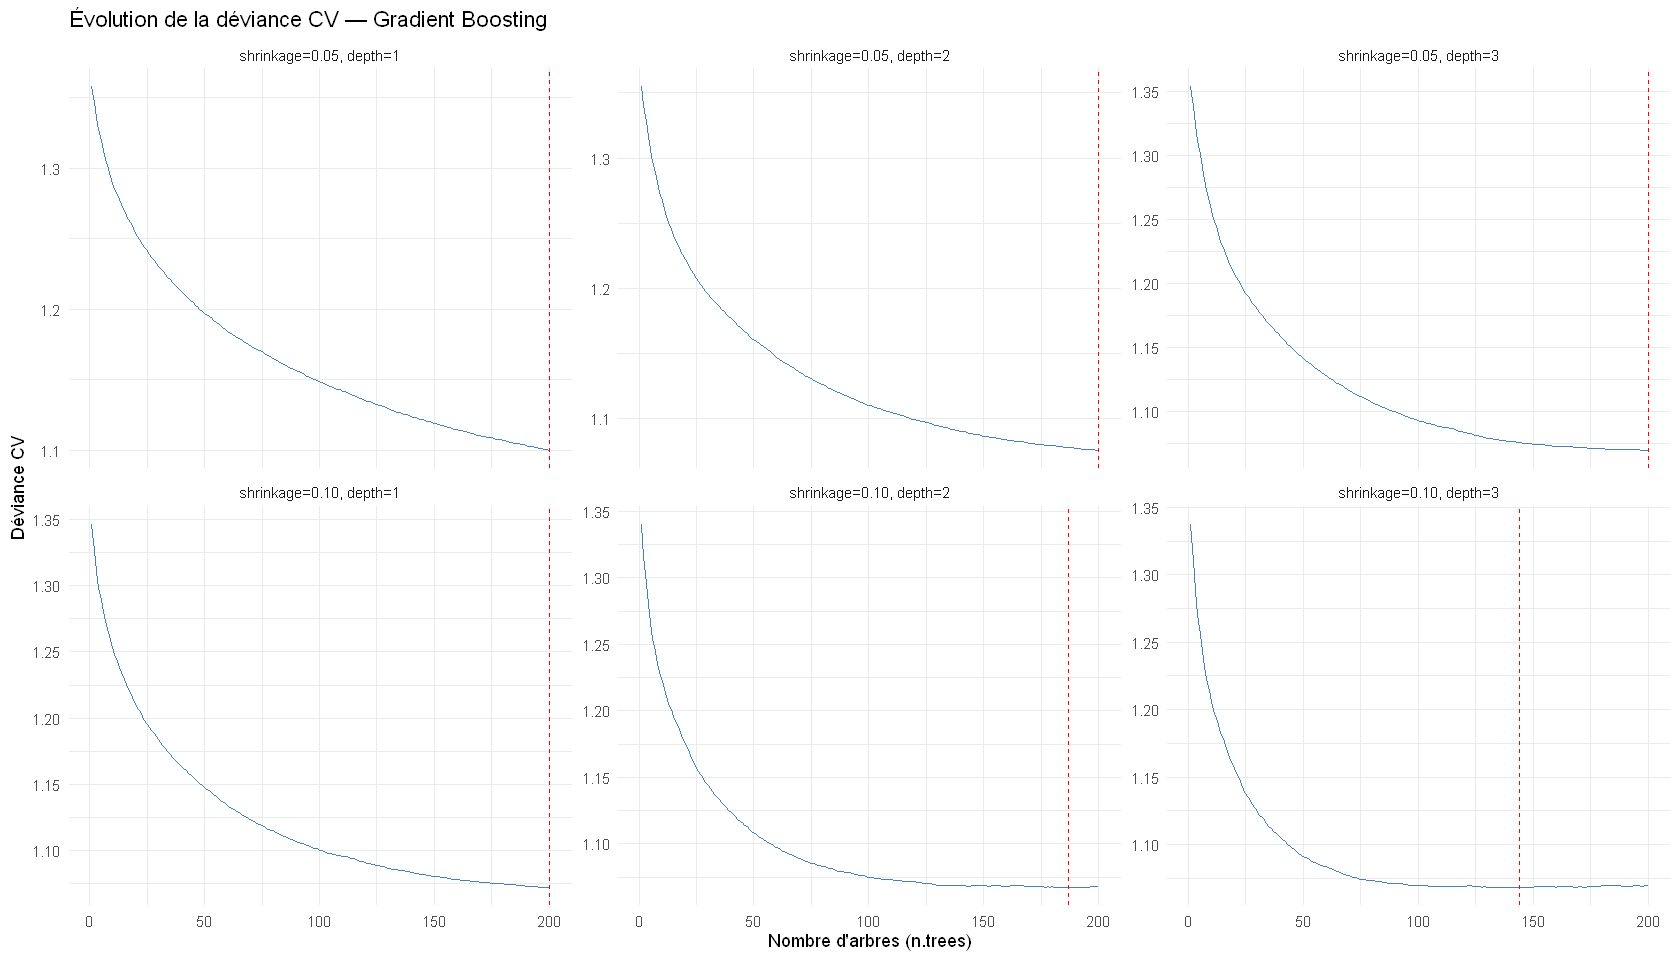

In [55]:
# Courbes de déviance CV en fonction du nombre d'arbres pour les 6 configurations
gb_curves <- list()
for (key in names(gb_results)) {
  info <- gb_results[[key]]
  gb_curves[[length(gb_curves) + 1]] <- data.frame(
    n_trees   = seq_along(info$model$cv.error),
    cv_error  = info$model$cv.error,
    config    = sprintf("shrinkage=%.2f, depth=%d", info$lr, info$depth),
    best_iter = info$best_iter
  )
}
gb_curves_df <- do.call(rbind, gb_curves)

options(repr.plot.width = 14, repr.plot.height = 8)
ggplot(gb_curves_df, aes(x = n_trees, y = cv_error)) +
  geom_line(color = "steelblue") +
  geom_vline(aes(xintercept = best_iter), linetype = "dashed", color = "red") +
  facet_wrap(~ config, nrow = 2, scales = "free_y") +
  labs(x = "Nombre d'arbres (n.trees)", y = "Déviance CV",
       title = "Évolution de la déviance CV — Gradient Boosting") +
  theme_minimal()


#### Note sur le choix de procédure

Pour chaque configuration de Gradient Boosting, on entraîne un seul modèle avec un nombre maximal d'arbres et on utilise la validation croisée interne (`cv.folds = 3`) pour observer la déviance de validation à chaque itération. La valeur de `n.trees` retenue est celle qui minimise cette déviance moyenne. Cette approche évite de réentraîner le modèle pour chaque valeur de `n.trees` testée et constitue une forme d'early stopping intégrée.

La meilleure configuration retenue est `shrinkage = 0.10`, `interaction.depth = 2`, `n.trees = 187`, avec une déviance CV minimale de 1.067. Sur le test, le modèle atteint une accuracy de 0.7250, soit une erreur de 0.275.

L'early stopping intégré à `gbm` adapte le nombre d'itérations à la vitesse de convergence : avec `shrinkage = 0.05`, l'apprentissage est plus lent et atteint la borne supérieure (`n.trees = 200`) sans avoir convergé pour toutes les profondeurs testées ; avec `shrinkage = 0.10`, la convergence est plus rapide et l'optimum se situe entre 144 et 200 itérations selon la profondeur. Les profondeurs 2 et 3 donnent des résultats proches, mais la profondeur 2 est retenue car elle minimise la déviance CV moyenne.

Le Gradient Boosting donne donc de bons résultats, comparables à AdaBoost, mais il demande un réglage précis du shrinkage, du nombre d'itérations et de la profondeur des arbres.

### 3.8. Comparaison globale des modèles d'arbres

On rassemble maintenant les principaux résultats pour comparer les approches sous plusieurs angles : qualité d'ajustement, généralisation, temps d'entraînement, interprétabilité et stabilité.

In [56]:
# Tableau récapitulatif des modèles à base d'arbres, trié par accuracy test décroissante
comparison_df <- do.call(rbind, results_arbres)
comparison_df <- comparison_df[order(-comparison_df$`Accuracy test`), ]
print(comparison_df, row.names = FALSE)


            Modele Accuracy train Accuracy test Erreur test
          AdaBoost         0.7376        0.7253      0.2747
 Gradient Boosting         0.7451        0.7250      0.2750
       CART élagué         0.7551        0.7160      0.2840
           Bagging         1.0000        0.7160      0.2840
     Random Forest         1.0000        0.7157      0.2843
              CART         0.7239        0.7037      0.2963
 Temps entrainement (s)
                 33.493
                 59.573
                  1.369
                 43.656
                 19.098
                  0.064


Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


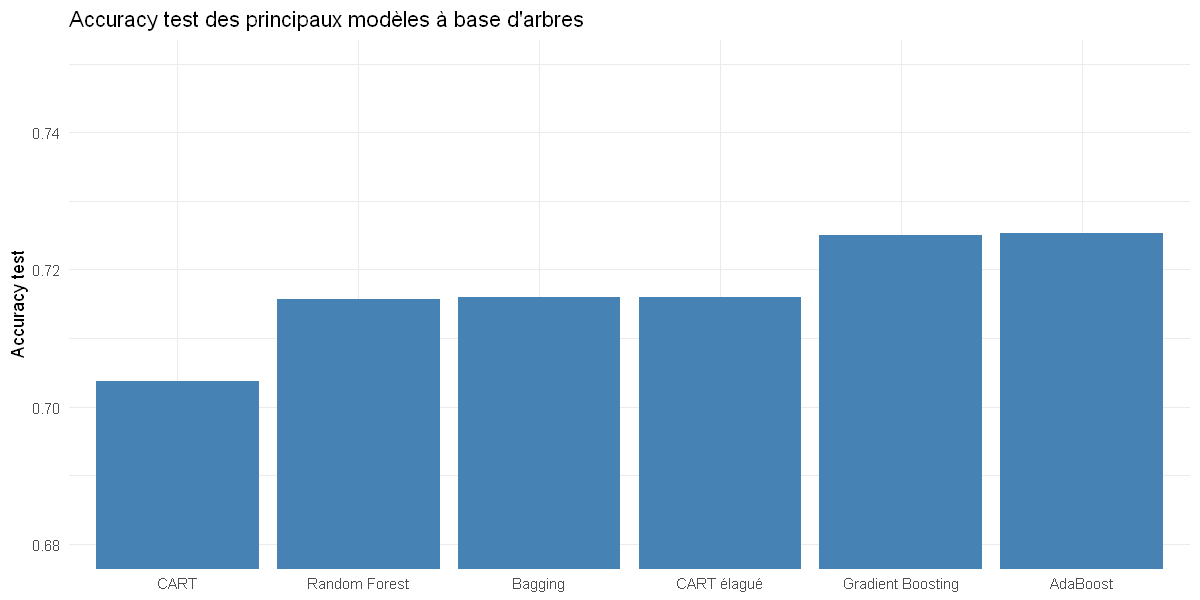

In [57]:
# Barplot des accuracies test
comparison_df_plot <- comparison_df
comparison_df_plot$Modele <- factor(comparison_df_plot$Modele,
                                    levels = rev(comparison_df_plot$Modele))

options(repr.plot.width = 10, repr.plot.height = 5)
ggplot(comparison_df_plot, aes(x = Modele, y = `Accuracy test`)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  coord_cartesian(ylim = c(0.68, 0.75)) +
  labs(x = NULL, y = "Accuracy test",
       title = "Accuracy test des principaux modèles à base d'arbres") +
  theme_minimal()


Quelques tendances fortes se dégagent :
- le CART est le plus lisible, mais aussi le plus sensible à la complexité et à la variance
- le pruning améliore le compromis complexité / généralisation sans changer la philosophie du modèle
- le bagging stabilise nettement les performances en agrégeant des arbres instables appris sur des échantillons bootstrap
- la random forest va plus loin en décorrélant les arbres grâce à la randomisation des variables
- le boosting est conceptuellement différent : il ne moyenne pas seulement des modèles, il les construit de façon séquentielle pour corriger les erreurs passées.

On retrouve que les méthodes d'ensemble améliorent la qualité prédictive des arbres, mais au prix d'une perte d'interprétabilité globale.

## 4. Réseaux de neurones

Les réseaux de neurones constituent un dernier modèle non linéaire pour la classification.

On utilise ici un MLP simple, avec une seule couche cachée. L'objectif n'est pas de construire un modèle très profond, mais de comparer un réseau de neurones aux modèles précédents. Les données étant standardisées, elles sont adaptées à ce type de modèle.

Le réseau testé a deux hyperparamètres principaux :
- `size` : nombre de neurones de la couche cachée
- `decay` : coefficient de régularisation L2 sur les poids du réseau.

On parcourt une grille `size` ∈ {5, 10} et `decay` ∈ {0.001, 0.01} par validation croisée à 10 plis en maximisant l'accuracy.

In [58]:
# Grid search MLP avec validation croisée 10-fold
set.seed(11)
mlp_grid <- expand.grid(size = c(5, 10), decay = c(0.001, 0.01))
ctrl_mlp <- trainControl(method = "cv", number = 10)

t0 <- Sys.time()
mlp_fit <- train(x = Xr_train, y = Y_train_AVC_named,
                 method = "nnet",
                 trControl = ctrl_mlp,
                 tuneGrid = mlp_grid,
                 trace = FALSE, maxit = 500,
                 metric = "Accuracy")
t_mlp <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

cat(sprintf("Temps MLP : %.1f s\n", t_mlp))
cat(sprintf("Meilleurs paramètres : size = %d, decay = %g\n",
            mlp_fit$bestTune$size, mlp_fit$bestTune$decay))
cat(sprintf("Accuracy CV maximale : %.4f\n", max(mlp_fit$results$Accuracy)))
cat("\nGrille complète :\n")
print(mlp_fit$results[, c("size", "decay", "Accuracy", "AccuracySD")])


Temps MLP : 375.4 s
Meilleurs paramètres : size = 5, decay = 0.01
Accuracy CV maximale : 0.7333

Grille complète :
  size decay  Accuracy AccuracySD
1    5 0.001 0.7330874 0.01283732
2    5 0.010 0.7332525 0.01386886
3   10 0.001 0.7226709 0.01414847
4   10 0.010 0.7238372 0.01553941


La validation croisée retient un réseau très simple : une seule couche cachée de 5 neurones et une pénalisation `decay = 0.01`. Le score moyen en validation croisée atteint 0.7333, ce qui est légèrement supérieur aux modèles d'arbres et aux méthodes d'ensemble précédentes.

L'écart entre les configurations à 5 et 10 neurones est notable (0.733 vs 0.723) : un réseau plus large semble sur-paramétré pour la quantité d'information utile dans les variables explicatives.

On évalue maintenant ce modèle sur l'échantillon test afin de vérifier si cette bonne performance en validation se retrouve sur des données non utilisées pendant l'apprentissage.

In [1]:
# Prédiction sur l'échantillon test
y_pred_mlp <- predict(mlp_fit, newdata = Xr_test)
p_mlp      <- predict(mlp_fit, newdata = Xr_test, type = "prob")[, "high"]

acc_mlp <- mean(y_pred_mlp == Y_test_AVC_named)
cat("Matrice de confusion :\n")
print(table(predit = y_pred_mlp, reel = Y_test_AVC_named))

cat(sprintf("\nTaux d'erreur sur le test : %.4f\n", 1 - acc_mlp))

roc_mlp <- roc(Y_test_AVC_named, p_mlp, levels = c("low", "high"),
               direction = "<", quiet = TRUE)
auc_mlp <- as.numeric(auc(roc_mlp))
cat(sprintf("AUC test                  : %.4f\n", auc_mlp))


ERROR: Error: objet 'mlp_fit' introuvable



Sur l'échantillon test, le modèle obtient un taux d'erreur de 0.2793, soit environ 27.9 % de mauvaises classifications, et une AUC de 0.7894. La matrice de confusion montre qu'il classe correctement 1333 individus sans risque cardiaque et 829 individus à risque. En revanche, il produit encore 478 faux négatifs et 360 faux positifs.

Ainsi, le réseau de neurones donne des résultats satisfaisants, proches des meilleures méthodes testées. Son principal inconvénient reste son manque d'interprétabilité : contrairement à une régression logistique ou à un arbre de décision, il est plus difficile d'expliquer directement l'effet de chaque variable sur la prédiction finale.

## 5. Comparaison des modèles obtenus et conclusion

On termine la partie classification en comparant les modèles sur une même courbe ROC. Cette représentation permet d'évaluer leur capacité à discriminer les individus à risque et sans risque indépendamment d'un seuil de décision particulier.

L'objectif est de vérifier si les modèles les plus performants en accuracy sont aussi ceux qui ordonnent le mieux les observations selon leur niveau de risque estimé.

In [ ]:
# Récupération des probabilités prédites sur le test pour les modèles non encore extraits
# (Les probabilités des modèles linéaires, RFE-logit, kNN, SVM, AdaBoost et GB ont été calculées
#  dans les sections précédentes et persistent dans la session.)
p_cart    <- predict(cart_model,   newdata = Xr_test, type = "prob")[, "1"]
p_pruned  <- predict(pruned_tree,  newdata = Xr_test, type = "prob")[, "1"]
p_bagging <- predict(bag_best,     newdata = Xr_test, type = "prob")[, "1"]
p_rf      <- predict(rf_model,     newdata = Xr_test, type = "prob")[, "1"]

cat("Probabilités test extraites pour les modèles d'arbres.\n")


AUC test triée par ordre décroissant :


             Modele    AUC
         ElasticNet 0.7956
              LASSO 0.7956
              Ridge 0.7954
  Gradient Boosting 0.7924
          Logit RFE 0.7911
 Réseau de neurones 0.7894
           AdaBoost 0.7885
                KNN 0.7875
      Random Forest 0.7748
            Bagging 0.7732
                SVM 0.7718
        CART élagué 0.7449
               CART 0.7421


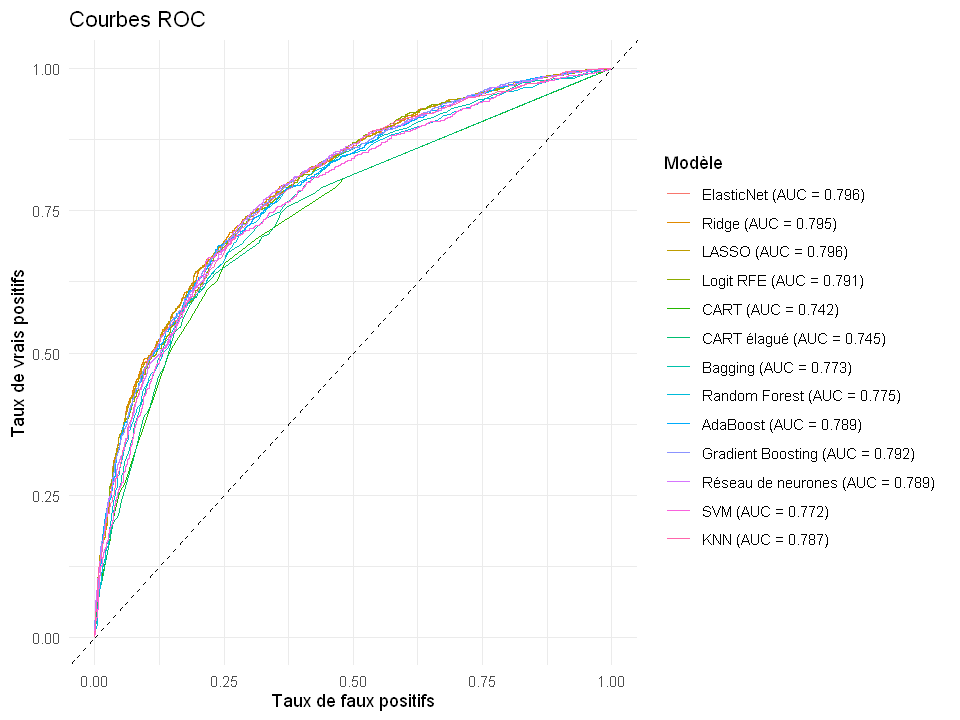

In [ ]:
# Construction d'une liste nommée des probabilités test pour chaque modèle
modeles_p <- list(
  ElasticNet           = p_en,
  Ridge                = p_ridge,
  LASSO                = p_lasso,
  `Logit RFE`          = p_sel,
  CART                 = p_cart,
  `CART élagué`        = p_pruned,
  Bagging              = p_bagging,
  `Random Forest`      = p_rf,
  AdaBoost             = p_ada,
  `Gradient Boosting`  = p_gb,
  `Réseau de neurones` = p_mlp,
  SVM                  = p_svm,
  KNN                  = p_knn
)

# Tableau des AUCs triées
aucs <- sapply(modeles_p, function(p) {
  r <- roc(Y_test_AVC, p, levels = c("0", "1"), direction = "<", quiet = TRUE)
  as.numeric(auc(r))
})
aucs_df <- data.frame(Modele = names(aucs), AUC = round(aucs, 4))
aucs_df <- aucs_df[order(-aucs_df$AUC), ]
cat("AUC test triée par ordre décroissant :
")
print(aucs_df, row.names = FALSE)

# Comparaison ROC des 13 modèles
comparer_ROC(modeles_p)


Les courbes ROC des différents modèles sont très proches les unes des autres. L'écart total d'AUC reste modéré, avec des valeurs allant de 0.742 pour le CART à 0.796 pour les modèles linéaires pénalisés, soit un écart maximal de 0.054.

Les meilleures performances sont obtenues par les modèles linéaires pénalisés : ElasticNet, LASSO et Ridge atteignent tous une AUC autour de 0.796. Un groupe de modèles présente ensuite des performances très proches : le Gradient Boosting à 0.792, la régression logistique avec sélection RFE à 0.791, le réseau de neurones à 0.789, AdaBoost à 0.789 et KNN à 0.788. Random Forest (0.775), Bagging (0.773) et SVM (0.772) sont un cran en dessous, et les arbres seuls (CART à 0.742, CART élagué à 0.745) sont nettement en retrait.

Aucun modèle ne domine nettement les autres sur le plan prédictif. La performance ne suffit donc pas à départager les modèles, et le choix final doit aussi tenir compte de l'interprétabilité. Dans ce contexte, le modèle de régression logistique obtenu par sélection RFE constitue le meilleur compromis : son AUC est très proche de celle des modèles linéaires pénalisés (0.791 vs 0.796), tout en utilisant seulement 10 variables au lieu de 20. À l'inverse, le CART seul est plus facile à visualiser, mais son AUC plus faible en fait un moins bon compromis.

### Lien avec l'analyse exploratoire

Les résultats de modélisation confirment en grande partie les conclusions de l'analyse exploratoire. Le risque cardiaque reste un phénomène multifactoriel : les modèles les plus performants combinent plusieurs variables et aucun modèle non linéaire ne domine nettement les modèles linéaires. Les coefficients LASSO et Ridge placent bien le tabagisme parmi les variables les plus influentes, avec des coefficients autour de +0.91, puis les antécédents familiaux autour de +0.54. Les modalités liées au niveau d'activité physique ont des coefficients négatifs marqués, entre -0.27 et -0.47, ce qui confirme l'effet protecteur observé dans les graphiques exploratoires.

La sélection RFE va dans le même sens : elle conserve le tabagisme, les trois modalités du niveau d'activité physique, les antécédents familiaux, ainsi que des variables quantitatives comme l'âge, la pression artérielle systolique, le cholestérol LDL, la glycémie à jeun et le niveau de stress. Elle élimine notamment la taille, le cholestérol HDL, le cholestérol total, le poids, l'IMC et la pression artérielle diastolique, déjà identifiés comme peu discriminants dans l'analyse exploratoire. Les importances de la Random Forest confirment aussi le rôle central du tabagisme (importance MeanDecreaseGini de 695, loin devant les autres variables), puis la glycémie à jeun, la pression artérielle systolique, l'âge et l'IMC.

Certaines conclusions sont donc confirmées : le tabagisme, les antécédents familiaux, l'activité physique, l'âge et la pression artérielle jouent un rôle important, tandis que la taille et le cholestérol HDL restent peu utiles pour la prédiction. En revanche, le niveau de stress est plus ambigu : il semblait peu discriminant dans l'analyse exploratoire, mais il reçoit un coefficient positif non négligeable dans les modèles linéaires (+0.29 dans le LASSO) et est conservé par la sélection RFE. Le nombre d'heures de sommeil, lui, n'est pas conservé par la sélection RFE et a un coefficient LASSO faible (-0.11), ce qui suggère un rôle limité dans la prédiction. Enfin, l'importance moindre des antécédents familiaux dans la Random Forest par rapport au CART ou au LASSO tient au biais connu de la mesure MeanDecreaseGini, qui favorise les variables continues à fort cardinal.

# II : Problème de régression — prédiction du LDL-cholestérol

Dans cette seconde partie, on cherche à prédire la variable quantitative `Cholesterol_LDL`, qui correspond au taux de LDL-cholestérol (aussi appelé "mauvais cholestérol") dans le sang. C'est donc un problème de régression.

L'objectif est de reprendre la même logique d'étude que pour la classification :
- modèles linéaires
- kNN / SVR
- arbre CART de régression
- étude de la complexité et élagage
- bagging
- random forest
- boosting
- réseau de neurones.

On part directement de l'étude de modélisation, en gardant à l'esprit les tendances déjà observées sur ce jeu de données, en particulier le rôle très important de `Cholesterol_Total`, puis de variables comme `Age`, `BMI`, `Systolic_BP` ou `Cholesterol_HDL`.

## 1. Cadre de l'étude

Dans cette seconde partie du projet, on cherche à prédire `Cholesterol_LDL` à partir de toutes les autres variables à l'exception de `Heart_Disease_Risk`.

Comme `Cholesterol_LDL` est une variable quantitative, les modèles sont évalués sur trois métriques complémentaires :
- la **RMSE** : indicateur principal, exprimée en mg/dL comme le LDL, donc directement comparable à la dispersion observée (écart-type du LDL ≈ 18 mg/dL)
- la **MAE** : en complément, elle pénalise les écarts linéairement et donne un écart typique moins influencé par les valeurs extrêmes
- le **$R^2$** : utile pour comparer les modèles entre eux indépendamment de l'échelle, en mesurant la part de variance du LDL expliquée.

On conserve le fil directeur :
- les arbres sont non paramétriques, flexibles, mais à forte variance
- les méthodes d'agrégation cherchent à stabiliser ou améliorer ces arbres
- les modèles linéaires et régularisés servent de points de comparaison importants
- le SVR et le réseau de neurones apportent d'autres formes de non-linéarité.

Pour les modèles coûteux (SVR, réseau de neurones), on adopte une stratégie raisonnable : une validation croisée sur un sous-échantillon d'apprentissage, puis un réentraînement final sur l'échantillon complet d'apprentissage avec les hyperparamètres retenus.

In [ ]:
# Conteneur partagé pour les résultats des modèles de régression
results_regr <- list()

# Fonction d'évaluation à partir des prédictions train / test
regression_scores <- function(pred_train, pred_test,
                              ytr = Y_train_cholest, yte = Y_test_cholest) {
  list(
    rmse_train = sqrt(mean((ytr - pred_train)^2)),
    rmse_test  = sqrt(mean((yte - pred_test)^2)),
    mae_test   = mean(abs(yte - pred_test)),
    r2_train   = 1 - sum((ytr - pred_train)^2) / sum((ytr - mean(ytr))^2),
    r2_test    = 1 - sum((yte - pred_test)^2) / sum((yte - mean(yte))^2)
  )
}

store_regr_result <- function(name, scores, fit_time, category, hyperparam = NA) {
  results_regr[[name]] <<- data.frame(
    Modele                   = name,
    Categorie                = category,
    `RMSE train`             = round(scores$rmse_train, 3),
    `RMSE test`              = round(scores$rmse_test,  3),
    `MAE test`               = round(scores$mae_test,   3),
    `R2 train`               = round(scores$r2_train,   4),
    `R2 test`                = round(scores$r2_test,    4),
    `Temps entrainement (s)` = round(fit_time,          3),
    Hyperparametre           = as.character(hyperparam),
    check.names = FALSE,
    stringsAsFactors = FALSE
  )
  invisible(NULL)
}

# Récap des dimensions et de la cible
cat(sprintf("Dimensions apprentissage : (%d, %d)\n", nrow(X_train_r), ncol(X_train_r)))
cat(sprintf("Dimensions test          : (%d, %d)\n", nrow(X_test_r),  ncol(X_test_r)))
cat(sprintf("Moyenne LDL train / test : %.2f / %.2f\n",
            mean(Y_train_cholest), mean(Y_test_cholest)))


Dimensions apprentissage : (12000, 19)


Dimensions test          : (3000, 19)


Moyenne LDL train / test : 140.37 / 140.28


## 2. Modèles linéaires

Avant d'étudier les arbres et les méthodes d'ensemble, il est utile de construire plusieurs références linéaires.

On compare ici :
- une régression linéaire complète
- une régression linéaire après sélection de variables (critères AIC et BIC)
- une régression Ridge
- une régression Lasso.

#### 2.1 : Régression linéaire complète

On commence par une régression linéaire complète, qui utilise toutes les variables explicatives disponibles. Ce modèle sert de référence simple : il permet d'évaluer si une relation linéaire suffit déjà à prédire correctement le cholestérol LDL.

In [ ]:
df_train_reg <- data.frame(Y = Y_train_cholest, X_train_r)
df_test_reg  <- data.frame(Y = Y_test_cholest,  X_test_r)

t0 <- Sys.time()
linear_full <- lm(Y ~ ., data = df_train_reg)
t_lf <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_lf <- predict(linear_full, newdata = df_train_reg)
pred_test_lf  <- predict(linear_full, newdata = df_test_reg)
sc_lf <- regression_scores(pred_train_lf, pred_test_lf)

store_regr_result("Régression linéaire complète", sc_lf, t_lf, "Linéaire", "-")
print(results_regr[["Régression linéaire complète"]])

# Top 10 coefficients par valeur absolue (hors intercept)
coef_lf <- coef(linear_full)[-1]
coef_top <- coef_lf[order(-abs(coef_lf))][1:10]
cat("\nTop 10 coefficients par |valeur| :\n")
print(round(coef_top, 4))


                        Modele Categorie RMSE train RMSE test MAE test R2 train
1 Régression linéaire complète  Linéaire      9.984    10.042    7.983   0.6904
  R2 test Temps entrainement (s) Hyperparametre
1  0.6816                  0.031              -



Top 10 coefficients par |valeur| :


        Cholesterol_Total          Family_History_1 Physical_Activity_Level_3 
                   0.6543                   -0.2612                   -0.2282 
         Smoking_Status_1               Sleep_Hours     Alcohol_Consumption_2 
                   0.1146                   -0.0956                    0.0952 
Physical_Activity_Level_2                       BMI                  Gender_1 
                   0.0951                    0.0745                    0.0538 
             Diastolic_BP 
                  -0.0362 


La régression linéaire complète donne déjà de bons résultats, avec un RMSE test proche de 10.04 et un $R^2$ test autour de 0.68. Le coefficient le plus important est celui du cholestérol total (+0.65), ce qui confirme le lien très fort observé dans l'analyse exploratoire entre cholestérol total et cholestérol LDL. Les antécédents familiaux (-0.26) et les modalités les plus élevées du niveau d'activité physique (-0.23) apparaissent ensuite, avec des amplitudes nettement plus modestes.

#### 2.2 : Sélection de variables par critères AIC et BIC

On cherche maintenant un modèle linéaire plus parcimonieux en sélectionnant les variables explicatives via une procédure backward fondée sur des critères d'information.

L'AIC et le BIC pénalisent tous deux la complexité du modèle, mais à des degrés différents :
- AIC = $n \cdot \log(\mathrm{SSE}/n) + 2k$, pénalité faible en $2k$
- BIC = $n \cdot \log(\mathrm{SSE}/n) + k \cdot \log(n)$, pénalité plus forte en $k \cdot \log(n)$, qui tend donc à retenir moins de variables.

Côté R, la fonction `MASS::stepAIC` réalise une élimination backward avec un paramètre `k` : `k = 2` correspond à l'AIC, `k = \log(n)` correspond au BIC. À chaque étape, la variable dont la suppression diminue le plus le critère est retirée, jusqu'à ce qu'aucune suppression ne l'améliore.

In [ ]:
n_train <- nrow(df_train_reg)
cat(sprintf("n = %d, log(n) = %.4f\n", n_train, log(n_train)))

# Sélection AIC (k = 2)
t0 <- Sys.time()
linear_aic <- stepAIC(linear_full, direction = "backward", k = 2, trace = FALSE)
t_aic <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
vars_aic <- names(coef(linear_aic))[-1]
cat(sprintf("\nAIC — %d variables retenues : %s\n",
            length(vars_aic), paste(vars_aic, collapse = ", ")))

pred_train_aic <- predict(linear_aic, newdata = df_train_reg)
pred_test_aic  <- predict(linear_aic, newdata = df_test_reg)
sc_aic <- regression_scores(pred_train_aic, pred_test_aic)
store_regr_result("Régression linéaire (sélection AIC)", sc_aic, t_aic,
                  "Linéaire", sprintf("%d vars", length(vars_aic)))

# Sélection BIC (k = log(n))
t0 <- Sys.time()
linear_bic <- stepAIC(linear_full, direction = "backward", k = log(n_train), trace = FALSE)
t_bic <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
vars_bic <- names(coef(linear_bic))[-1]
cat(sprintf("BIC — %d variables retenues : %s\n",
            length(vars_bic), paste(vars_bic, collapse = ", ")))

pred_train_bic <- predict(linear_bic, newdata = df_train_reg)
pred_test_bic  <- predict(linear_bic, newdata = df_test_reg)
sc_bic <- regression_scores(pred_train_bic, pred_test_bic)
store_regr_result("Régression linéaire (sélection BIC)", sc_bic, t_bic,
                  "Linéaire", sprintf("%d vars", length(vars_bic)))

cat("\nRécapitulatif AIC / BIC :\n")
print(rbind(results_regr[["Régression linéaire (sélection AIC)"]],
            results_regr[["Régression linéaire (sélection BIC)"]]),
      row.names = FALSE)


n = 12000, log(n) = 9.3927



AIC — 3 variables retenues : Systolic_BP, Diastolic_BP, Cholesterol_Total


BIC — 1 variables retenues : Cholesterol_Total



Récapitulatif AIC / BIC :


                              Modele Categorie RMSE train RMSE test MAE test
 Régression linéaire (sélection AIC)  Linéaire      9.986    10.037    7.977
 Régression linéaire (sélection BIC)  Linéaire      9.989    10.035    7.975
 R2 train R2 test Temps entrainement (s) Hyperparametre
   0.6902  0.6819                  1.550         3 vars
   0.6901  0.6820                  1.405         1 vars


La sélection backward retient des modèles très parcimonieux. L'AIC conserve 3 variables : `Systolic_BP`, `Diastolic_BP` et `Cholesterol_Total`. Le BIC, qui pénalise plus fortement la complexité, ne retient qu'une seule variable : `Cholesterol_Total`.

Cette différence est cohérente avec la formule des deux critères : le BIC ajoute une pénalité en $k \cdot \log(n)$ qui devient très exigeante avec $n = 12000$ ($\log(n) \approx 9.39$), et il élimine donc même les pressions artérielles systolique et diastolique, dont l'apport prédictif est trop modeste pour compenser la pénalité de complexité.

Sur le test, les deux modèles donnent des performances quasi-identiques (RMSE test ≈ 10.04, $R^2$ test ≈ 0.682), comparables à celles de la régression linéaire complète qui utilise pourtant 19 variables. Cela confirme ce que l'analyse exploratoire avait mis en évidence : `Cholesterol_Total` porte à elle seule l'essentiel de l'information prédictive pour `Cholesterol_LDL`.

#### 2.3 : Pénalisation Ridge et Lasso

On teste maintenant deux méthodes de pénalisation qui modifient directement la régression linéaire sans étape de sélection préalable :
- Ridge (norme L2) réduit l'amplitude de tous les coefficients sans en mettre à zéro
- Lasso (norme L1) peut mettre certains coefficients à exactement zéro, ce qui revient à une sélection automatique de variables intégrée à l'estimation.

Pour chaque modèle, on choisit le paramètre de pénalisation $\lambda$ par validation croisée à 5 plis sur les données standardisées, en retenant la valeur qui minimise la RMSE moyenne.

In [ ]:
# Préparation des matrices d'entrée et de sortie pour glmnet
x_train_mat_r <- as.matrix(Xr_train_r)
x_test_mat_r  <- as.matrix(Xr_test_r)

# Ridge
set.seed(11)
t0 <- Sys.time()
ridge_model_reg <- cv.glmnet(x_train_mat_r, Y_train_cholest, alpha = 0, nfolds = 5)
t_r <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_ridge <- predict(ridge_model_reg, newx = x_train_mat_r, s = "lambda.min")[, 1]
pred_test_ridge  <- predict(ridge_model_reg, newx = x_test_mat_r,  s = "lambda.min")[, 1]
sc_ridge <- regression_scores(pred_train_ridge, pred_test_ridge)
store_regr_result("Ridge", sc_ridge, t_r, "Linéaire pénalisé",
                  sprintf("λ = %.4f", ridge_model_reg$lambda.min))

# Lasso
set.seed(11)
t0 <- Sys.time()
lasso_model_reg <- cv.glmnet(x_train_mat_r, Y_train_cholest, alpha = 1, nfolds = 5)
t_l <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_lasso <- predict(lasso_model_reg, newx = x_train_mat_r, s = "lambda.min")[, 1]
pred_test_lasso  <- predict(lasso_model_reg, newx = x_test_mat_r,  s = "lambda.min")[, 1]
sc_lasso <- regression_scores(pred_train_lasso, pred_test_lasso)

coef_lasso_reg <- coef(lasso_model_reg, s = "lambda.min")
nb_nonzero_lasso <- sum(coef_lasso_reg[-1, 1] != 0)
store_regr_result("Lasso", sc_lasso, t_l, "Linéaire pénalisé",
                  sprintf("λ = %.4f, %d nz", lasso_model_reg$lambda.min, nb_nonzero_lasso))

cat(sprintf("Ridge — λ.min : %.5f\n", ridge_model_reg$lambda.min))
cat(sprintf("Lasso — λ.min : %.5f\n", lasso_model_reg$lambda.min))
cat(sprintf("Nombre de coefficients non nuls (Lasso) : %d\n", nb_nonzero_lasso))
cat("\nVariables retenues par le Lasso (coefficients standardisés non nuls) :\n")
nz_idx <- which(coef_lasso_reg[-1, 1] != 0)
for (k in nz_idx) {
  cat(sprintf("  %s : %.4f\n",
              rownames(coef_lasso_reg)[k + 1], coef_lasso_reg[k + 1, 1]))
}

cat("\nRécapitulatif Ridge / Lasso :\n")
print(rbind(results_regr[["Ridge"]], results_regr[["Lasso"]]), row.names = FALSE)


Ridge — λ.min : 1.49050


Lasso — λ.min : 0.15615


Nombre de coefficients non nuls (Lasso) : 2



Variables retenues par le Lasso (coefficients standardisés non nuls) :


  Systolic_BP : 0.0004
  Cholesterol_Total : 14.7494



Récapitulatif Ridge / Lasso :


 Modele         Categorie RMSE train RMSE test MAE test R2 train R2 test
  Ridge Linéaire pénalisé     10.061    10.110    8.034   0.6856  0.6773
  Lasso Linéaire pénalisé      9.990    10.035    7.973   0.6900  0.6820
 Temps entrainement (s)   Hyperparametre
                   0.29       λ = 1.4905
                   0.27 λ = 0.1561, 2 nz


Le Ridge retient un $\lambda \approx 1.49$ et conserve toutes les variables avec des coefficients rétrécis. Sur le test, la RMSE est légèrement supérieure aux autres modèles linéaires (10.11 vs 10.04), ce qui suggère que la pénalisation L2 est ici un peu trop conservatrice et lisse excessivement les contributions des variables vraiment informatives.

Le Lasso retient un $\lambda \approx 0.16$ et ne garde que 2 coefficients non nuls : `Cholesterol_Total` (coefficient standardisé ≈ 14.75) et `Systolic_BP` (coefficient résiduel proche de zéro, ≈ 4 × 10⁻⁴). Sur le test, le Lasso atteint la meilleure performance des modèles linéaires (RMSE test = 10.035, $R^2$ test = 0.6820), au coude à coude avec la sélection BIC.

L'ensemble des modèles linéaires (complet, AIC, BIC, Ridge, Lasso) convergent vers la même conclusion : la relation entre les variables explicatives et `Cholesterol_LDL` est largement linéaire et dominée par `Cholesterol_Total`. La pénalisation ou la sélection n'apportent pas de gain de performance ici, mais elles offrent un net gain d'interprétabilité, notamment pour le BIC et le Lasso qui ramènent le modèle à une seule ou deux variables.

## 3. CART de régression

On reprend maintenant la logique CART dans le cadre de la régression. La différence principale avec la classification vient du critère de découpe : au lieu de chercher à rendre les feuilles les plus homogènes possible en termes de classes, l'arbre cherche ici à réduire la dispersion de `Cholesterol_LDL` dans chaque feuille, à partir de la somme des carrés des écarts à la moyenne.

Les arbres sont intéressants dans cette partie car ils donnent une lecture directe des règles de prédiction et captent naturellement des effets non linéaires ou des interactions. En contrepartie, un arbre trop profond peut devenir très instable : une petite variation des données peut modifier les coupures retenues et dégrader la performance sur l'échantillon test.

On commence par choisir la complexité de l'arbre par validation croisée. Les deux paramètres testés contrôlent directement le niveau de détail du modèle : `maxdepth` limite la profondeur maximale, tandis que `minbucket` impose un effectif minimal dans chaque feuille.

Cette recherche évite de fixer arbitrairement la taille de l'arbre et permet de comparer des arbres plus ou moins réguliers avec le même critère, le RMSE de validation croisée.

In [ ]:
# Grid manuel sur (maxdepth, minbucket) avec CV 5-folds
depth_grid <- 2:10
leaf_grid  <- c(1, 2, 5, 10, 20, 50)

set.seed(42)
folds_cart <- caret::createFolds(Y_train_cholest, k = 5, returnTrain = FALSE)

cart_grid_rows <- list()
for (d in depth_grid) {
  for (l in leaf_grid) {
    fold_rmses <- numeric(0)
    for (fold in folds_cart) {
      train_idx <- setdiff(seq_along(Y_train_cholest), fold)
      set.seed(42)
      m_cv <- rpart(Y ~ ., data = df_train_reg[train_idx, , drop = FALSE], method = "anova",
                    control = rpart.control(maxdepth = d, minbucket = l, cp = 0, xval = 0))
      pred_cv <- predict(m_cv, newdata = df_train_reg[fold, , drop = FALSE])
      fold_rmses <- c(fold_rmses, sqrt(mean((Y_train_cholest[fold] - pred_cv)^2)))
    }
    cart_grid_rows[[length(cart_grid_rows) + 1]] <- data.frame(
      maxdepth = d, minbucket = l, rmse_cv = mean(fold_rmses)
    )
  }
}
cart_grid_df <- do.call(rbind, cart_grid_rows)
best_cart    <- cart_grid_df[which.min(cart_grid_df$rmse_cv), ]

cat(sprintf("Meilleurs paramètres : maxdepth = %d, minbucket = %d\n",
            best_cart$maxdepth, best_cart$minbucket))
cat(sprintf("Meilleur score CV (RMSE) : %.3f\n", best_cart$rmse_cv))

# Refit
set.seed(42)
t0 <- Sys.time()
cart_reg <- rpart(Y ~ ., data = df_train_reg, method = "anova",
                  control = rpart.control(maxdepth = best_cart$maxdepth,
                                          minbucket = best_cart$minbucket,
                                          cp = 0, xval = 0))
t_cart <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_cart <- predict(cart_reg, newdata = df_train_reg)
pred_test_cart  <- predict(cart_reg, newdata = df_test_reg)
sc_cart <- regression_scores(pred_train_cart, pred_test_cart)
n_leaves_cart_r <- sum(cart_reg$frame$var == "<leaf>")

store_regr_result("CART régression", sc_cart, t_cart, "Arbre",
                  sprintf("maxdepth=%d, minbucket=%d, n_leaves=%d",
                          best_cart$maxdepth, best_cart$minbucket, n_leaves_cart_r))
print(results_regr[["CART régression"]])


Meilleurs paramètres : maxdepth = 5, minbucket = 10


Meilleur score CV (RMSE) : 10.105


           Modele Categorie RMSE train RMSE test MAE test R2 train R2 test
1 CART régression     Arbre      9.957    10.148    8.069    0.692  0.6749
  Temps entrainement (s)                        Hyperparametre
1                   0.05 maxdepth=5, minbucket=10, n_leaves=32


La validation croisée retient un arbre de profondeur 5, avec au moins 10 observations par feuille. Le RMSE moyen en validation croisée est d'environ 10.11, ce qui place déjà le CART dans le même ordre de grandeur que les modèles linéaires, tout en conservant une structure interprétable.

L'arbre retenu contient 32 feuilles : il reste donc lisible, mais il est suffisamment flexible pour découper la relation principale entre les variables explicatives et le LDL-cholestérol.

Importance des variables (top 10) :


  Cholesterol_Total                 Age                 BMI         Systolic_BP 
         2666430.26           471923.98           245832.23           241256.12 
          Weight_kg        Diastolic_BP           Height_cm Fasting_Blood_Sugar 
          204017.73           202875.20             3314.44             2060.29 
    Cholesterol_HDL    Family_History_1 
            1045.66              760.84 


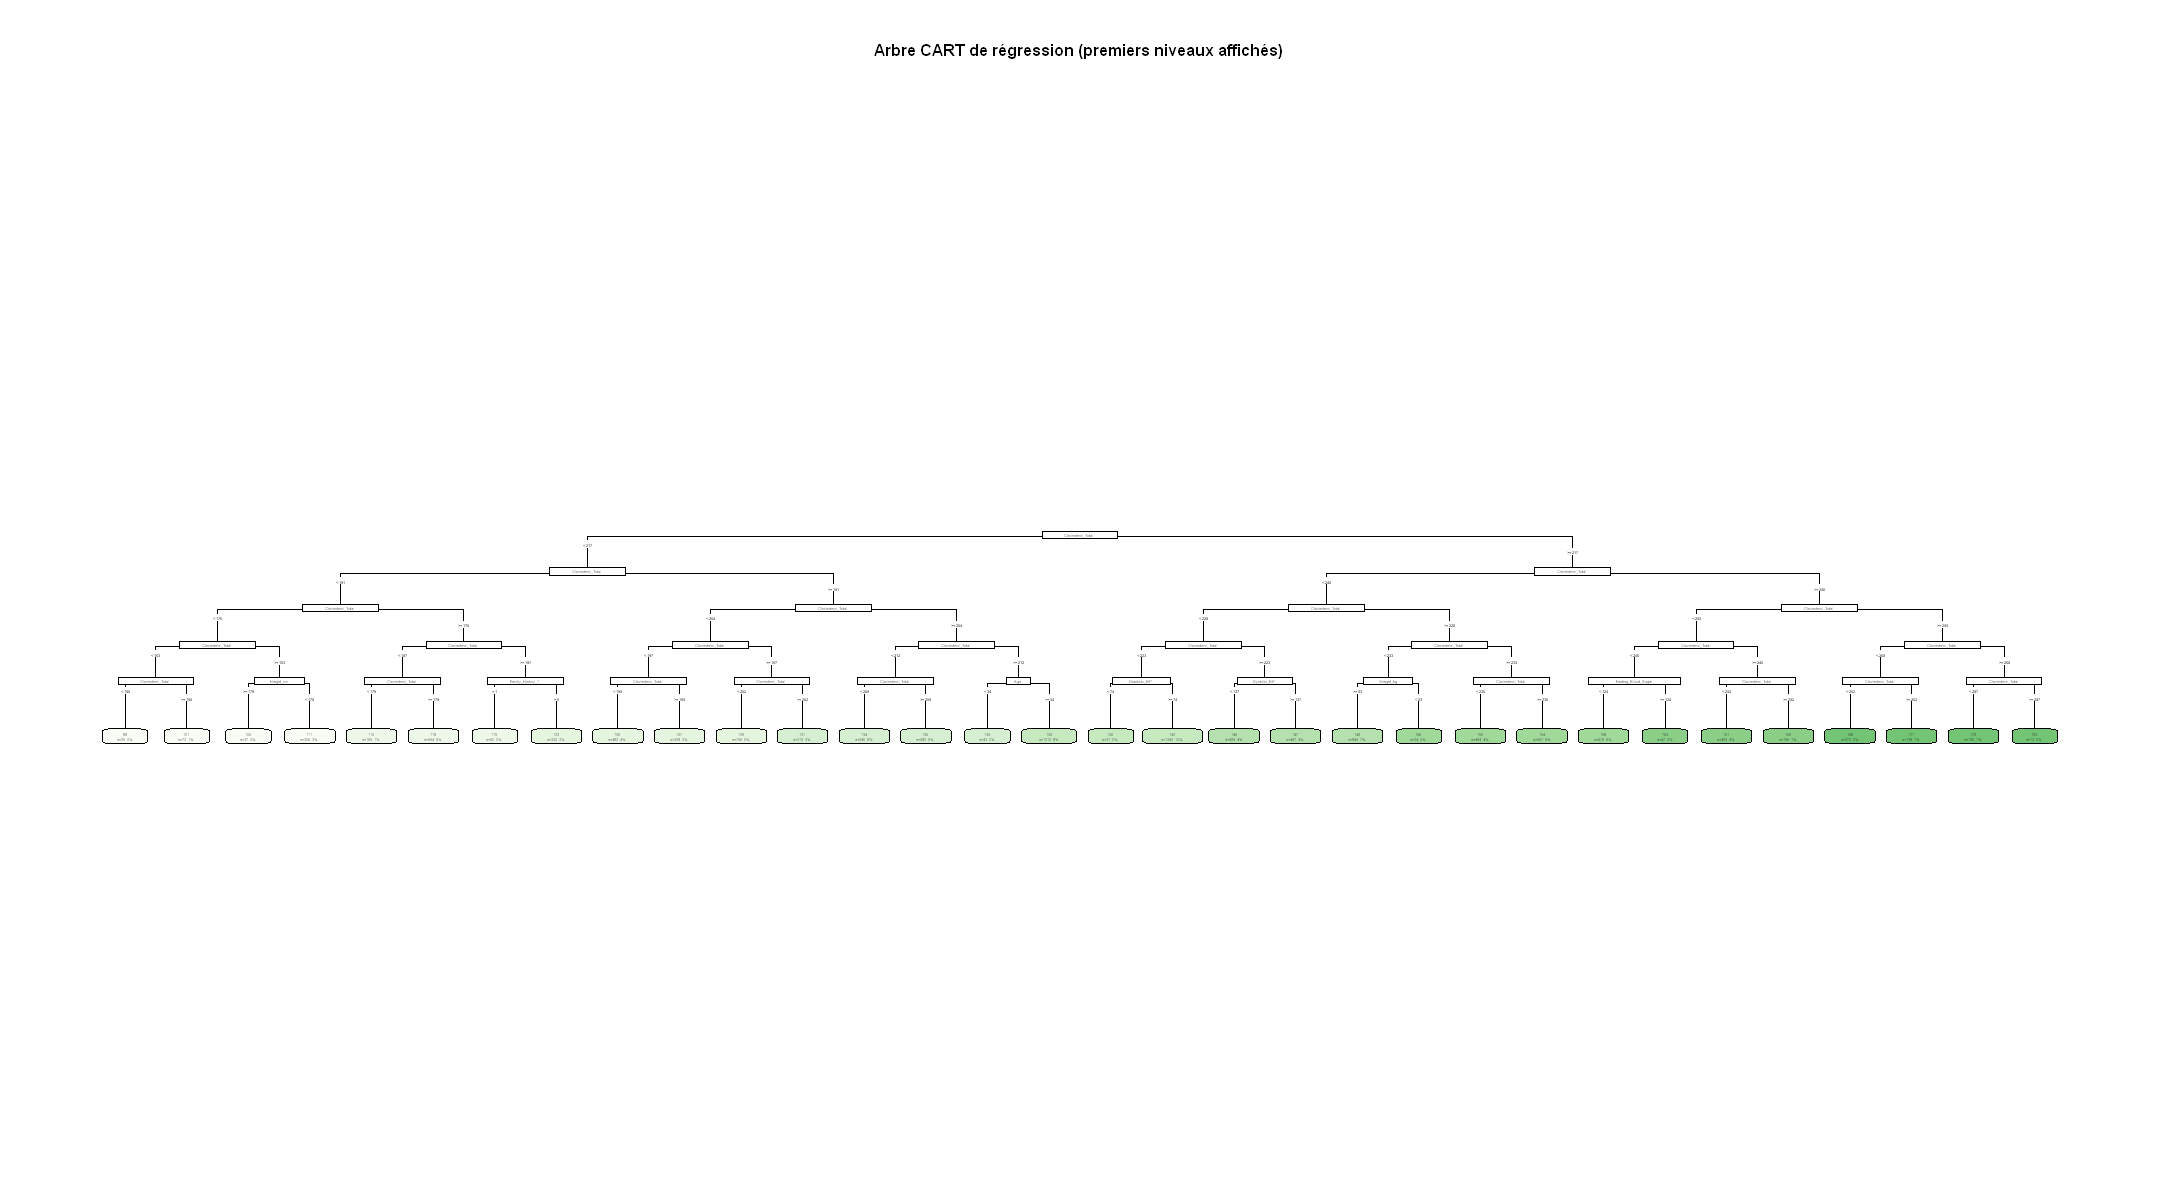

In [ ]:
# Importance des variables CART régression
cart_imp <- sort(cart_reg$variable.importance, decreasing = TRUE)
cat("Importance des variables (top 10) :\n")
print(round(head(cart_imp, 10), 2))

# Visualisation des 3 premiers niveaux
options(repr.plot.width = 18, repr.plot.height = 10)
rpart.plot(cart_reg, type = 5, extra = 101, fallen.leaves = TRUE,
           tweak = 1.0, box.palette = "Greens",
           main = "Arbre CART de régression (premiers niveaux affichés)")


L'arbre confirme très nettement le rôle central de `Cholesterol_Total` dans la prédiction de `Cholesterol_LDL`. Son importance (≈ 2.67 × 10⁶ en somme brute de gain) est presque six fois supérieure à celle de la deuxième variable (`Age` ≈ 4.72 × 10⁵), et toutes les premières coupures se font sur le cholestérol total. Les autres variables (BMI, Systolic_BP, Weight_kg, Diastolic_BP) interviennent ensuite, avec des contributions très inférieures.

Ce résultat est cohérent avec l'analyse exploratoire et avec les modèles linéaires : l'information prédictive est très concentrée. L'intérêt du CART est donc moins de découvrir de nombreuses variables explicatives nouvelles que de proposer une lecture par seuils de la relation dominante.

On étudie ensuite plus précisément l'effet des paramètres de complexité. L'objectif est de visualiser le compromis biais-variance : un arbre trop simple sous-apprend, tandis qu'un arbre trop profond peut trop s'adapter aux particularités de l'échantillon d'apprentissage.

On fait varier séparément `maxdepth` et `minbucket`, puis on compare le RMSE sur l'apprentissage et sur le test. L'écart entre les deux courbes permet de repérer les zones de surapprentissage.

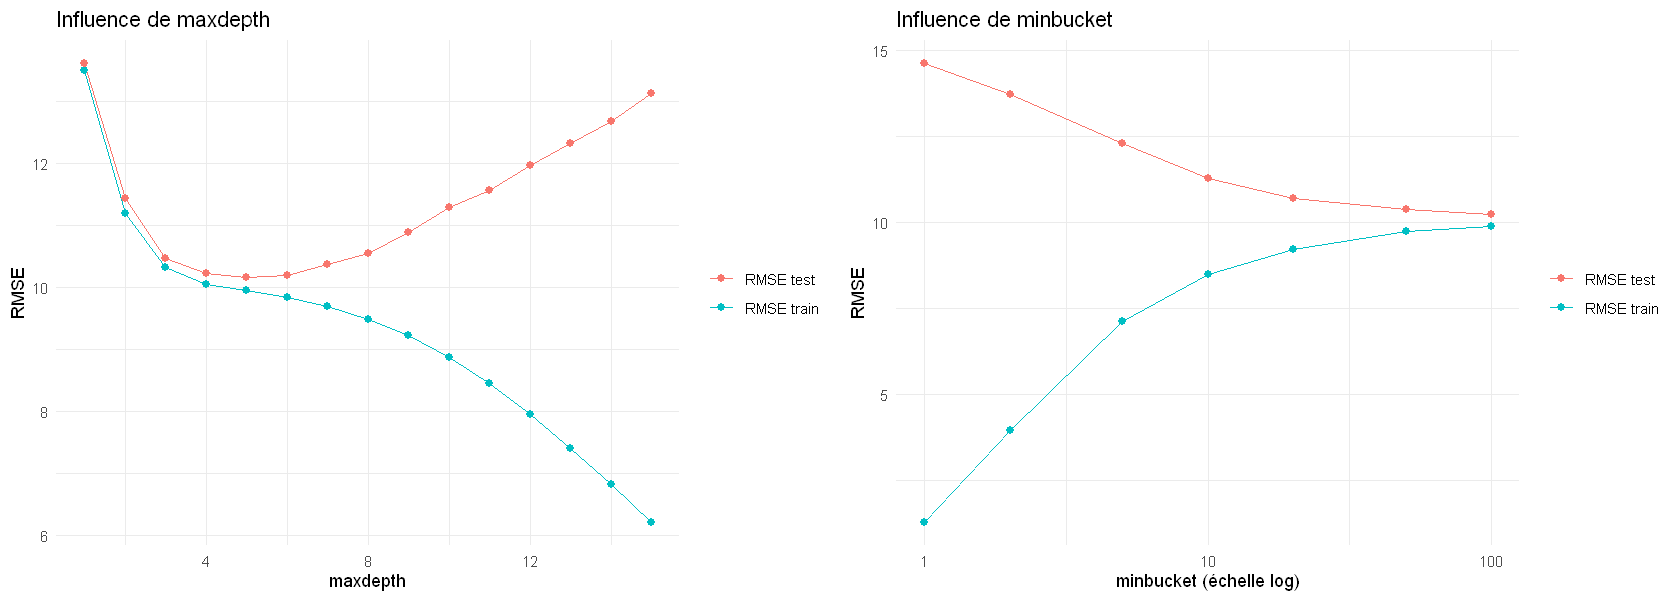

In [ ]:
# Courbes RMSE selon maxdepth
depth_values <- 1:15
depth_rows <- list()
for (d in depth_values) {
  set.seed(42)
  m <- rpart(Y ~ ., data = df_train_reg, method = "anova",
             control = rpart.control(maxdepth = d, cp = 0, minbucket = 1, xval = 0))
  depth_rows[[length(depth_rows) + 1]] <- data.frame(
    maxdepth   = d,
    rmse_train = sqrt(mean((Y_train_cholest - predict(m))^2)),
    rmse_test  = sqrt(mean((Y_test_cholest - predict(m, newdata = X_test_r))^2)),
    n_leaves   = sum(m$frame$var == "<leaf>")
  )
}
depth_df_reg <- do.call(rbind, depth_rows)

# Courbes RMSE selon minbucket
leaf_values <- c(1, 2, 5, 10, 20, 50, 100)
leaf_rows <- list()
for (l in leaf_values) {
  set.seed(42)
  m <- rpart(Y ~ ., data = df_train_reg, method = "anova",
             control = rpart.control(minbucket = l, cp = 0, xval = 0))
  leaf_rows[[length(leaf_rows) + 1]] <- data.frame(
    minbucket  = l,
    rmse_train = sqrt(mean((Y_train_cholest - predict(m))^2)),
    rmse_test  = sqrt(mean((Y_test_cholest - predict(m, newdata = X_test_r))^2)),
    n_leaves   = sum(m$frame$var == "<leaf>")
  )
}
leaf_df_reg <- do.call(rbind, leaf_rows)

depth_long <- rbind(
  data.frame(x = depth_df_reg$maxdepth, rmse = depth_df_reg$rmse_train, type = "RMSE train"),
  data.frame(x = depth_df_reg$maxdepth, rmse = depth_df_reg$rmse_test,  type = "RMSE test")
)
leaf_long <- rbind(
  data.frame(x = leaf_df_reg$minbucket, rmse = leaf_df_reg$rmse_train, type = "RMSE train"),
  data.frame(x = leaf_df_reg$minbucket, rmse = leaf_df_reg$rmse_test,  type = "RMSE test")
)

p1 <- ggplot(depth_long, aes(x = x, y = rmse, color = type)) +
  geom_line() + geom_point(size = 2) +
  labs(x = "maxdepth", y = "RMSE", color = NULL, title = "Influence de maxdepth") +
  theme_minimal()
p2 <- ggplot(leaf_long, aes(x = x, y = rmse, color = type)) +
  geom_line() + geom_point(size = 2) +
  scale_x_log10() +
  labs(x = "minbucket (échelle log)", y = "RMSE", color = NULL,
       title = "Influence de minbucket") +
  theme_minimal()

options(repr.plot.width = 14, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)


Les courbes montrent que la profondeur améliore d'abord les performances, puis finit par creuser l'écart entre apprentissage et test lorsque l'arbre devient trop complexe. Le RMSE train continue alors de diminuer, tandis que le RMSE test ne s'améliore plus, voire se dégrade : c'est le comportement typique d'un arbre qui surapprend.

Le paramètre `minbucket` régularise l'arbre dans l'autre sens. Des feuilles trop petites donnent un modèle très flexible ; des feuilles plus grandes imposent des prédictions plus stables, mais peuvent aussi lisser excessivement la relation. Les meilleurs réglages se situent donc dans une zone intermédiaire.

### 3.1. Élagage et sélection de complexité

On introduit ensuite une pénalisation explicite de la complexité avec le cost-complexity pruning. L'idée est de partir d'un arbre très développé, puis de supprimer progressivement les branches dont le gain prédictif ne compense pas la complexité ajoutée.

Le paramètre `cp` règle cette pénalisation : plus il est grand, plus l'arbre final est simple. La fonction `rpart` calcule directement la table des `cp` candidats et leur erreur estimée par validation croisée interne (10 plis par défaut). On retient la valeur de `cp` qui minimise l'erreur en validation croisée, puis on élague l'arbre maximal en conséquence.

In [ ]:
# Arbre maximal avec CV interne sur cp
set.seed(42)
t0 <- Sys.time()
full_tree_reg <- rpart(Y ~ ., data = df_train_reg, method = "anova",
                       control = rpart.control(cp = 0, minbucket = 1, xval = 10))
t_full_r <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

cat(sprintf("Temps fit arbre maximal : %.2f s, n_feuilles = %d\n",
            t_full_r, sum(full_tree_reg$frame$var == "<leaf>")))

cptab_reg <- full_tree_reg$cptable
best_cp_idx_r <- which.min(cptab_reg[, "xerror"])
best_cp_reg   <- cptab_reg[best_cp_idx_r, "CP"]
cat(sprintf("cp optimal (xerror min) : %.6f, n_split = %d\n",
            best_cp_reg, cptab_reg[best_cp_idx_r, "nsplit"]))

t0 <- Sys.time()
pruned_tree_reg <- prune(full_tree_reg, cp = best_cp_reg)
t_prune_r <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
n_leaves_prune <- sum(pruned_tree_reg$frame$var == "<leaf>")

pred_train_p <- predict(pruned_tree_reg, newdata = df_train_reg)
pred_test_p  <- predict(pruned_tree_reg, newdata = df_test_reg)
sc_pruned_reg <- regression_scores(pred_train_p, pred_test_p)

store_regr_result("CART élagué", sc_pruned_reg, t_full_r + t_prune_r, "Arbre",
                  sprintf("cp=%.5f, n_leaves=%d", best_cp_reg, n_leaves_prune))
print(results_regr[["CART élagué"]])


Temps fit arbre maximal : 2.78 s, n_feuilles = 7693


cp optimal (xerror min) : 0.000400, n_split = 17


       Modele Categorie RMSE train RMSE test MAE test R2 train R2 test
1 CART élagué     Arbre     10.021    10.196    8.102   0.6881  0.6717
  Temps entrainement (s)          Hyperparametre
1                  2.829 cp=0.00040, n_leaves=18


La validation croisée interne choisit un `cp` très faible (≈ 4 × 10⁻⁴), ce qui correspond à un arbre de 18 feuilles seulement. C'est un arbre nettement plus simple que le CART réglé par grille `maxdepth` / `minbucket` (32 feuilles).

Sa performance test est très proche du CART par grille : RMSE test ≈ 10.20 contre 10.15, et $R^2$ test ≈ 0.672 contre 0.675. L'élagage permet donc d'obtenir un modèle presque aussi performant avec deux fois moins de feuilles, ce qui améliore l'interprétabilité sans coût notable de précision.

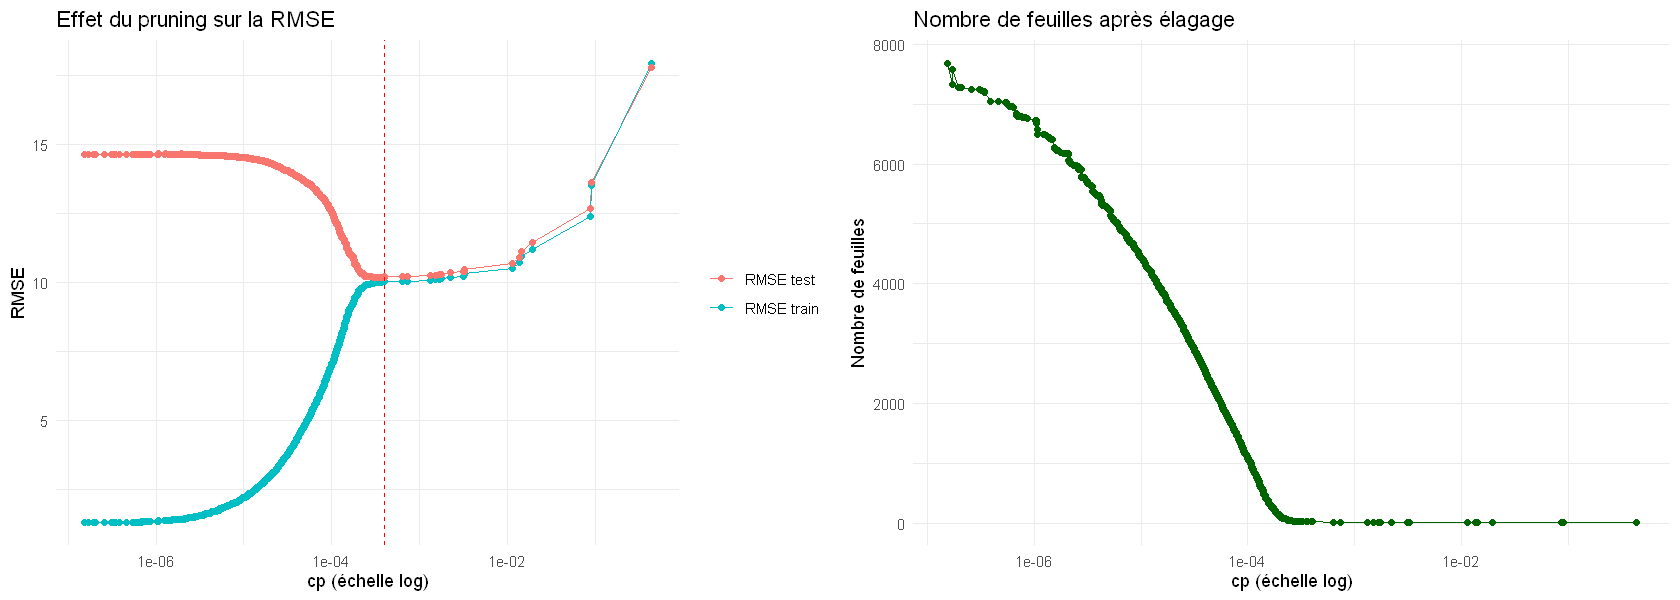

In [ ]:
# Effet du cp sur RMSE et nombre de feuilles
cptab_df_reg <- as.data.frame(cptab_reg)
cptab_df_reg$cp <- cptab_df_reg$CP

# Pour chaque cp candidat, recalculer RMSE train/test
cp_curves <- list()
for (i in seq_len(nrow(cptab_df_reg))) {
  cp_v <- cptab_df_reg$cp[i]
  if (cp_v <= 0) next
  t <- prune(full_tree_reg, cp = cp_v)
  cp_curves[[length(cp_curves) + 1]] <- data.frame(
    cp = cp_v,
    rmse_train = sqrt(mean((Y_train_cholest - predict(t))^2)),
    rmse_test  = sqrt(mean((Y_test_cholest  - predict(t, newdata = X_test_r))^2)),
    n_leaves   = cptab_df_reg$nsplit[i] + 1
  )
}
cp_curves_df <- do.call(rbind, cp_curves)

cp_long <- rbind(
  data.frame(cp = cp_curves_df$cp, rmse = cp_curves_df$rmse_train, type = "RMSE train"),
  data.frame(cp = cp_curves_df$cp, rmse = cp_curves_df$rmse_test,  type = "RMSE test")
)

p_rmse <- ggplot(cp_long, aes(x = cp, y = rmse, color = type)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = best_cp_reg, linetype = "dashed", color = "red") +
  scale_x_log10() +
  labs(x = "cp (échelle log)", y = "RMSE", color = NULL,
       title = "Effet du pruning sur la RMSE") +
  theme_minimal()
p_leaves <- ggplot(cp_curves_df, aes(x = cp, y = n_leaves)) +
  geom_line(color = "darkgreen") + geom_point(color = "darkgreen") +
  scale_x_log10() +
  labs(x = "cp (échelle log)", y = "Nombre de feuilles",
       title = "Nombre de feuilles après élagage") +
  theme_minimal()

options(repr.plot.width = 14, repr.plot.height = 5)
grid.arrange(p_rmse, p_leaves, ncol = 2)


Lorsque `cp` augmente, l'arbre est davantage élagué : le nombre de feuilles diminue fortement. En même temps, la RMSE train augmente, ce qui montre que le modèle devient moins ajusté aux données d'apprentissage.

La RMSE test reste assez stable autour du `cp` optimal puis se dégrade lentement à mesure que l'arbre devient trop simple. Le pruning permet ici de revenir d'un arbre potentiellement trop spécifique vers un arbre plus parcimonieux, sans gain substantiel de performance par rapport au CART réglé par grille (`maxdepth`, `minbucket`).

### 3.2. Bagging

Le bagging est particulièrement adapté aux arbres de régression, car un arbre individuel est souvent instable. On apprend plusieurs arbres sur des échantillons bootstrap de l'ensemble d'apprentissage, puis on moyenne leurs prédictions.

Cette moyenne ne cherche pas à rendre chaque arbre plus simple ; elle vise surtout à réduire la variance globale du prédicteur. On utilise également le score OOB, calculé sur les observations non tirées dans chaque bootstrap, comme indication interne de généralisation.

In [ ]:
# Grid Bagging : nbagg × minbucket, CV 3-folds
bag_grid <- expand.grid(nbagg = c(200), minbucket = c(1, 10, 20, 50))
set.seed(42)
folds_bag <- caret::createFolds(Y_train_cholest, k = 3, returnTrain = FALSE)

t0 <- Sys.time()
bag_rows <- list()
for (i in seq_len(nrow(bag_grid))) {
  nb <- bag_grid$nbagg[i]; mb <- bag_grid$minbucket[i]
  fold_rmses <- numeric(0)
  for (fold in folds_bag) {
    train_idx <- setdiff(seq_along(Y_train_cholest), fold)
    set.seed(42)
    bag_m <- ipred::bagging(Y ~ ., data = df_train_reg[train_idx, , drop = FALSE], nbagg = nb,
                            coob = FALSE,
                            control = rpart.control(cp = 0, minbucket = mb, xval = 0))
    pred_cv <- predict(bag_m, newdata = df_train_reg[fold, , drop = FALSE])
    fold_rmses <- c(fold_rmses, sqrt(mean((Y_train_cholest[fold] - pred_cv)^2)))
  }
  cat(sprintf("  nbagg = %d, minbucket = %d : RMSE CV = %.3f\n",
              nb, mb, mean(fold_rmses)))
  bag_rows[[length(bag_rows) + 1]] <- data.frame(
    nbagg = nb, minbucket = mb, rmse_cv = mean(fold_rmses))
}
bag_df <- do.call(rbind, bag_rows)
t_bag_grid <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

best_bag <- bag_df[which.min(bag_df$rmse_cv), ]
cat(sprintf("\nMeilleurs paramètres bagging : nbagg = %d, minbucket = %d\n",
            best_bag$nbagg, best_bag$minbucket))
cat(sprintf("Temps grid : %.1f s\n", t_bag_grid))

# Refit final avec OOB
set.seed(42)
t0 <- Sys.time()
bag_model_reg <- ipred::bagging(Y ~ ., data = df_train_reg,
                                nbagg = best_bag$nbagg, coob = TRUE,
                                control = rpart.control(cp = 0, minbucket = best_bag$minbucket, xval = 0))
t_bag_fit <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_b <- predict(bag_model_reg, newdata = X_train_r)
pred_test_b  <- predict(bag_model_reg, newdata = X_test_r)
sc_bag <- regression_scores(pred_train_b, pred_test_b)

store_regr_result("Bagging", sc_bag, t_bag_grid + t_bag_fit, "Agrégation",
                  sprintf("nbagg=%d, minbucket=%d", best_bag$nbagg, best_bag$minbucket))
cat(sprintf("\nRMSE OOB : %.3f\n", bag_model_reg$err))
print(results_regr[["Bagging"]])


  nbagg = 200, minbucket = 1 : RMSE CV = 10.296
  nbagg = 200, minbucket = 10 : RMSE CV = 10.185
  nbagg = 200, minbucket = 20 : RMSE CV = 10.135
  nbagg = 200, minbucket = 50 : RMSE CV = 10.099



Meilleurs paramètres bagging : nbagg = 200, minbucket = 50


Temps grid : 254.7 s



RMSE OOB : 10.077


   Modele  Categorie RMSE train RMSE test MAE test R2 train R2 test
1 Bagging Agrégation      9.479    10.124    8.065   0.7209  0.6764
  Temps entrainement (s)          Hyperparametre
1                270.822 nbagg=200, minbucket=50


Le bagging retient 200 arbres avec au moins 50 observations par feuille. Sur la grille testée, on observe que le `minbucket` est important : passer de `minbucket = 1` à `minbucket = 50` fait baisser la RMSE CV de 10.30 à 10.10, soit un gain non négligeable. Les arbres très profonds (`minbucket = 1`) ajoutent du bruit que l'agrégation peine à neutraliser.

Sur le test, le bagging obtient une RMSE de 10.12, légèrement meilleure que le CART élagué (10.20). L'écart entre train (9.48) et test (10.12) reste présent mais la moyenne de nombreux arbres stabilise les prédictions. La RMSE OOB (10.08) est en accord avec la RMSE test, ce qui valide l'utilisation du score OOB comme estimateur de généralisation.

### 3.3. Random Forest

La random forest reprend le principe du bagging, mais ajoute une randomisation sur les variables candidates à chaque coupure. Cette contrainte rend les arbres moins corrélés entre eux, ce qui peut améliorer la qualité de la moyenne finale.

Dans ce jeu de données, on s'attend toutefois à ce que le gain soit limité, car `Cholesterol_Total` domine très fortement le signal prédictif. La forêt permet donc surtout de vérifier si l'agrégation et la randomisation stabilisent légèrement le CART de base.

On parcourt une grille sur `mtry` (nombre de variables candidates à chaque coupure) à `ntree = 200`, en comparant l'erreur out-of-bag, puis on réajuste le meilleur modèle avec `ntree = 300`.

In [ ]:
# Grid RF sur mtry par RMSE OOB (ntree = 200)
mtry_grid <- c(3, 5, 7, 10, 19)
rf_grid_rows <- list()
for (mt in mtry_grid) {
  set.seed(42)
  rf_tmp <- randomForest(x = X_train_r, y = Y_train_cholest,
                          ntree = 200, mtry = mt, importance = FALSE)
  rmse_oob <- sqrt(rf_tmp$mse[200])
  cat(sprintf("  mtry = %d : RMSE OOB = %.3f\n", mt, rmse_oob))
  rf_grid_rows[[length(rf_grid_rows) + 1]] <- data.frame(mtry = mt, rmse_oob = rmse_oob)
}
rf_grid_df <- do.call(rbind, rf_grid_rows)
best_mtry_r <- rf_grid_df$mtry[which.min(rf_grid_df$rmse_oob)]
cat(sprintf("\nMeilleur mtry : %d\n", best_mtry_r))

# Refit avec ntree = 300
set.seed(42)
t0 <- Sys.time()
rf_model_reg <- randomForest(x = X_train_r, y = Y_train_cholest,
                              ntree = 300, mtry = best_mtry_r,
                              importance = TRUE, keep.forest = TRUE)
t_rf_reg <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_rf <- predict(rf_model_reg, newdata = X_train_r)
pred_test_rf  <- predict(rf_model_reg, newdata = X_test_r)
sc_rf <- regression_scores(pred_train_rf, pred_test_rf)

store_regr_result("Random Forest", sc_rf, t_rf_reg, "Agrégation",
                  sprintf("mtry=%d, ntree=300", best_mtry_r))

rmse_oob_final <- sqrt(rf_model_reg$mse[300])
r2_oob_final   <- 1 - rf_model_reg$mse[300] /
                  (var(Y_train_cholest) * (length(Y_train_cholest) - 1) / length(Y_train_cholest))
cat(sprintf("\nRMSE OOB : %.3f, R² OOB : %.4f\n", rmse_oob_final, r2_oob_final))
print(results_regr[["Random Forest"]])


  mtry = 3 : RMSE OOB = 10.732
  mtry = 5 : RMSE OOB = 10.364
  mtry = 7 : RMSE OOB = 10.253
  mtry = 10 : RMSE OOB = 10.235
  mtry = 19 : RMSE OOB = 10.319



Meilleur mtry : 10



RMSE OOB : 10.236, R² OOB : 0.6746


         Modele  Categorie RMSE train RMSE test MAE test R2 train R2 test
1 Random Forest Agrégation      4.283    10.174    8.115    0.943  0.6732
  Temps entrainement (s)     Hyperparametre
1                106.555 mtry=10, ntree=300


La validation par OOB retient un `mtry = 10`, soit environ la moitié des 19 variables candidates. Les valeurs voisines `mtry = 7` et `mtry = 19` donnent des RMSE OOB très proches (10.25 et 10.32), ce qui confirme que le choix précis de `mtry` n'est pas critique sur ces données.

Sur le test, la random forest obtient une RMSE de 10.17 et un $R^2$ de 0.673, comparables au bagging et au CART élagué. Le score $R^2$ OOB (0.6746) est cohérent avec la performance test. La RMSE train très basse (4.28) reflète le surapprentissage individuel de chaque arbre construit sans contrainte de profondeur, mais le vote moyen reste correctement calibré sur les données nouvelles.

  ntree rmse_oob rmse_test
1    50 10.44623  10.25579
2   100 10.30076  10.21570
3   200 10.23550  10.19464
4   400 10.20432  10.17576



Top 10 importances (%IncMSE) :


                 var importance
   Cholesterol_Total     385.21
           Weight_kg      26.78
                 BMI      20.79
         Systolic_BP      18.78
        Diastolic_BP      18.35
           Height_cm      17.89
                 Age      14.53
            Gender_1       8.25
     Cholesterol_HDL       6.56
 Fasting_Blood_Sugar       1.41


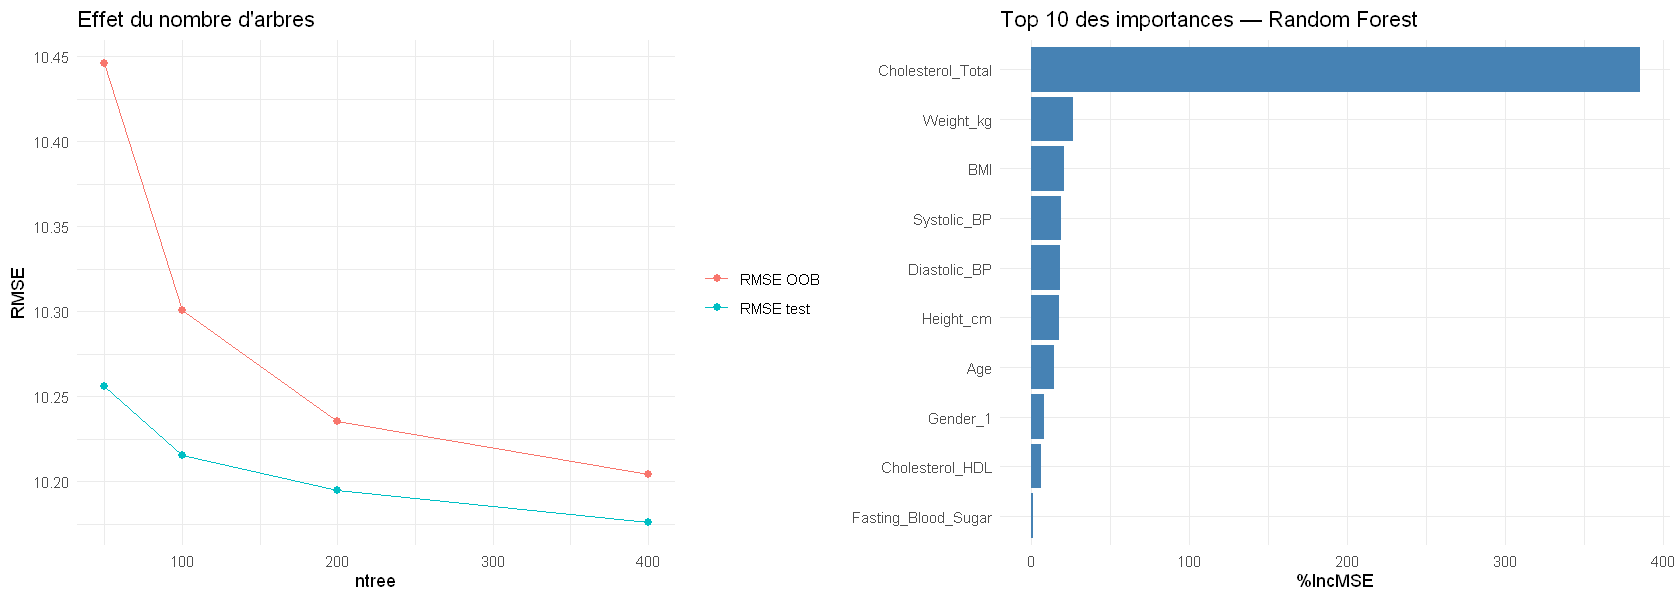

In [ ]:
# Courbe RMSE test selon ntree + importances
rf_curve_rows <- list()
for (nt in c(50, 100, 200, 400)) {
  set.seed(42)
  rf_tmp <- randomForest(x = X_train_r, y = Y_train_cholest,
                          ntree = nt, mtry = best_mtry_r,
                          xtest = X_test_r, ytest = Y_test_cholest,
                          importance = FALSE, keep.forest = FALSE)
  rmse_test <- sqrt(rf_tmp$test$mse[nt])
  rmse_oob  <- sqrt(rf_tmp$mse[nt])
  rf_curve_rows[[length(rf_curve_rows) + 1]] <- data.frame(
    ntree = nt, rmse_oob = rmse_oob, rmse_test = rmse_test)
}
rf_curve_df <- do.call(rbind, rf_curve_rows)
print(rf_curve_df)

imp_rf <- importance(rf_model_reg, type = 1)
imp_df_reg <- data.frame(var = rownames(imp_rf), importance = imp_rf[, 1])
imp_df_reg <- imp_df_reg[order(-imp_df_reg$importance), ]
imp_top10_reg <- head(imp_df_reg, 10)
imp_top10_reg$var <- factor(imp_top10_reg$var, levels = rev(imp_top10_reg$var))

p_ntree <- ggplot(
  rbind(data.frame(ntree = rf_curve_df$ntree, rmse = rf_curve_df$rmse_oob,  type = "RMSE OOB"),
        data.frame(ntree = rf_curve_df$ntree, rmse = rf_curve_df$rmse_test, type = "RMSE test")),
  aes(x = ntree, y = rmse, color = type)) +
  geom_line() + geom_point(size = 2) +
  labs(x = "ntree", y = "RMSE", color = NULL, title = "Effet du nombre d'arbres") +
  theme_minimal()

p_imp <- ggplot(imp_top10_reg, aes(x = var, y = importance)) +
  geom_col(fill = "steelblue") + coord_flip() +
  labs(x = NULL, y = "%IncMSE",
       title = "Top 10 des importances — Random Forest") +
  theme_minimal()

options(repr.plot.width = 14, repr.plot.height = 5)
grid.arrange(p_ntree, p_imp, ncol = 2)

cat("\nTop 10 importances (%IncMSE) :\n")
imp_print <- data.frame(var = as.character(imp_top10_reg$var),
                        importance = round(imp_top10_reg$importance, 2))
print(imp_print, row.names = FALSE)


La courbe RMSE selon `ntree` montre une amélioration faible mais continue : passer de 50 à 400 arbres fait baisser la RMSE de 10.26 à 10.18 sur le test. Le plateau est atteint autour de 200 arbres ; ajouter davantage n'apporte qu'un gain marginal.

Les importances %IncMSE confirment la domination écrasante de `Cholesterol_Total` (≈ 385), loin devant `Weight_kg` (27), `BMI` (21), `Systolic_BP` (19) et `Diastolic_BP` (18). Cette hiérarchie est largement cohérente avec celle observée pour les modèles linéaires, où `Cholesterol_Total` portait à elle seule l'essentiel de l'information prédictive. La random forest répartit un peu plus d'information sur des variables secondaires que le CART simple, mais le signal reste très concentré.

### 3.4. Boosting

En régression aussi, le boosting construit un modèle additif séquentiel. Chaque nouvel arbre cherche à corriger une partie des erreurs laissées par les arbres précédents, ce qui permet souvent d'obtenir un modèle plus précis qu'un arbre seul.

On compare ici deux approches :
- un boosting à arbres faibles de type AdaBoost, modélisé ici par des stumps (arbres de profondeur 1) appris séquentiellement par `gbm`
- un Gradient Boosting plus général, qui autorise des arbres un peu plus profonds.



In [ ]:
# AdaBoost (proxy) : gbm gaussien avec stumps (interaction.depth = 1)
ada_grid_reg <- expand.grid(shrinkage = c(0.05, 0.1, 0.5), n.trees_max = 200)
ada_rows_reg <- list()
t0 <- Sys.time()
for (i in seq_len(nrow(ada_grid_reg))) {
  lr <- ada_grid_reg$shrinkage[i]
  set.seed(42)
  ada_tmp <- gbm(Y ~ ., data = df_train_reg, distribution = "gaussian",
                 n.trees = 200, shrinkage = lr,
                 interaction.depth = 1, n.minobsinnode = 10,
                 cv.folds = 5, verbose = FALSE)
  best_iter <- which.min(ada_tmp$cv.error)
  cat(sprintf("  shrinkage=%.2f : best_iter=%d, cv.error=%.3f\n",
              lr, best_iter, ada_tmp$cv.error[best_iter]))
  ada_rows_reg[[length(ada_rows_reg) + 1]] <- list(
    model = ada_tmp, best_iter = best_iter,
    cv_err = ada_tmp$cv.error[best_iter], lr = lr
  )
}
t_ada_reg <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

best_ada_idx <- which.min(sapply(ada_rows_reg, function(x) x$cv_err))
ada_best_reg <- ada_rows_reg[[best_ada_idx]]
cat(sprintf("\nMeilleurs paramètres AdaBoost : shrinkage = %.2f, n.trees = %d\n",
            ada_best_reg$lr, ada_best_reg$best_iter))

pred_train_ada <- predict(ada_best_reg$model, newdata = df_train_reg, n.trees = ada_best_reg$best_iter)
pred_test_ada  <- predict(ada_best_reg$model, newdata = df_test_reg,  n.trees = ada_best_reg$best_iter)
sc_ada_reg <- regression_scores(pred_train_ada, pred_test_ada)

store_regr_result("AdaBoost", sc_ada_reg, t_ada_reg, "Boosting",
                  sprintf("shrinkage=%.2f, n.trees=%d, depth=1", ada_best_reg$lr, ada_best_reg$best_iter))
print(results_regr[["AdaBoost"]])


  shrinkage=0.05 : best_iter=199, cv.error=100.814
  shrinkage=0.10 : best_iter=142, cv.error=100.931
  shrinkage=0.50 : best_iter=197, cv.error=103.520



Meilleurs paramètres AdaBoost : shrinkage = 0.05, n.trees = 199


    Modele Categorie RMSE train RMSE test MAE test R2 train R2 test
1 AdaBoost  Boosting      9.971    10.063        8   0.6912  0.6802
  Temps entrainement (s)                       Hyperparametre
1                  18.69 shrinkage=0.05, n.trees=199, depth=1


Le proxy AdaBoost (gbm gaussien à stumps) retient un `shrinkage` de 0.05 et 199 itérations. Sa RMSE test de 10.06 est légèrement supérieure à celle des meilleurs modèles linéaires (≈ 10.04 pour le Lasso et la régression sélectionnée par BIC), mais reste comparable. La validation croisée interne montre que la déviance se stabilise lentement avec `n.trees`, ce qui est attendu pour un boosting à arbres très simples.

On teste maintenant le Gradient Boosting, qui autorise des arbres un peu plus profonds et un nombre d'itérations plus élevé.

In [ ]:
# Gradient Boosting : gbm gaussien avec interaction.depth ∈ {1, 2, 3}
gb_grid_reg <- expand.grid(depth = c(1, 2, 3), shrinkage = c(0.03, 0.05, 0.1))
n.trees_max_gb <- 300
gb_rows_reg <- list()
t0 <- Sys.time()
for (i in seq_len(nrow(gb_grid_reg))) {
  d <- gb_grid_reg$depth[i]; lr <- gb_grid_reg$shrinkage[i]
  set.seed(42)
  gb_tmp <- gbm(Y ~ ., data = df_train_reg, distribution = "gaussian",
                n.trees = n.trees_max_gb, shrinkage = lr,
                interaction.depth = d, n.minobsinnode = 10,
                cv.folds = 5, verbose = FALSE)
  best_iter <- which.min(gb_tmp$cv.error)
  cat(sprintf("  depth=%d, shrinkage=%.2f : best_iter=%d, cv.error=%.3f\n",
              d, lr, best_iter, gb_tmp$cv.error[best_iter]))
  gb_rows_reg[[length(gb_rows_reg) + 1]] <- list(
    model = gb_tmp, best_iter = best_iter,
    cv_err = gb_tmp$cv.error[best_iter], depth = d, lr = lr
  )
}
t_gb_reg <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

best_gb_idx <- which.min(sapply(gb_rows_reg, function(x) x$cv_err))
gb_best_reg <- gb_rows_reg[[best_gb_idx]]
cat(sprintf("\nMeilleurs paramètres GB : depth = %d, shrinkage = %.2f, n.trees = %d\n",
            gb_best_reg$depth, gb_best_reg$lr, gb_best_reg$best_iter))

pred_train_gb <- predict(gb_best_reg$model, newdata = df_train_reg, n.trees = gb_best_reg$best_iter)
pred_test_gb  <- predict(gb_best_reg$model, newdata = df_test_reg,  n.trees = gb_best_reg$best_iter)
sc_gb_reg <- regression_scores(pred_train_gb, pred_test_gb)

store_regr_result("Gradient Boosting", sc_gb_reg, t_gb_reg, "Boosting",
                  sprintf("depth=%d, shrinkage=%.2f, n.trees=%d",
                          gb_best_reg$depth, gb_best_reg$lr, gb_best_reg$best_iter))
print(results_regr[["Gradient Boosting"]])


  depth=1, shrinkage=0.03 : best_iter=300, cv.error=100.814
  depth=2, shrinkage=0.03 : best_iter=233, cv.error=100.693
  depth=3, shrinkage=0.03 : best_iter=161, cv.error=100.777
  depth=1, shrinkage=0.05 : best_iter=233, cv.error=100.770
  depth=2, shrinkage=0.05 : best_iter=139, cv.error=100.629
  depth=3, shrinkage=0.05 : best_iter=95, cv.error=100.846
  depth=1, shrinkage=0.10 : best_iter=142, cv.error=100.931
  depth=2, shrinkage=0.10 : best_iter=60, cv.error=100.779
  depth=3, shrinkage=0.10 : best_iter=49, cv.error=100.948



Meilleurs paramètres GB : depth = 2, shrinkage = 0.05, n.trees = 139


             Modele Categorie RMSE train RMSE test MAE test R2 train R2 test
1 Gradient Boosting  Boosting      9.956    10.055    7.996   0.6921  0.6807
  Temps entrainement (s)                       Hyperparametre
1                 95.422 depth=2, shrinkage=0.05, n.trees=139


Le Gradient Boosting retient des arbres de profondeur 2 avec un `shrinkage` de 0.05 et 139 itérations. La déviance CV minimale est de 100.63, légèrement inférieure à celle d'AdaBoost (100.81). Sur le test, la RMSE est de 10.06 et le $R^2$ de 0.68, marginalement meilleur que l'AdaBoost et comparable au CART, au Bagging et à la Random Forest. Sur ce jeu de données, le boosting n'apporte donc pas un gain notable par rapport aux méthodes d'agrégation par bagging.

Il reste à vérifier si cette amélioration s'accompagne d'une structure d'importance différente ou si le modèle s'appuie toujours presque exclusivement sur le cholestérol total.

Top 10 importances Gradient Boosting :


                       var     rel.inf
         Cholesterol_Total 99.68293136
           Cholesterol_HDL  0.06970804
                       Age  0.05614509
                 Weight_kg  0.05001209
               Systolic_BP  0.03444392
       Fasting_Blood_Sugar  0.03171713
                 Height_cm  0.02206620
                       BMI  0.01937194
               Sleep_Hours  0.01293956
 Physical_Activity_Level_2  0.00683485


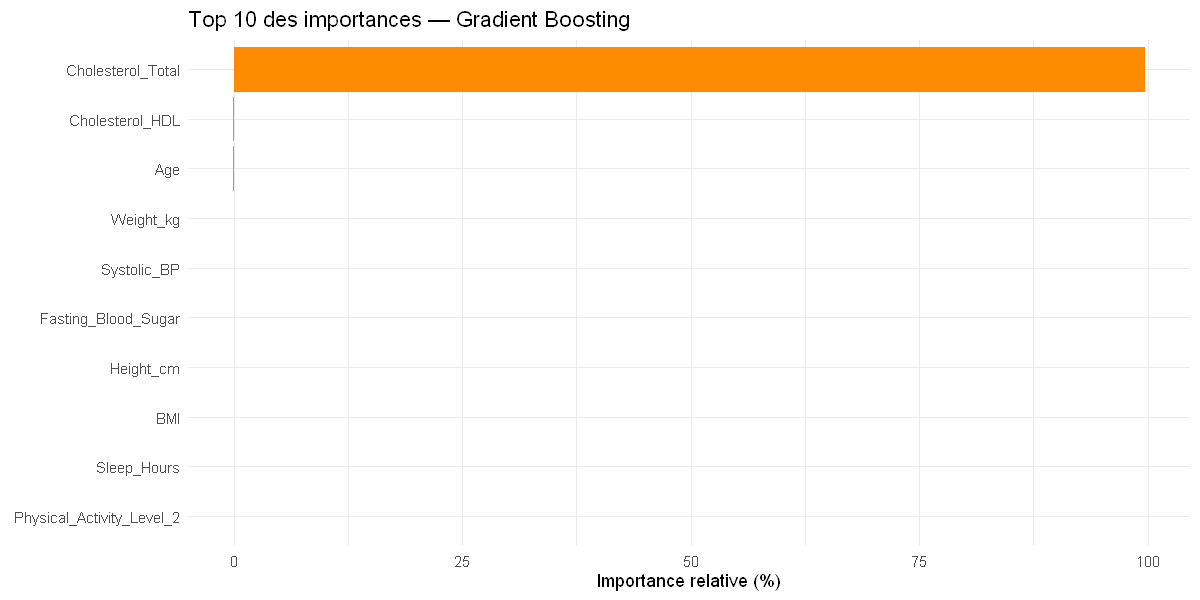

In [ ]:
# Importance relative des variables dans le Gradient Boosting
gbr_imp <- summary(gb_best_reg$model, n.trees = gb_best_reg$best_iter, plotit = FALSE)
gbr_imp_top10 <- head(gbr_imp, 10)
cat("Top 10 importances Gradient Boosting :\n")
print(gbr_imp_top10, row.names = FALSE)

gbr_imp_top10$var <- factor(as.character(gbr_imp_top10$var), levels = rev(as.character(gbr_imp_top10$var)))
options(repr.plot.width = 10, repr.plot.height = 5)
ggplot(gbr_imp_top10, aes(x = var, y = rel.inf)) +
  geom_col(fill = "darkorange") + coord_flip() +
  labs(x = NULL, y = "Importance relative (%)",
       title = "Top 10 des importances — Gradient Boosting") +
  theme_minimal()


Les importances du gradient boosting confirment la même conclusion que les modèles précédents : `Cholesterol_Total` concentre presque toute l'information prédictive, avec une importance relative de 99.7 %. Les autres variables ont des importances très faibles (< 0.1 %) et ne modifient qu'à la marge les prédictions.

Au final, les méthodes d'ensemble stabilisent le CART et améliorent légèrement ses performances, mais elles ne changent pas l'interprétation principale. La prédiction du LDL-cholestérol repose avant tout sur le cholestérol total ; les modèles plus complexes apportent surtout un gain modéré de précision.

## 4. kNN de régression

Le kNN de régression reprend la même logique que le kNN de classification, mais au lieu de voter pour une classe, il prédit une moyenne locale des valeurs de `Cholesterol_LDL` observées chez les plus proches voisins.

Les variables ayant déjà été standardisées, on utilise la distance euclidienne et un vote uniforme entre voisins. On parcourt une grille de valeurs de `k` par validation croisée à 5 plis et on retient la valeur qui minimise la RMSE.

In [ ]:
k_grid_reg <- expand.grid(k = c(10, 15, 20, 30, 35, 40, 50, 60))
ctrl_knn_r <- trainControl(method = "cv", number = 5)

t0 <- Sys.time()
set.seed(11)
knn_reg_fit <- train(x = Xr_train_r, y = Y_train_cholest,
                     method = "knn", metric = "RMSE",
                     trControl = ctrl_knn_r, tuneGrid = k_grid_reg)
t_knn_r <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

cat(sprintf("Temps kNN : %.1f s\n", t_knn_r))
cat(sprintf("k optimal : %d\n", knn_reg_fit$bestTune$k))
cat(sprintf("Meilleure RMSE CV : %.3f\n", min(knn_reg_fit$results$RMSE)))
cat("\nGrille complète :\n")
print(knn_reg_fit$results[, c("k", "RMSE", "RMSESD")], row.names = FALSE)

pred_train_knn_r <- predict(knn_reg_fit, newdata = Xr_train_r)
pred_test_knn_r  <- predict(knn_reg_fit, newdata = Xr_test_r)
sc_knn_r <- regression_scores(pred_train_knn_r, pred_test_knn_r)

store_regr_result("kNN régression", sc_knn_r, t_knn_r, "kNN",
                  sprintf("k=%d", knn_reg_fit$bestTune$k))
print(results_regr[["kNN régression"]])


Temps kNN : 20.5 s


k optimal : 20


Meilleure RMSE CV : 12.816



Grille complète :


  k     RMSE     RMSESD
 10 12.89920 0.05413874
 15 12.83555 0.09151349
 20 12.81624 0.10109944
 30 12.83834 0.08508763
 35 12.86166 0.07851138
 40 12.89838 0.07965346
 50 12.93983 0.07964912
 60 13.00158 0.08445811


          Modele Categorie RMSE train RMSE test MAE test R2 train R2 test
1 kNN régression       kNN      12.11    12.624    9.948   0.5445  0.4968
  Temps entrainement (s) Hyperparametre
1                 20.489           k=20


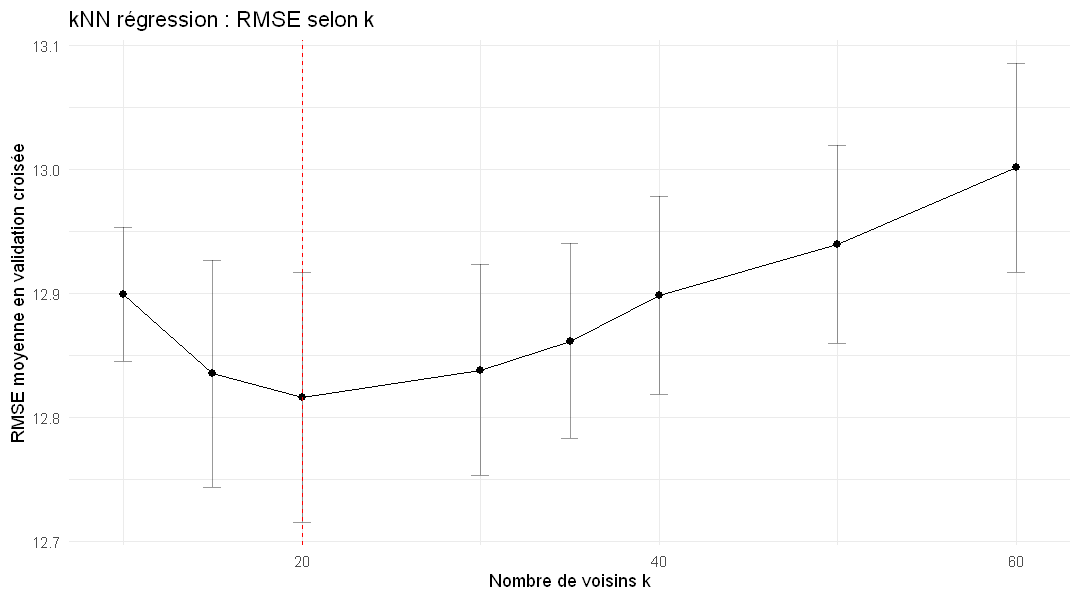

In [ ]:
# Courbe RMSE CV selon k
options(repr.plot.width = 9, repr.plot.height = 5)
ggplot(knn_reg_fit$results, aes(x = k, y = RMSE)) +
  geom_line() + geom_point(size = 2) +
  geom_errorbar(aes(ymin = RMSE - RMSESD, ymax = RMSE + RMSESD),
                width = 1, alpha = 0.4) +
  geom_vline(xintercept = knn_reg_fit$bestTune$k, linetype = "dashed", color = "red") +
  labs(x = "Nombre de voisins k", y = "RMSE moyenne en validation croisée",
       title = "kNN régression : RMSE selon k") +
  theme_minimal()


Le meilleur kNN de régression utilise `k = 20`. La RMSE de validation croisée est d'environ 12.82, et la RMSE test est proche, autour de 12.62.

Ces performances sont moins bonnes que celles des modèles linéaires ou des méthodes d'arbres agrégées (RMSE test autour de 10.0). Le kNN semble donc moins adapté ici pour prédire `Cholesterol_LDL`. La courbe d'évolution de la RMSE selon `k` montre que les valeurs proches (`k = 15`, `k = 20`, `k = 30`) donnent des performances très similaires, avec un écart-type comparable à l'écart entre courbes : le choix exact de `k` a un effet limité dans cette zone.

On passe ensuite au SVR, qui repose aussi sur une notion de distance, mais avec une approche fondée sur les marges et la régularisation.

## 5. SVR

Le Support Vector Regression reprend les idées des SVM dans un cadre de régression. On cherche une fonction aussi régulière que possible, tout en tolérant des écarts inférieurs à `epsilon`.

Les hyperparamètres principaux sont :
- `cost`, qui règle la pénalisation des écarts
- `epsilon`, qui fixe la largeur du tube d'insensibilité
- `kernel` et éventuellement `gamma`, qui contrôlent la forme de la non-linéarité.

Une validation croisée complète sur tout l'échantillon serait coûteuse. On retient donc une stratégie raisonnable : sélection des hyperparamètres par validation croisée sur un sous-échantillon de 4 000 observations, puis réentraînement final sur l'échantillon complet avec les paramètres retenus.

In [ ]:
# Sous-échantillon de 4 000 observations
set.seed(42)
sub_idx_svr <- sample(seq_along(Y_train_cholest), size = 4000)
X_svr_sub <- Xr_train_r[sub_idx_svr, , drop = FALSE]
y_svr_sub <- Y_train_cholest[sub_idx_svr]
df_svr_sub <- data.frame(Y = y_svr_sub, X_svr_sub)

# SVR linéaire
set.seed(42)
t0 <- Sys.time()
tune_svr_lin <- tune.svm(Y ~ ., data = df_svr_sub,
                          kernel = "linear",
                          cost = c(0.5, 1, 5),
                          epsilon = c(1, 2),
                          tunecontrol = tune.control(cross = 3))
t_svr_lin <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
cat(sprintf("SVR linéaire — meilleure RMSE CV : %.3f (temps : %.1f s)\n",
            sqrt(tune_svr_lin$best.performance), t_svr_lin))
print(tune_svr_lin$best.parameters)

# SVR RBF
gamma_scale_r <- 1 / ncol(X_svr_sub)
set.seed(42)
t0 <- Sys.time()
tune_svr_rbf <- tune.svm(Y ~ ., data = df_svr_sub,
                          kernel = "radial",
                          cost = c(0.5, 1, 5),
                          epsilon = c(1, 2),
                          gamma = c(gamma_scale_r, 0.1),
                          tunecontrol = tune.control(cross = 3))
t_svr_rbf <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
cat(sprintf("\nSVR RBF — meilleure RMSE CV : %.3f (temps : %.1f s)\n",
            sqrt(tune_svr_rbf$best.performance), t_svr_rbf))
print(tune_svr_rbf$best.parameters)

# Sélection du meilleur noyau, refit sur l'échantillon complet
err_lin <- tune_svr_lin$best.performance
err_rbf <- tune_svr_rbf$best.performance
t0 <- Sys.time()
if (err_lin <= err_rbf) {
  cat("\nNoyau retenu : linéaire\n")
  bp <- tune_svr_lin$best.parameters
  set.seed(42)
  svr_best <- svm(Y ~ ., data = data.frame(Y = Y_train_cholest, Xr_train_r),
                  kernel = "linear", cost = bp$cost, epsilon = bp$epsilon)
  best_hyper <- sprintf("linéaire, C=%.1f, ε=%.1f", bp$cost, bp$epsilon)
} else {
  cat("\nNoyau retenu : RBF\n")
  bp <- tune_svr_rbf$best.parameters
  set.seed(42)
  svr_best <- svm(Y ~ ., data = data.frame(Y = Y_train_cholest, Xr_train_r),
                  kernel = "radial", cost = bp$cost, epsilon = bp$epsilon, gamma = bp$gamma)
  best_hyper <- sprintf("RBF, C=%.1f, ε=%.1f, γ=%.4f", bp$cost, bp$epsilon, bp$gamma)
}
t_svr_fit <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_svr <- predict(svr_best, newdata = Xr_train_r)
pred_test_svr  <- predict(svr_best, newdata = Xr_test_r)
sc_svr <- regression_scores(pred_train_svr, pred_test_svr)

store_regr_result("SVR", sc_svr, t_svr_lin + t_svr_rbf + t_svr_fit, "SVR", best_hyper)
print(results_regr[["SVR"]])


SVR linéaire — meilleure RMSE CV : 9.943 (temps : 2.4 s)


  cost epsilon
1  0.5       1



SVR RBF — meilleure RMSE CV : 10.908 (temps : 6.5 s)


       gamma cost epsilon
3 0.05263158    1       1



Noyau retenu : linéaire


  Modele Categorie RMSE train RMSE test MAE test R2 train R2 test
1    SVR       SVR     10.008    10.089     8.03   0.6889  0.6786
  Temps entrainement (s)         Hyperparametre
1                  10.69 linéaire, C=0.5, ε=1.0


Le meilleur SVR retenu est un modèle linéaire avec `cost = 0.5` et `epsilon = 1`. Le noyau RBF n'est donc pas sélectionné (RMSE CV de 10.91 contre 9.94 pour le linéaire), ce qui confirme qu'une relation globalement linéaire suffit déjà à prédire le LDL-cholestérol.

Sur l'échantillon test complet (après réentraînement avec les hyperparamètres retenus), la RMSE atteint 10.09 et le $R^2$ atteint 0.679. Le SVR fait donc nettement mieux que le kNN et se rapproche des meilleurs modèles linéaires. On examine maintenant les prédictions et les résidus pour vérifier visuellement la qualité de l'ajustement.

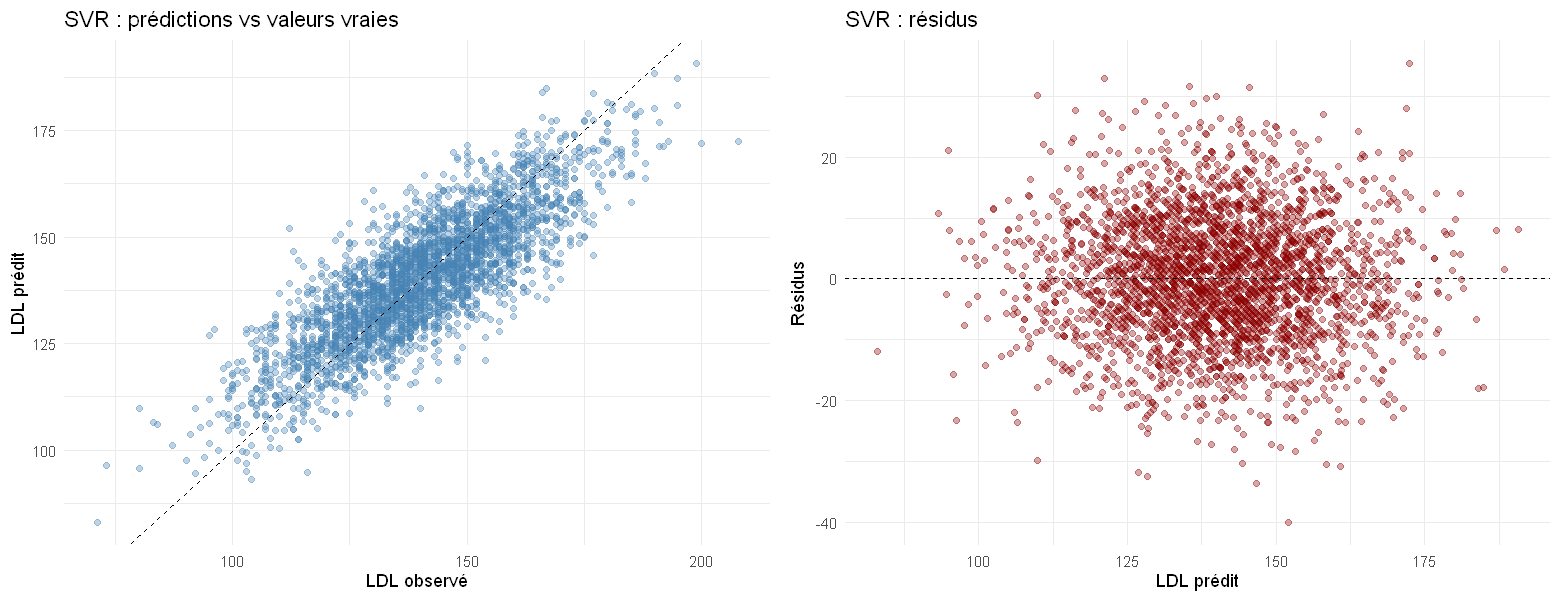

In [ ]:
# Diagnostic : prédictions vs valeurs vraies + résidus
svr_resid <- Y_test_cholest - pred_test_svr

p_pred <- ggplot(data.frame(obs = Y_test_cholest, pred = pred_test_svr),
                 aes(x = obs, y = pred)) +
  geom_point(alpha = 0.35, color = "steelblue") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "LDL observé", y = "LDL prédit",
       title = "SVR : prédictions vs valeurs vraies") +
  theme_minimal()

p_resid <- ggplot(data.frame(pred = pred_test_svr, resid = svr_resid),
                  aes(x = pred, y = resid)) +
  geom_point(alpha = 0.35, color = "darkred") +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "LDL prédit", y = "Résidus",
       title = "SVR : résidus") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p_pred, p_resid, ncol = 2)


Le nuage des prédictions montre une relation nette entre les valeurs observées et prédites, avec des points globalement proches de la diagonale. Le SVR capture donc bien la tendance principale du LDL-cholestérol.

Le graphique des résidus ne montre pas de structure très marquée : les erreurs sont globalement centrées autour de 0, même si la dispersion reste visible. Le SVR fournit donc un ajustement correct et stable. On passe maintenant aux réseaux de neurones, afin de tester un autre modèle non linéaire.

## 6. Réseau de neurones

On réalise maintenant une étude avec un réseau de neurones simple. L'objectif n'est pas de faire du deep learning, mais de disposer d'un autre modèle non linéaire de référence.

On utilise un réseau à une seule couche cachée, avec deux hyperparamètres :
- `size` : nombre de neurones de la couche cachée
- `decay` : coefficient de régularisation L2 sur les poids.

Comme pour le SVR, on tune les hyperparamètres sur le sous-échantillon de 4 000 observations puis on réentraîne le modèle final sur l'échantillon complet.

In [ ]:
# Sous-échantillon (même indices que SVR pour cohérence)
df_mlp_sub <- data.frame(Y = y_svr_sub, X_svr_sub)
mlp_grid_reg <- expand.grid(size = c(5, 10, 15), decay = c(1e-4, 1e-3, 1e-2))

set.seed(42)
folds_mlp_reg <- caret::createFolds(y_svr_sub, k = 3, returnTrain = FALSE)

t0 <- Sys.time()
mlp_rows_reg <- list()
for (i in seq_len(nrow(mlp_grid_reg))) {
  s <- mlp_grid_reg$size[i]; d <- mlp_grid_reg$decay[i]
  fold_rmses <- numeric(0)
  for (fold in folds_mlp_reg) {
    train_idx <- setdiff(seq_along(y_svr_sub), fold)
    set.seed(42)
    m <- nnet::nnet(Y ~ ., data = df_mlp_sub[train_idx, , drop = FALSE],
                    size = s, decay = d, linout = TRUE, maxit = 500, trace = FALSE)
    pred <- predict(m, newdata = df_mlp_sub[fold, , drop = FALSE])
    fold_rmses <- c(fold_rmses, sqrt(mean((y_svr_sub[fold] - pred)^2)))
  }
  mlp_rows_reg[[length(mlp_rows_reg) + 1]] <- data.frame(
    size = s, decay = d, rmse_cv = mean(fold_rmses))
}
mlp_df_reg <- do.call(rbind, mlp_rows_reg)
t_mlp_reg_search <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

best_mlp_reg <- mlp_df_reg[which.min(mlp_df_reg$rmse_cv), ]
cat(sprintf("Temps grid MLP : %.1f s\n", t_mlp_reg_search))
cat("\nGrille complète :\n")
print(mlp_df_reg, row.names = FALSE)
cat(sprintf("\nMeilleurs paramètres MLP : size = %d, decay = %g, RMSE CV = %.3f\n",
            best_mlp_reg$size, best_mlp_reg$decay, best_mlp_reg$rmse_cv))

# Refit final sur l'échantillon complet
set.seed(42)
t0 <- Sys.time()
mlp_model_reg <- nnet::nnet(Y ~ ., data = data.frame(Y = Y_train_cholest, Xr_train_r),
                             size = best_mlp_reg$size, decay = best_mlp_reg$decay,
                             linout = TRUE, maxit = 500, trace = FALSE)
t_mlp_reg_fit <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

pred_train_mlp <- predict(mlp_model_reg, newdata = Xr_train_r)
pred_test_mlp  <- predict(mlp_model_reg, newdata = Xr_test_r)
sc_mlp_reg <- regression_scores(pred_train_mlp, pred_test_mlp)

store_regr_result("Réseau de neurones (MLP)", sc_mlp_reg,
                  t_mlp_reg_search + t_mlp_reg_fit, "Réseau de neurones",
                  sprintf("size=%d, decay=%g", best_mlp_reg$size, best_mlp_reg$decay))
print(results_regr[["Réseau de neurones (MLP)"]])


Temps grid MLP : 112.0 s



Grille complète :


 size decay  rmse_cv
    5 1e-04 10.51902
   10 1e-04 31.15528
   15 1e-04 12.09941
    5 1e-03 10.87903
   10 1e-03 15.00282
   15 1e-03 13.85619
    5 1e-02 10.91839
   10 1e-02 11.16416
   15 1e-02 13.32421



Meilleurs paramètres MLP : size = 5, decay = 0.0001, RMSE CV = 10.519


                    Modele          Categorie RMSE train RMSE test MAE test
1 Réseau de neurones (MLP) Réseau de neurones      9.892    10.201    8.083
  R2 train R2 test Temps entrainement (s)       Hyperparametre
1    0.696  0.6714                119.418 size=5, decay=0.0001


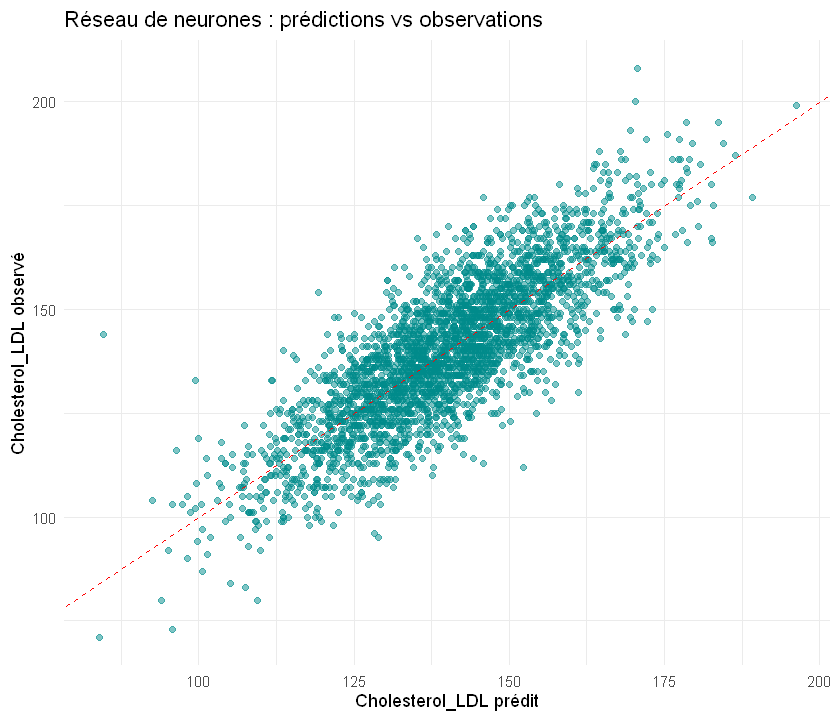

In [ ]:
# Diagnostic : prédictions vs observations
options(repr.plot.width = 7, repr.plot.height = 6)
ggplot(data.frame(obs = Y_test_cholest, pred = as.numeric(pred_test_mlp)),
       aes(x = pred, y = obs)) +
  geom_point(alpha = 0.5, color = "darkcyan") +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(x = "Cholesterol_LDL prédit", y = "Cholesterol_LDL observé",
       title = "Réseau de neurones : prédictions vs observations") +
  theme_minimal()


Le meilleur MLP retenu utilise une seule couche cachée de 5 neurones avec une pénalisation `decay = 0.0001`. La RMSE CV est de 10.52 sur le sous-échantillon et la RMSE test est de 10.20 après réentraînement sur l'échantillon complet, avec un $R^2$ test de 0.671.

Les configurations à 10 neurones donnent des RMSE CV très instables (jusqu'à 31 dans la grille testée), signe que le réseau peut tomber dans des minima locaux peu performants selon l'initialisation. La configuration à 5 neurones, plus simple, donne des résultats plus stables et constitue le meilleur compromis sur ces données.

Le nuage prédit-observé montre que le réseau capte bien la tendance générale du LDL-cholestérol, mais la dispersion reste plus importante que pour les meilleurs modèles. Le réseau de neurones ne dépasse donc pas les modèles linéaires ou le SVR dans cette tâche.

On peut maintenant comparer globalement tous les modèles de régression entraînés.

## 7. Comparaison globale des modèles

On rassemble maintenant l'ensemble des modèles optimisés sur l'échantillon de test. La comparaison porte à la fois sur la précision (RMSE, MAE, $R^2$), l'écart entre apprentissage et test, le coût d'entraînement et l'interprétabilité.

In [ ]:
# Tableau récapitulatif de tous les modèles de régression, trié par RMSE test croissante
comparison_df_regr <- do.call(rbind, results_regr)
comparison_df_regr <- comparison_df_regr[order(comparison_df_regr$`RMSE test`), ]
print(comparison_df_regr, row.names = FALSE)


                              Modele          Categorie RMSE train RMSE test
 Régression linéaire (sélection BIC)           Linéaire      9.989    10.035
                               Lasso  Linéaire pénalisé      9.990    10.035
 Régression linéaire (sélection AIC)           Linéaire      9.986    10.037
        Régression linéaire complète           Linéaire      9.984    10.042
                   Gradient Boosting           Boosting      9.956    10.055
                            AdaBoost           Boosting      9.971    10.063
                                 SVR                SVR     10.008    10.089
                               Ridge  Linéaire pénalisé     10.061    10.110
                             Bagging         Agrégation      9.479    10.124
                     CART régression              Arbre      9.957    10.148
                       Random Forest         Agrégation      4.283    10.174
                         CART élagué              Arbre     10.021    10.196

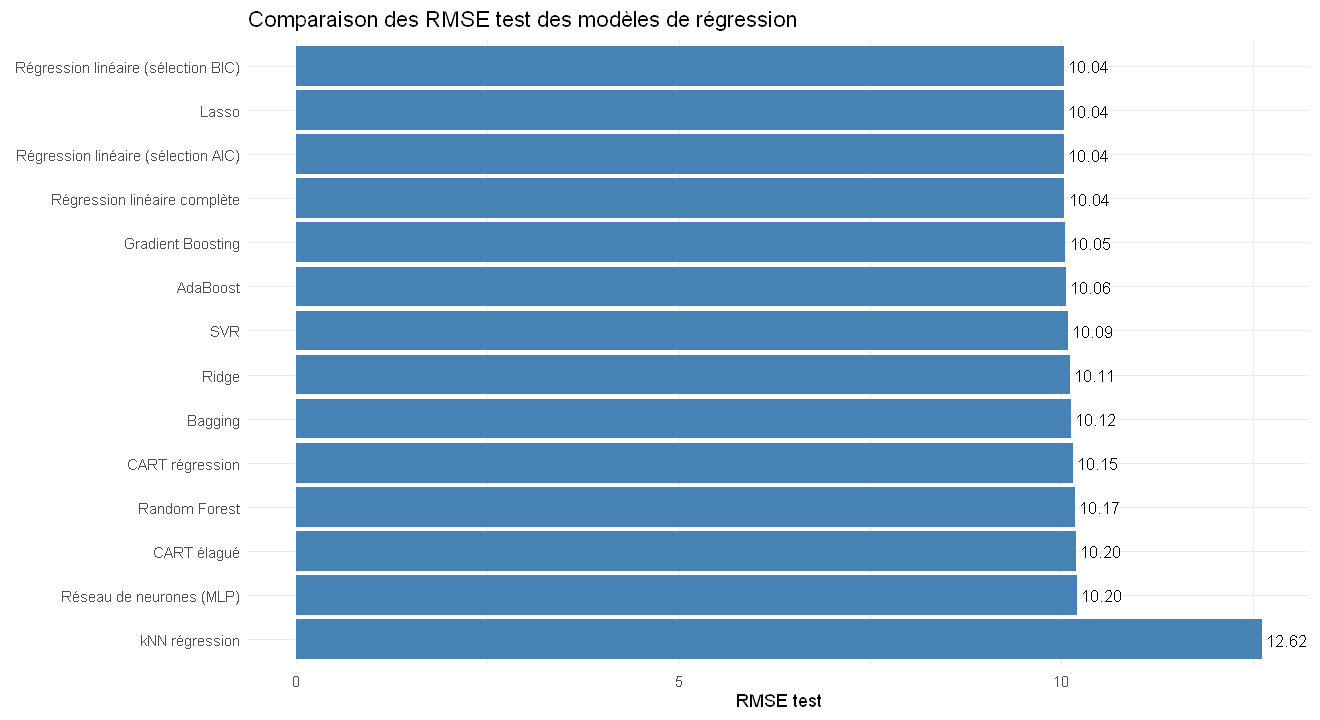

In [ ]:
# Barplot des RMSE test
comparison_df_plot <- comparison_df_regr
comparison_df_plot$Modele <- factor(comparison_df_plot$Modele,
                                    levels = rev(comparison_df_plot$Modele))

options(repr.plot.width = 11, repr.plot.height = 6)
ggplot(comparison_df_plot, aes(x = Modele, y = `RMSE test`)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  geom_text(aes(label = sprintf("%.2f", `RMSE test`)),
            hjust = -0.1, size = 3.5) +
  labs(x = NULL, y = "RMSE test",
       title = "Comparaison des RMSE test des modèles de régression") +
  theme_minimal()


Les modèles de régression donnent des performances proches pour la quasi-totalité des approches, mais les meilleurs résultats sont obtenus par les modèles linéaires. Les meilleurs RMSE test sont obtenus par la régression sélectionnée par BIC et le Lasso (10.035), suivis de très près par la régression sélectionnée par AIC (10.037), la régression linéaire complète (10.042), le Gradient Boosting (10.055), l'AdaBoost (10.063) et le SVR (10.089). Les écarts entre ces modèles sont très faibles (moins de 0.06 d'écart sur la RMSE), ce qui indique qu'ils capturent pratiquement la même information prédictive.

Les meilleurs modèles atteignent une RMSE test d'environ 10.04, une MAE autour de 7.97 et un $R^2$ test proche de 0.682. Ils expliquent donc environ 68 % de la variabilité du LDL-cholestérol sur l'échantillon test. À l'inverse, le kNN de régression est nettement en retrait (RMSE 12.62, $R^2$ 0.497), ce qui montre qu'une approche purement locale n'est pas adaptée à ces données dominées par un signal linéaire global.

Au final, sous contrainte d'interprétabilité, le meilleur compromis est la régression sélectionnée par BIC ou le Lasso. Les deux modèles obtiennent le meilleur RMSE test tout en simplifiant drastiquement le modèle : le BIC ne conserve qu'une seule variable (`Cholesterol_Total`), le Lasso n'en garde que deux. La conclusion principale est donc que, pour prédire `Cholesterol_LDL`, un modèle linéaire parcimonieux suffit largement.

### Lien avec l'analyse exploratoire

Les résultats de modélisation confirment de manière convergente les conclusions de l'analyse exploratoire. La régression du LDL est dominée par `Cholesterol_Total`, comme prévu par la très forte corrélation entre les deux variables identifiée en analyse bivariée.

Tous les modèles parcimonieux pointent dans la même direction :
- La sélection backward BIC ne retient qu'une seule variable : `Cholesterol_Total`. L'AIC, moins strict, conserve aussi `Systolic_BP` et `Diastolic_BP`.
- Le Lasso ne garde que 2 coefficients non nuls : `Cholesterol_Total` et `Systolic_BP` (ce dernier à un niveau résiduel de l'ordre de 4 × 10⁻⁴).
- Les importances de la Random Forest et du Gradient Boosting attribuent à `Cholesterol_Total` environ 99 % de l'importance totale, les autres variables n'apparaissant qu'à la marge.

Les prédictions de l'exploratoire sont validées : `Stress_Level`, `Sleep_Hours` et `Height_cm` ne contribuent jamais de manière significative aux modèles, et la plupart des variables qualitatives sont éliminées par la sélection ou la pénalisation. La relation entre `Cholesterol_LDL` et ses prédicteurs est essentiellement linéaire et concentrée sur `Cholesterol_Total`, ce qui explique pourquoi les modèles non linéaires (forêts, boosting, MLP) n'apportent aucun gain net.

Ces observations étaient prévisibles puisque, par construction, le cholestérol total est essentiellement la somme des cholestérols LDL et HDL : `Cholesterol_Total ≈ Cholesterol_LDL + Cholesterol_HDL`. Cette relation arithmétique explique l'ampleur de la corrélation entre la variable explicative dominante et la cible.

# III : Conclusion générale

Cette étude avait deux objectifs complémentaires : prédire le risque d'accident cardiaque (`Heart_Disease_Risk`) et prédire le taux de LDL-cholestérol (`Cholesterol_LDL`). Dans les deux cas, la démarche suivie a été la même : séparation apprentissage / test, préparation des variables, optimisation des hyperparamètres par validation croisée, puis comparaison finale sur l'échantillon test.

Pour la classification du risque cardiaque, les performances restent assez proches entre les modèles. Les méthodes non linéaires, comme les arbres, le bagging, la random forest, le boosting ou les réseaux de neurones, améliorent parfois légèrement les résultats, mais sans produire de rupture nette. Les meilleurs modèles atteignent une accuracy autour de 0.73 et une AUC proche de 0.79-0.80. Cela suggère que le risque cardiaque est bien multifactoriel : plusieurs variables contribuent à la prédiction, mais aucune méthode ne parvient à séparer parfaitement les deux classes.

Sous contrainte de performance pure, les modèles comme le Gradient Boosting, le réseau de neurones ou AdaBoost donnent de bons résultats. En revanche, si l'on ajoute une contrainte d'interprétabilité, les modèles pénalisés de type Ridge, Lasso ou Elastic Net restent très intéressants : ils offrent des performances comparables tout en permettant de mieux comprendre le rôle des variables. Les résultats des arbres confirment aussi l'importance de facteurs comme le tabagisme, les antécédents familiaux, la pression artérielle et certaines variables métaboliques.

Pour la régression du LDL-cholestérol, la conclusion est plus nette. Les meilleurs modèles sont les modèles linéaires, en particulier la régression sélectionnée par BIC, le Lasso, la régression sélectionnée par AIC et la régression linéaire complète. Le Gradient Boosting, l'AdaBoost et le SVR linéaire obtiennent également des performances très proches. Les modèles plus complexes n'apportent pas de gain significatif. Ce résultat est cohérent avec l'analyse exploratoire : `Cholesterol_Total` porte la quasi-totalité de l'information utile pour prédire `Cholesterol_LDL`, et la relation est principalement linéaire.

Les meilleurs modèles de régression atteignent une RMSE test d'environ 10.04, une MAE autour de 7.97 et un $R^2$ proche de 0.682. On explique donc environ 68 % de la variabilité du LDL-cholestérol sur l'échantillon test. Dans ce cadre, un modèle linéaire parcimonieux, comme la régression sélectionnée par BIC ou le Lasso, constitue le meilleur compromis entre précision, simplicité et interprétabilité.

Au final, cette étude illustre un constat classique en apprentissage statistique : la complexité d'un modèle doit toujours être justifiée par un gain empirique mesurable sur des données nouvelles. Sur ce jeu de données, les méthodes non linéaires les plus sophistiquées ne battent pas les régressions linéaires régularisées sur la régression, et n'apportent qu'un gain marginal sur la classification. Le choix final dépend donc en grande partie du compromis recherché entre performance, interprétabilité et coût de calcul.